<a href="https://colab.research.google.com/github/Raquel-bena/Emotions-in-Transit/blob/main/02_EiT_Weather_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EMOTIONS IN TRANSIT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Importing Data Noise Level

In [ ]:
# base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'

archivos_mensuales = [
    "2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv"
]

In [ ]:
lista_dataframes = []

print("--- Iniciando carga de datos ---")

for nombre in archivos_mensuales:
    ruta_completa = os.path.join(base_path, nombre)

    if os.path.exists(ruta_completa):
        try:
            df_temp = pd.read_csv(ruta_completa)
            # Opcional: Añadir una columna para saber de qué mes viene cada dato
            df_temp['origen_mes'] = nombre.split('_')[1]
            lista_dataframes.append(df_temp)
            print(f"✅ {nombre}: Cargado correctamente.")
        except Exception as e:
            print(f"⚠️ {nombre}: Error al leer el archivo. {e}")
    else:
        print(f"❌ {nombre}: No se encontró en la ruta especificada.")

# 5. Concatenación final
if lista_dataframes:
    df_total = pd.concat(lista_dataframes, ignore_index=True)
    print("\n" + "="*30)
    print(f"🚀 PROCESO COMPLETADO")
    print(f"Filas totales cargadas: {len(df_total)}")
    print(f"Columnas disponibles: {list(df_total.columns)}")
    print("="*30)

    # Mostrar los primeros registros
    display(df_total.head())
else:
    print("\n🚨 ERROR CRÍTICO: No se pudo cargar ningún archivo. Revisa 'base_path'.")

--- Iniciando carga de datos ---
✅ 2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.
✅ 2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv: Cargado correctamente.

🚀 PROCESO COMPLETADO
Filas totales cargadas: 50984652
Columnas disponibles: ['Any', 'Mes', 'Dia', 'Hora', 'Id_Instal', 'Nivell_LAeq_1min', 'origen_mes']


,Any,Mes,Dia,Hora,Id_Instal,Nivell_LAeq_1min,origen_mes
0,2025,1,1,00:00,9808,66.7,01Gen
1,2025,1,1,00:01,9808,68.3,01Gen
2,2025,1,1,00:02,9808,71.0,01Gen
3,2025,1,1,00:03,9808,69.3,01Gen
4,2025,1,1,00:04,9808,68.4,01Gen


## Concat Data Noise Level

In [ ]:
df = df_total

In [ ]:
df.shape

(50984652, 7)

In [ ]:
df.head()

,Any,Mes,Dia,Hora,Id_Instal,Nivell_LAeq_1min,origen_mes
0,2025,1,1,00:00,9808,66.7,01Gen
1,2025,1,1,00:01,9808,68.3,01Gen
2,2025,1,1,00:02,9808,71.0,01Gen
3,2025,1,1,00:03,9808,69.3,01Gen
4,2025,1,1,00:04,9808,68.4,01Gen


In [ ]:
df['Mes'].value_counts()

,count
Mes,
7,7801552
3,7444787
5,7364990
1,7246076
6,7187588
4,7180837
2,6758822


## date time transformation Noise Level

In [ ]:
df['hour_clean'] = df['Hora'].astype(str).str.split(':').str[0].astype(int)
df['minute_clean'] = df['Hora'].astype(str).str.split(':').str[1].fillna(0).astype(int)

# 3. Create the Master Timestamp
temp_dates = pd.DataFrame({
    'year': df['Any'],
    'month': df['Mes'],
    'day': df['Dia'],
    'hour': df['hour_clean'],
    'minute': df['minute_clean']
})
df['timestamp'] = pd.to_datetime(temp_dates)

# 4. Localize (Barcelona Time) and Convert to UTC
# We set the timezone to Barcelona so the computer knows "08:00" is morning in Spain.
df['timestamp_local'] = df['timestamp'].dt.tz_localize(
    'Europe/Madrid',
    ambiguous='NaT',
    nonexistent='shift_forward'
)
# We create the UTC column for merging with Weather/Other data later
df['timestamp_utc'] = df['timestamp_local'].dt.tz_convert('UTC')

# 5. Extract Visual Features (from Local Time)
df['Day_of_Week'] = df['timestamp_local'].dt.day_name() # e.g., 'Monday'
df['Day_of_Month'] = df['timestamp_local'].dt.day       # e.g., 1
df['Hour_of_Day'] = df['timestamp_local'].dt.hour       # e.g., 8, 14, 23

# 6. Select the Final Columns
# We include 'Hour_of_Day' this time!
final_df = df[[
    'timestamp_utc',
    'Day_of_Week',
    'Day_of_Month',
    'Hour_of_Day',
    'Nivell_LAeq_1min'
]].set_index('timestamp_utc')

final_df.head()


,Day_of_Week,Day_of_Month,Hour_of_Day,Nivell_LAeq_1min
timestamp_utc,,,,
2024-12-31 23:00:00+00:00,Wednesday,1,0,66.7
2024-12-31 23:01:00+00:00,Wednesday,1,0,68.3
2024-12-31 23:02:00+00:00,Wednesday,1,0,71.0
2024-12-31 23:03:00+00:00,Wednesday,1,0,69.3
2024-12-31 23:04:00+00:00,Wednesday,1,0,68.4


In [ ]:
final_df.to_parquet("/content/drive/MyDrive/MAIN FINAL RPOYECT/processed_sensor_data.parquet")

# EDA

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/MAIN FINAL RPOYECT/processed_sensor_data.parquet")

In [ ]:
df.shape

(50984652, 4)

<Axes: xlabel='Nivell_LAeq_1min', ylabel='Count'>

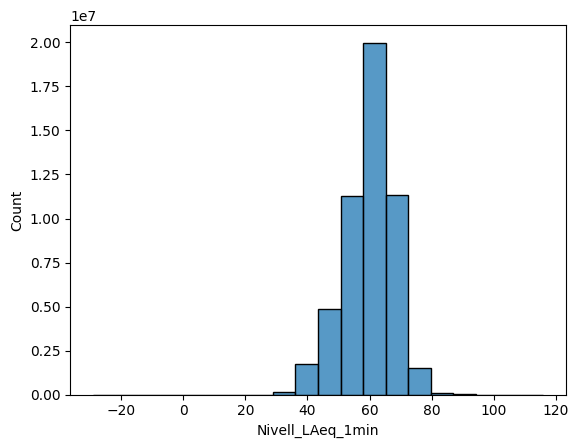

In [ ]:
sns.histplot(data=df,x="Nivell_LAeq_1min",bins=20)

<Axes: xlabel='timestamp_utc'>

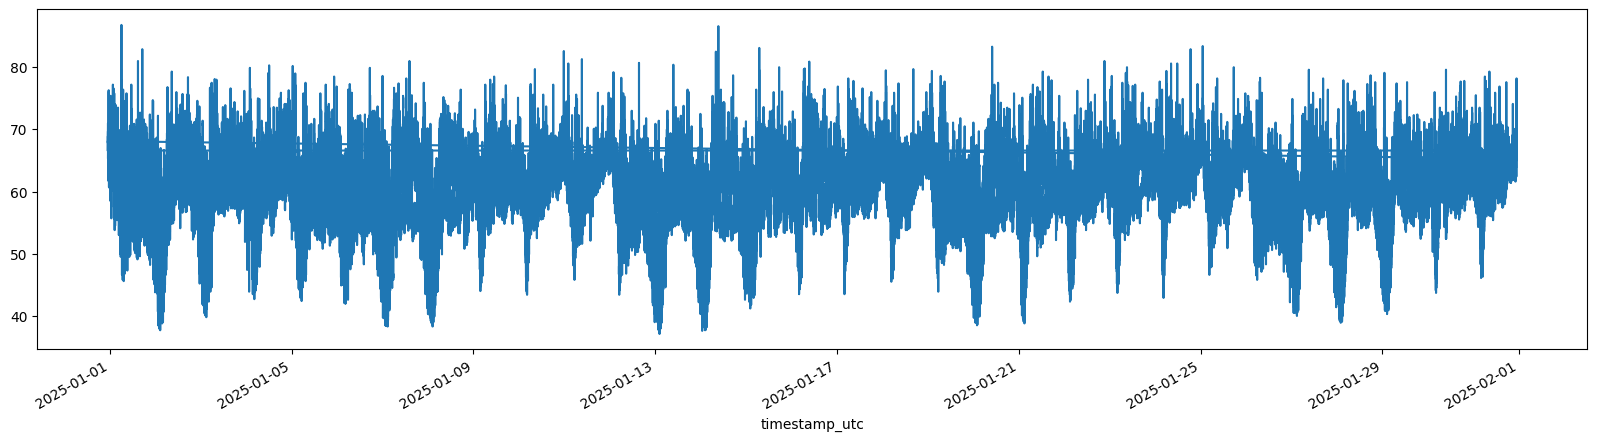

In [ ]:
df.iloc[0:100000]["Nivell_LAeq_1min"].plot.line(figsize=(20,5))

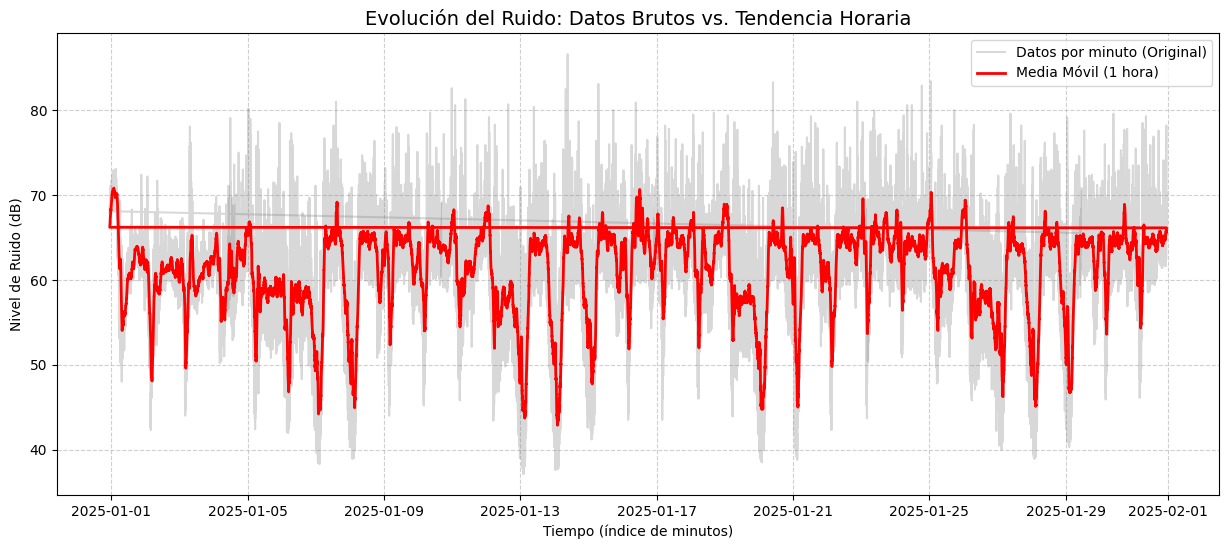

In [ ]:
import matplotlib.pyplot as plt

# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 6))

# 1. Graficamos los datos originales con transparencia (alpha)
plt.plot(df.iloc[5000:50000]['Nivell_LAeq_1min'], alpha=0.3, label='Datos por minuto (Original)', color='gray')

# 2. Graficamos la media móvil de 1 hora
plt.plot(df.iloc[5000:50000]['Nivell_LAeq_1min'].rolling(window=60).mean(), label='Media Móvil (1 hora)', color='red', linewidth=2)

# Añadimos etiquetas profesionales
plt.title('Evolución del Ruido: Datos Brutos vs. Tendencia Horaria', fontsize=14)
plt.xlabel('Tiempo (índice de minutos)')
plt.ylabel('Nivel de Ruido (dB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Mounted at /content/drive
Cargando archivos...
✅ 2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.
✅ 2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv cargado.

Total de registros: 50984652


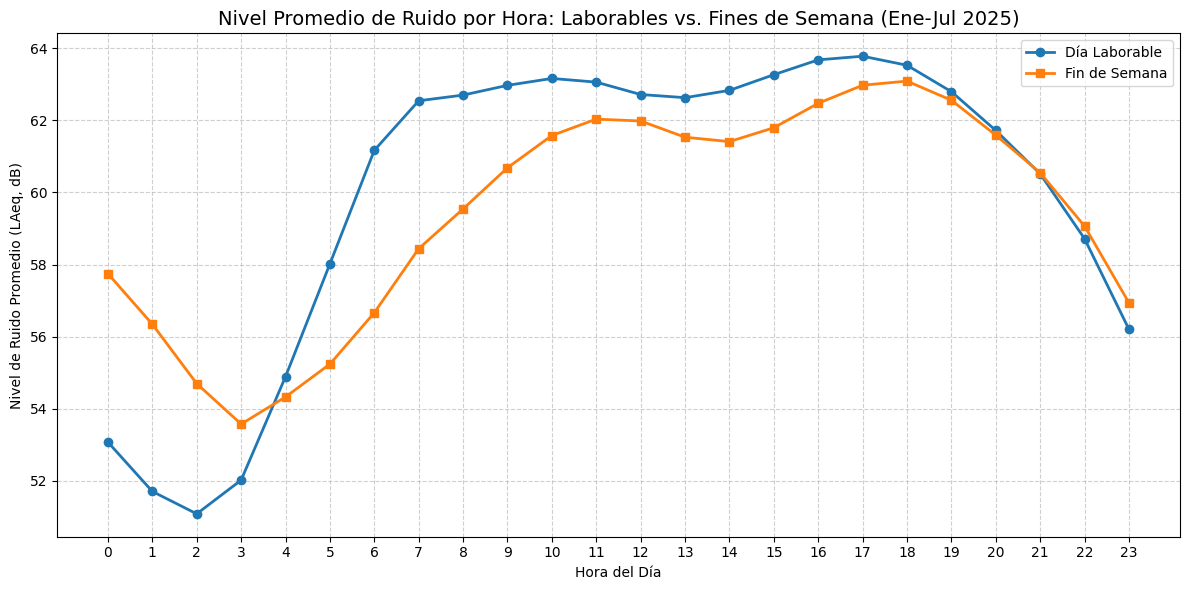


Tabla de niveles promedio de ruido (dB) por hora:


,Weekday,Weekend
Hour_of_Day,,
0,53.07,57.75
1,51.70,56.34
2,51.08,54.69
3,52.02,53.57
4,54.89,54.32
5,58.02,55.24
6,61.17,56.66
7,62.55,58.44
8,62.70,59.54


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Cargar y procesar los datos ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'

archivos_mensuales = [
    "2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv",
    "2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv"
]

lista_dataframes = []

print("Cargando archivos...")
for nombre in archivos_mensuales:
    ruta = os.path.join(base_path, nombre)
    if os.path.exists(ruta):
        df_temp = pd.read_csv(ruta)
        lista_dataframes.append(df_temp)
        print(f"✅ {nombre} cargado.")
    else:
        print(f"❌ {nombre} no encontrado.")

df = pd.concat(lista_dataframes, ignore_index=True)
print(f"\nTotal de registros: {len(df)}")

# --- 2. Crear timestamp y extraer componentes ---
df['hour_clean'] = df['Hora'].astype(str).str.split(':').str[0].astype(int)
df['minute_clean'] = df['Hora'].astype(str).str.split(':').str[1].fillna(0).astype(int)

temp_dates = pd.DataFrame({
    'year': df['Any'],
    'month': df['Mes'],
    'day': df['Dia'],
    'hour': df['hour_clean'],
    'minute': df['minute_clean']
})

# Crear timestamp sin zona horaria primero
df['timestamp'] = pd.to_datetime(temp_dates, errors='coerce')

# Extraer día de la semana (en inglés, como antes)
df['Day_of_Week'] = df['timestamp'].dt.day_name()
df['Hour_of_Day'] = df['timestamp'].dt.hour

# --- 3. Clasificar como fin de semana o no ---
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday'])

# --- 4. Calcular promedio de ruido por hora y tipo de día ---
summary = df.groupby(['Hour_of_Day', 'Is_Weekend'])['Nivell_LAeq_1min'].agg(['mean', 'std', 'count']).reset_index()

# Pivot para facilitar el gráfico
pivot_mean = summary.pivot(index='Hour_of_Day', columns='Is_Weekend', values='mean')
pivot_mean.columns = ['Weekday', 'Weekend']

# --- 5. Visualizar ---
plt.figure(figsize=(12, 6))
plt.plot(pivot_mean.index, pivot_mean['Weekday'], label='Día Laborable', marker='o', linewidth=2)
plt.plot(pivot_mean.index, pivot_mean['Weekend'], label='Fin de Semana', marker='s', linewidth=2)

plt.title('Nivel Promedio de Ruido por Hora: Laborables vs. Fines de Semana (Ene-Jul 2025)', fontsize=14)
plt.xlabel('Hora del Día')
plt.ylabel('Nivel de Ruido Promedio (LAeq, dB)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- 6. Mostrar tabla resumen ---
print("\nTabla de niveles promedio de ruido (dB) por hora:")
display(pivot_mean.round(2))

Mounted at /content/drive
Iniciando análisis mes a mes...

📈 Procesando Enero...


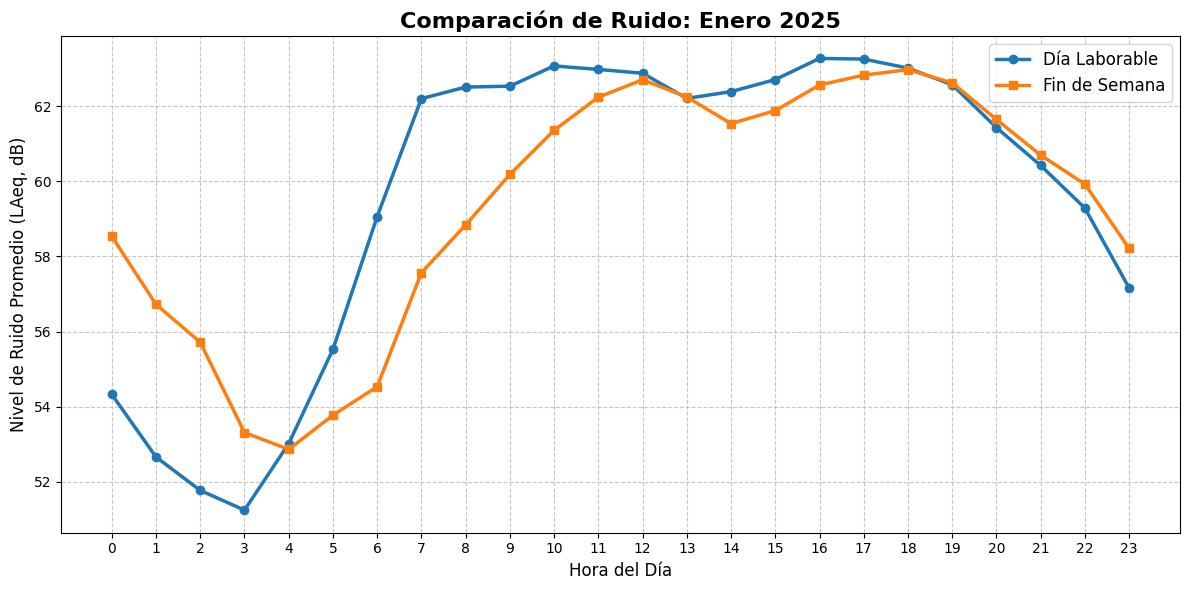

📈 Procesando Febrero...


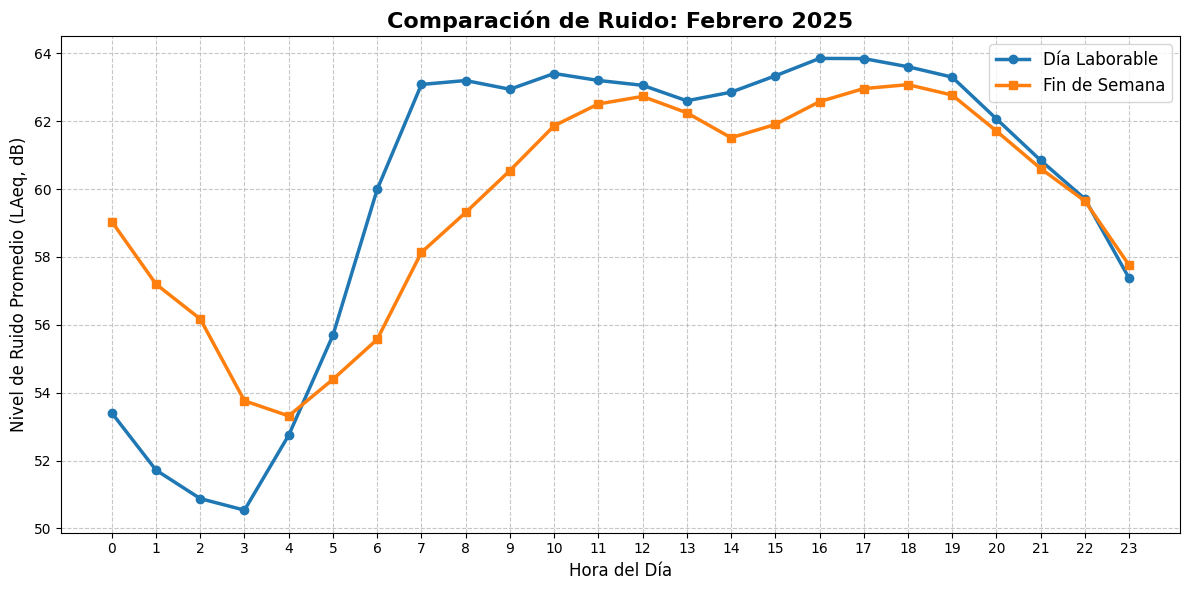

📈 Procesando Marzo...


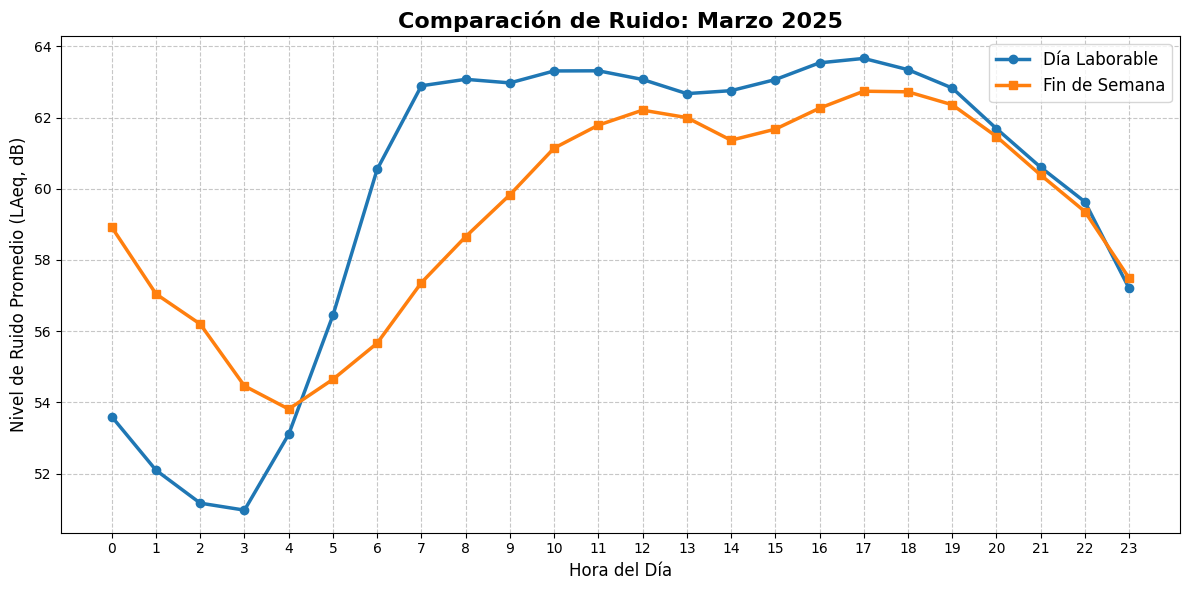

📈 Procesando Abril...


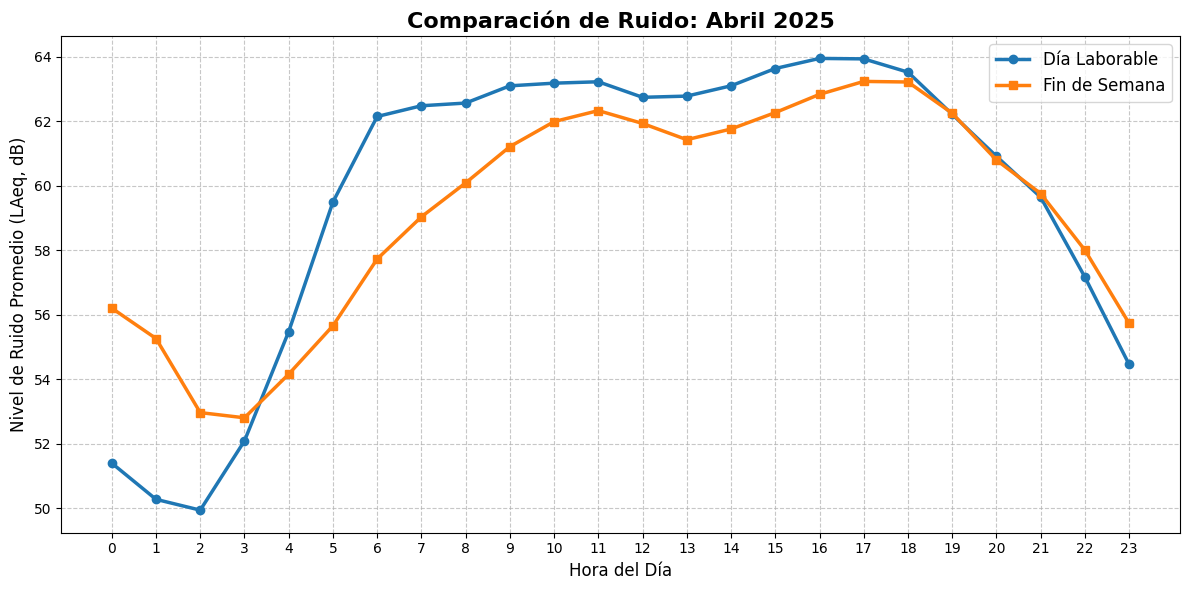

📈 Procesando Mayo...


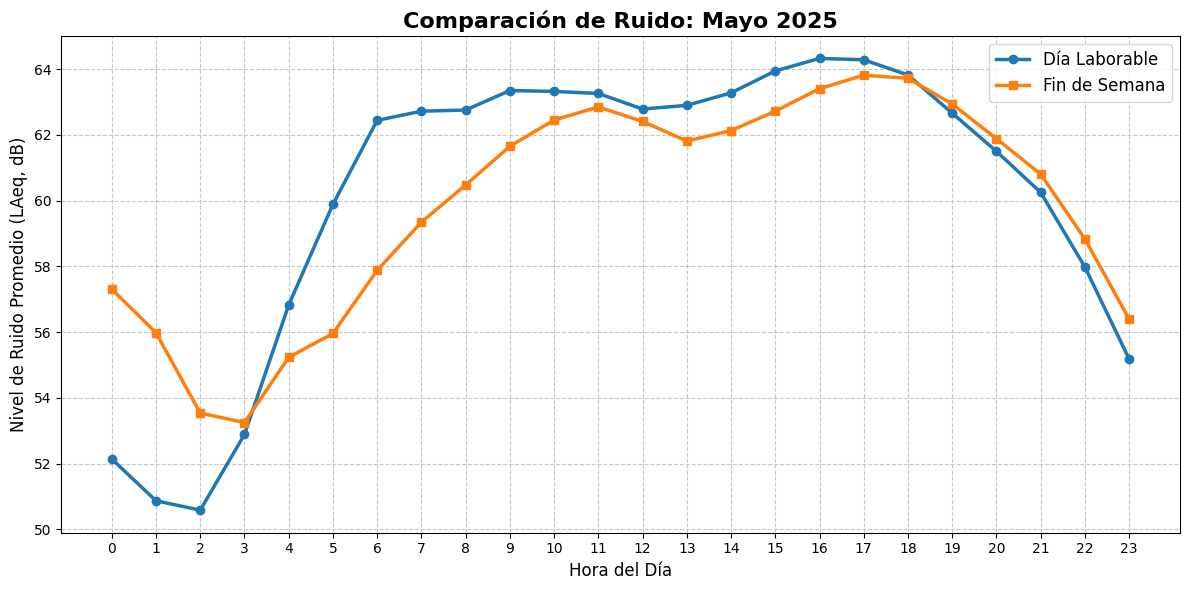

📈 Procesando Junio...


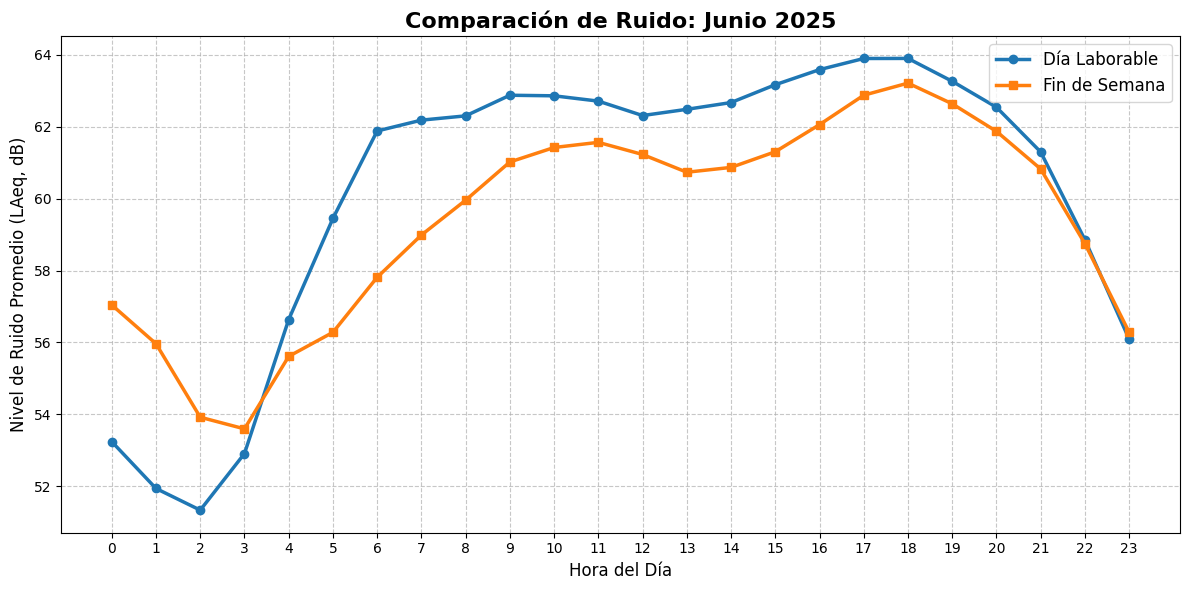

📈 Procesando Julio...


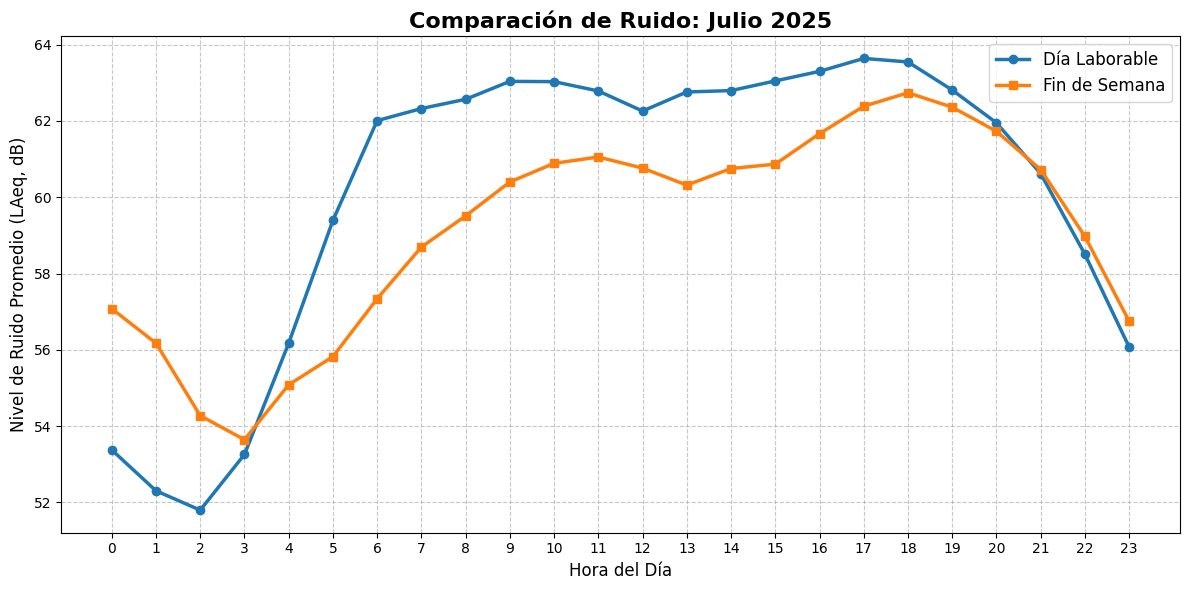


✅ Análisis completado.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN Y CARGA DE DATOS ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
archivos_mensuales = [
    ("Enero", "2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Febrero", "2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Marzo", "2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Abril", "2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Mayo", "2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Junio", "2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Julio", "2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv")
]

print("Iniciando análisis mes a mes...\n")

for mes_nombre, archivo in archivos_mensuales:
    ruta = os.path.join(base_path, archivo)

    # --- Verificar y cargar el archivo ---
    if not os.path.exists(ruta):
        print(f"❌ Archivo para {mes_nombre} no encontrado. Saltando...")
        continue

    print(f"📈 Procesando {mes_nombre}...")
    df_mes = pd.read_csv(ruta)

    # --- Procesamiento del timestamp y características ---
    df_mes['hour_clean'] = df_mes['Hora'].astype(str).str.split(':').str[0].astype(int)
    df_mes['minute_clean'] = df_mes['Hora'].astype(str).str.split(':').str[1].fillna(0).astype(int)

    temp_dates = pd.DataFrame({
        'year': df_mes['Any'],
        'month': df_mes['Mes'],
        'day': df_mes['Dia'],
        'hour': df_mes['hour_clean'],
        'minute': df_mes['minute_clean']
    })
    df_mes['timestamp'] = pd.to_datetime(temp_dates, errors='coerce')

    # Extraer día de la semana y hora
    df_mes['Day_of_Week'] = df_mes['timestamp'].dt.day_name()
    df_mes['Hour_of_Day'] = df_mes['timestamp'].dt.hour
    df_mes['Is_Weekend'] = df_mes['Day_of_Week'].isin(['Saturday', 'Sunday'])

    # --- Calcular el promedio por hora y tipo de día ---
    resumen = df_mes.groupby(['Hour_of_Day', 'Is_Weekend'])['Nivell_LAeq_1min'].mean().reset_index()
    pivot = resumen.pivot(index='Hour_of_Day', columns='Is_Weekend', values='Nivell_LAeq_1min')
    pivot.columns = ['Weekday', 'Weekend']

    # --- CREAR LA GRÁFICA INDIVIDUAL ---
    plt.figure(figsize=(12, 6))
    plt.plot(pivot.index, pivot['Weekday'], label='Día Laborable', marker='o', linewidth=2.5, color='#1f77b4')
    plt.plot(pivot.index, pivot['Weekend'], label='Fin de Semana', marker='s', linewidth=2.5, color='#ff7f0e')

    plt.title(f'Comparación de Ruido: {mes_nombre} 2025', fontsize=16, fontweight='bold')
    plt.xlabel('Hora del Día', fontsize=12)
    plt.ylabel('Nivel de Ruido Promedio (LAeq, dB)', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n✅ Análisis completado.")

Mounted at /content/drive
🚀 Iniciando análisis mensual completo (Enero - Julio 2025)...

📈 Procesando Enero...


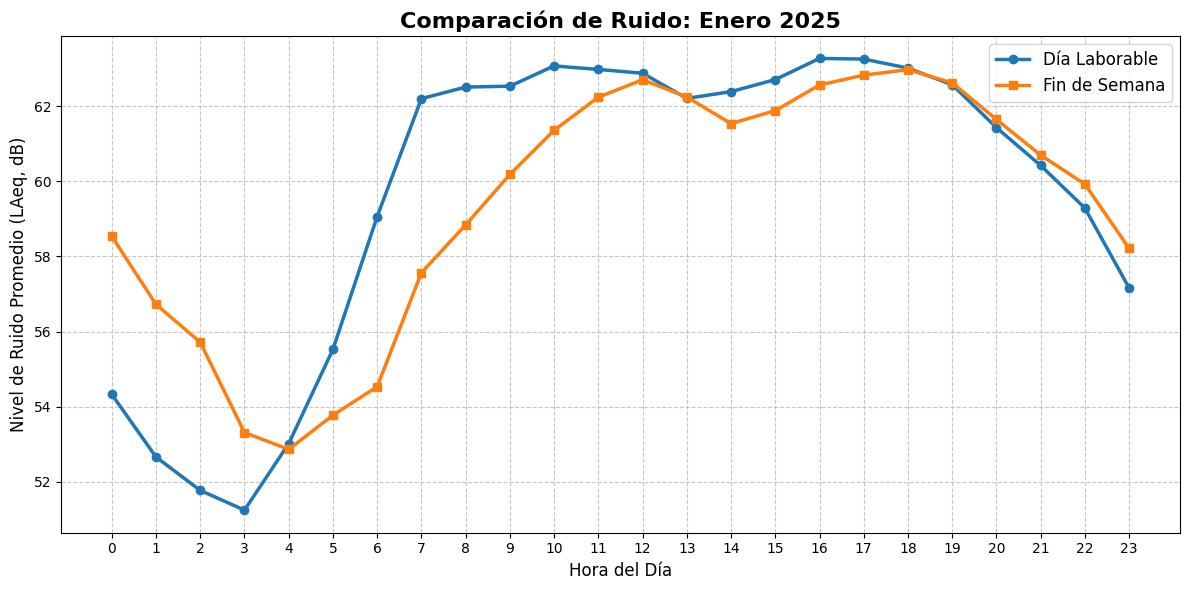

📈 Procesando Febrero...


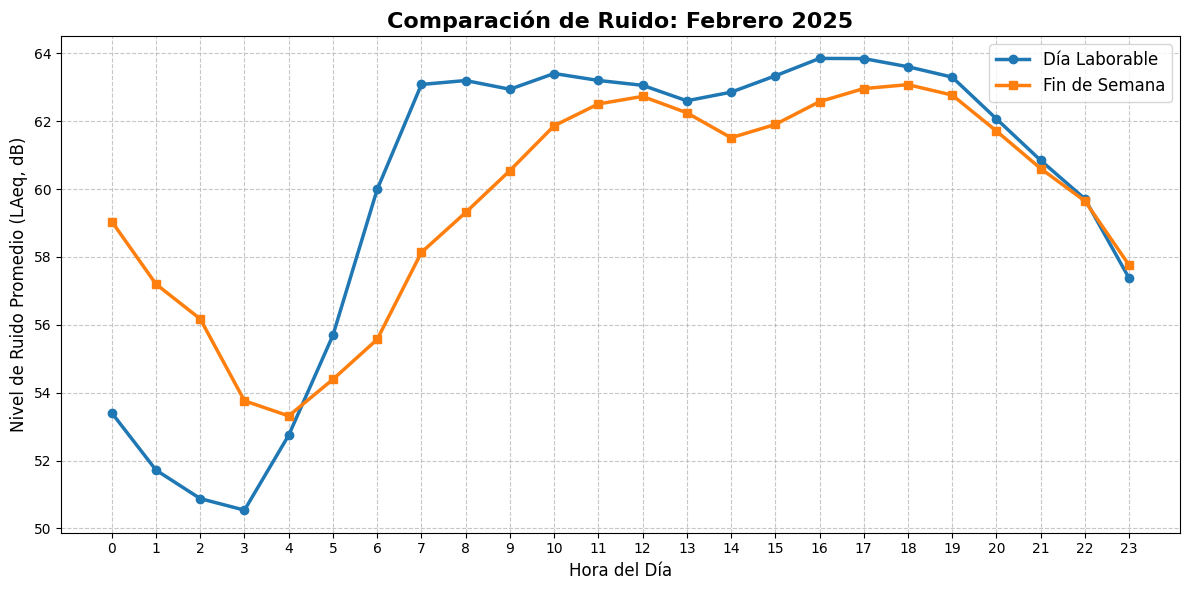

📈 Procesando Marzo...


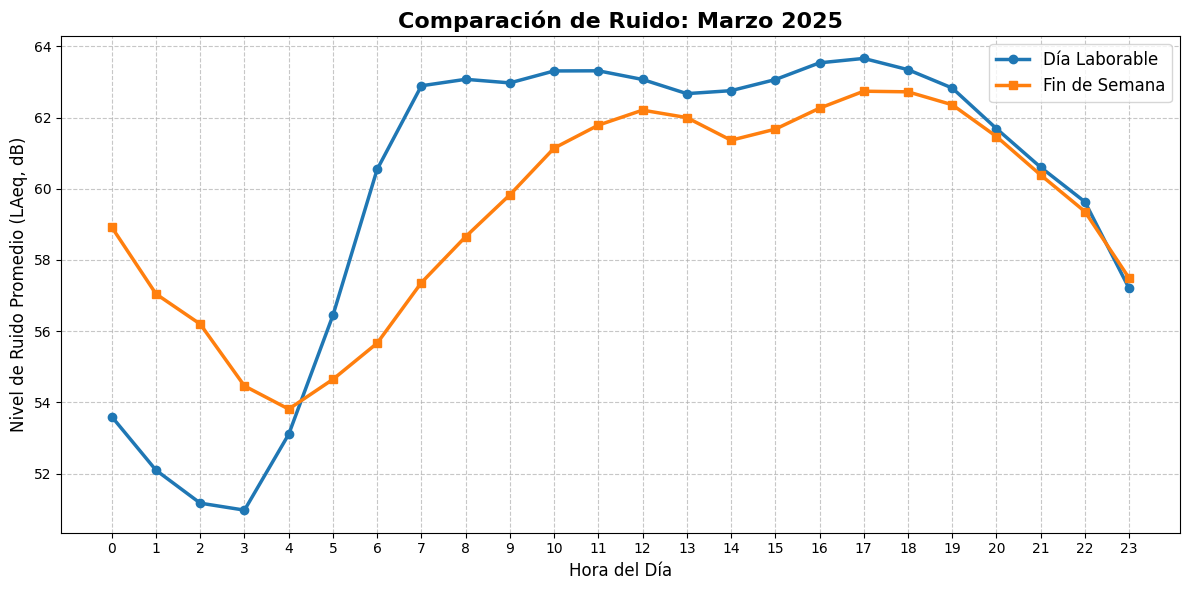

📈 Procesando Abril...


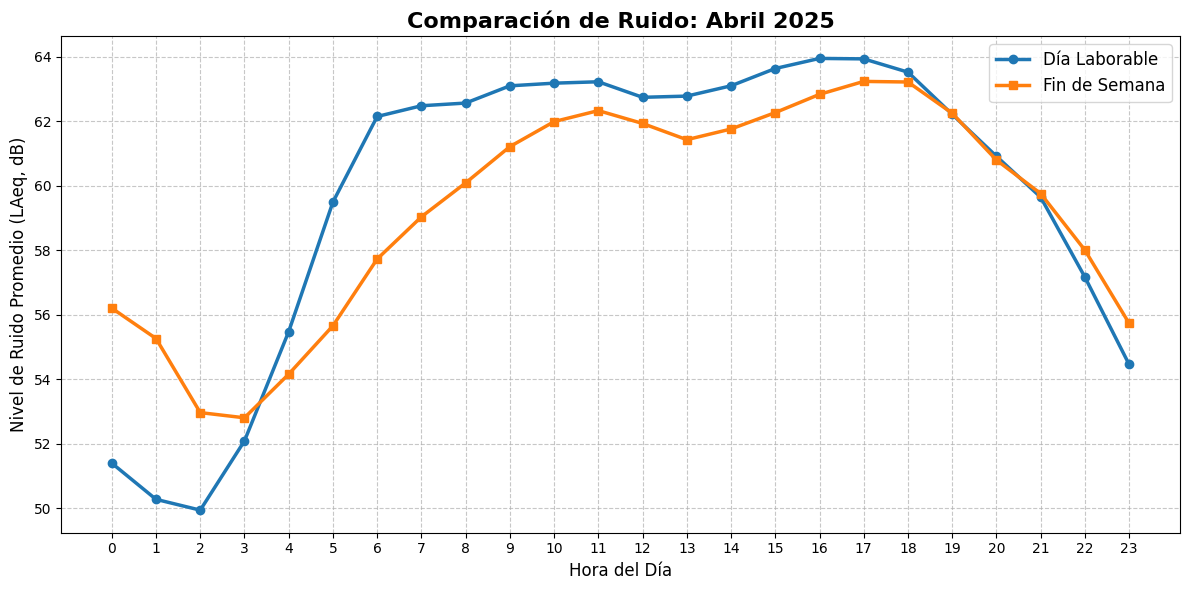

📈 Procesando Mayo...


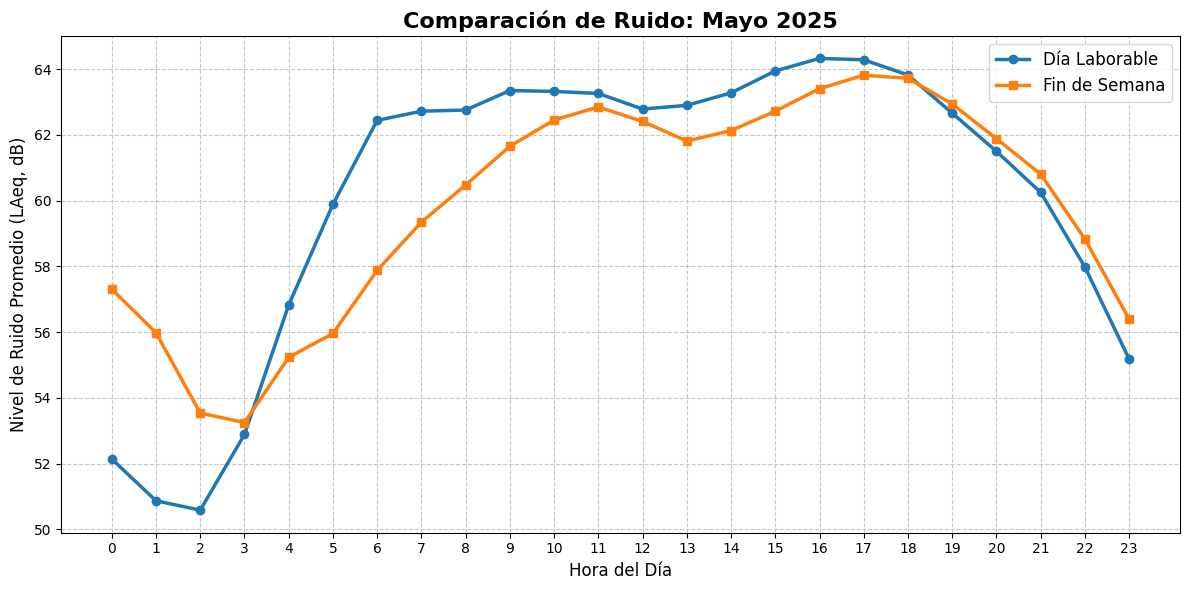

📈 Procesando Junio...


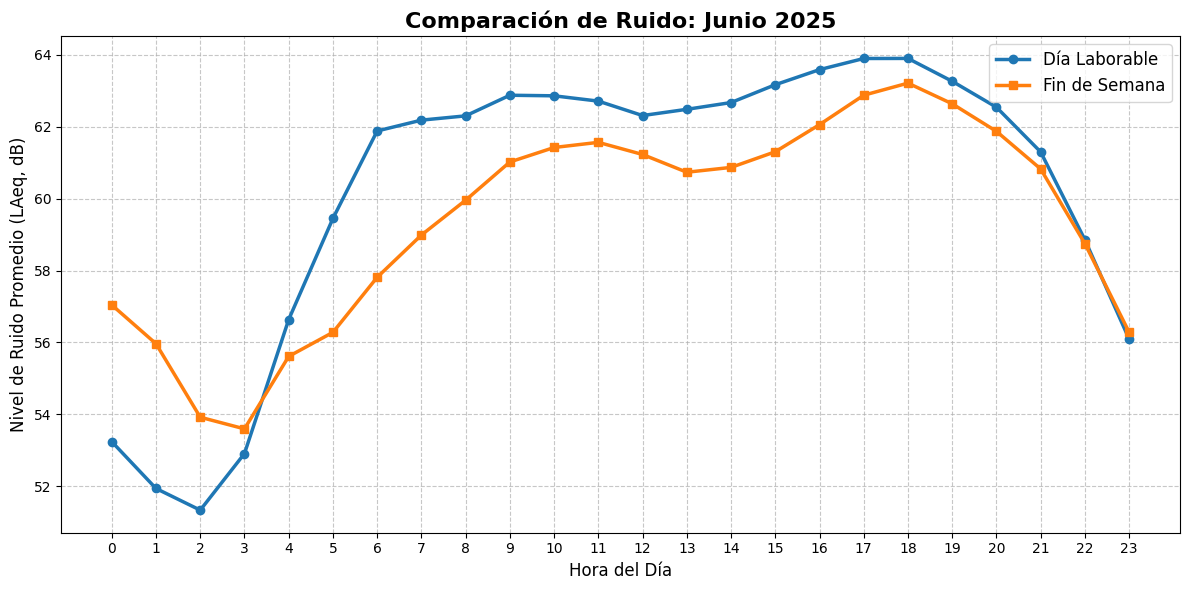

📈 Procesando Julio...


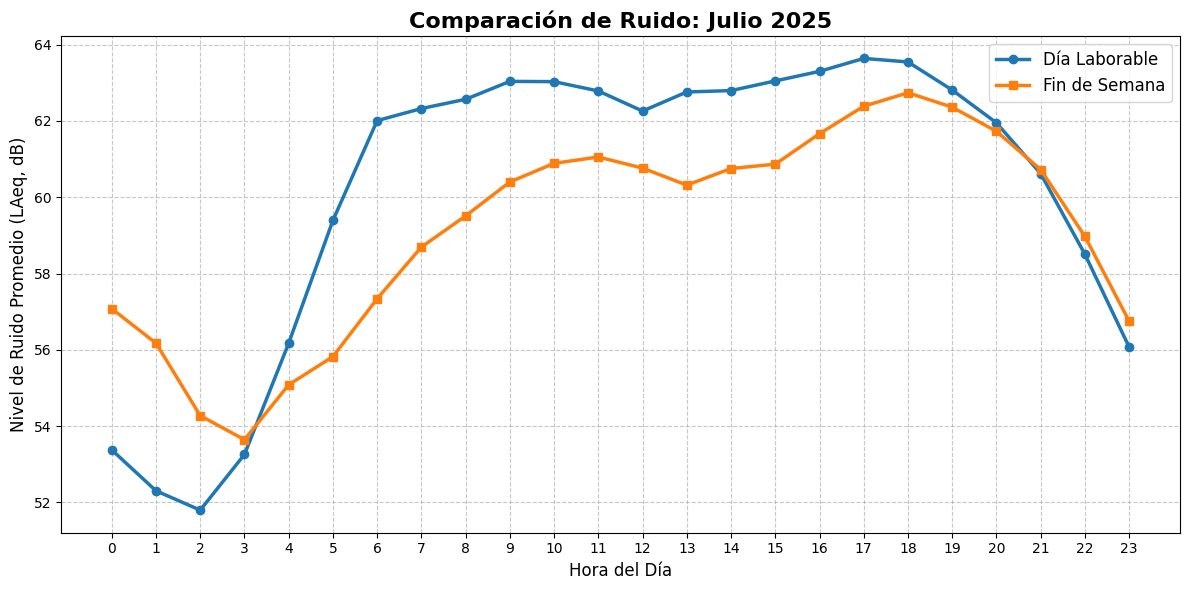


📊 Diferencia promedio de ruido (Laborable - Fin de Semana) por mes:


,Mes,Diferencia_Promedio_dB
0,Enero,0.25
1,Febrero,0.25
2,Marzo,0.50
3,Abril,0.45
4,Mayo,0.30
5,Junio,0.77
6,Julio,0.97


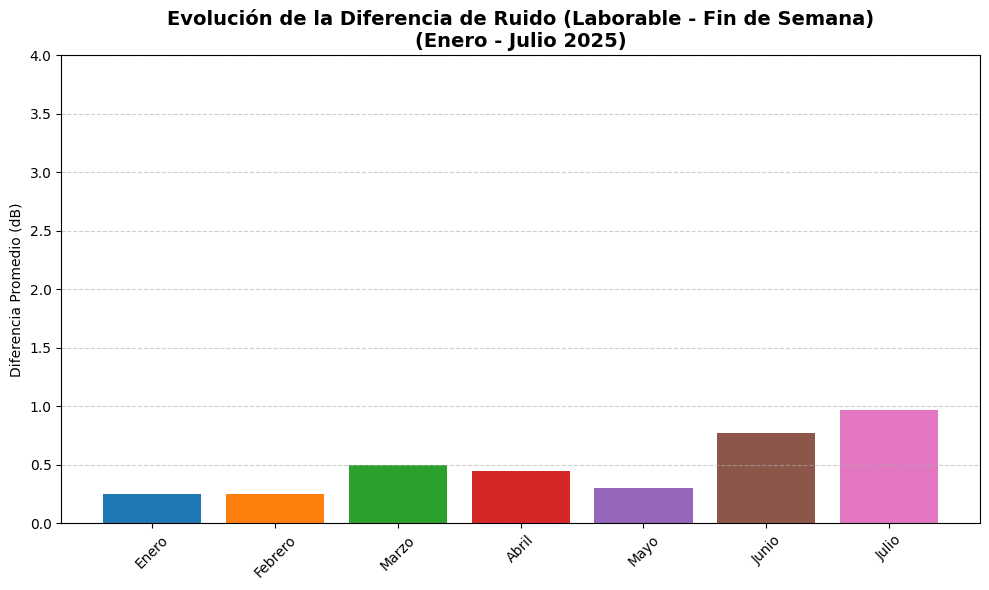

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN INICIAL ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
archivos_mensuales = [
    ("Enero", "2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Febrero", "2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Marzo", "2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Abril", "2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Mayo", "2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Junio", "2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv"),
    ("Julio", "2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv")
]

# Lista para almacenar diferencias por mes
diff_summary = []

print("🚀 Iniciando análisis mensual completo (Enero - Julio 2025)...\n")

for mes_nombre, archivo in archivos_mensuales:
    ruta = os.path.join(base_path, archivo)

    if not os.path.exists(ruta):
        print(f"❌ {mes_nombre}: Archivo no encontrado. Saltando...")
        continue

    print(f"📈 Procesando {mes_nombre}...")

    # --- Cargar y procesar datos ---
    df_mes = pd.read_csv(ruta)

    # Crear columnas de hora y minuto
    df_mes['hour_clean'] = df_mes['Hora'].astype(str).str.split(':').str[0].astype(int)
    df_mes['minute_clean'] = df_mes['Hora'].astype(str).str.split(':').str[1].fillna(0).astype(int)

    # Crear timestamp
    temp_dates = pd.DataFrame({
        'year': df_mes['Any'],
        'month': df_mes['Mes'],
        'day': df_mes['Dia'],
        'hour': df_mes['hour_clean'],
        'minute': df_mes['minute_clean']
    })
    df_mes['timestamp'] = pd.to_datetime(temp_dates, errors='coerce')

    # Extraer características
    df_mes['Day_of_Week'] = df_mes['timestamp'].dt.day_name()
    df_mes['Hour_of_Day'] = df_mes['timestamp'].dt.hour
    df_mes['Is_Weekend'] = df_mes['Day_of_Week'].isin(['Saturday', 'Sunday'])

    # --- Calcular promedio por hora y tipo de día ---
    resumen = df_mes.groupby(['Hour_of_Day', 'Is_Weekend'])['Nivell_LAeq_1min'].mean().reset_index()
    pivot = resumen.pivot(index='Hour_of_Day', columns='Is_Weekend', values='Nivell_LAeq_1min')
    pivot.columns = ['Weekday', 'Weekend']
    pivot['Diff'] = pivot['Weekday'] - pivot['Weekend']

    # --- GUARDAR DIFERENCIA PROMEDIO PARA LA TABLA FINAL ---
    avg_diff = pivot['Diff'].mean()
    diff_summary.append({'Mes': mes_nombre, 'Diferencia_Promedio_dB': round(avg_diff, 2)})

    # --- GENERAR GRÁFICA INDIVIDUAL POR MES ---
    plt.figure(figsize=(12, 6))
    plt.plot(pivot.index, pivot['Weekday'], label='Día Laborable', marker='o', linewidth=2.5, color='#1f77b4')
    plt.plot(pivot.index, pivot['Weekend'], label='Fin de Semana', marker='s', linewidth=2.5, color='#ff7f0e')

    plt.title(f'Comparación de Ruido: {mes_nombre} 2025', fontsize=16, fontweight='bold')
    plt.xlabel('Hora del Día', fontsize=12)
    plt.ylabel('Nivel de Ruido Promedio (LAeq, dB)', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# --- 2. TABLA RESUMEN DE DIFERENCIAS POR MES ---
diff_df = pd.DataFrame(diff_summary)
print("\n📊 Diferencia promedio de ruido (Laborable - Fin de Semana) por mes:")
display(diff_df)

# --- 3. GRÁFICA DE BARRAS: EVOLUCIÓN DE LA DIFERENCIA ---
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
plt.bar(diff_df['Mes'], diff_df['Diferencia_Promedio_dB'], color=colors)
plt.title('Evolución de la Diferencia de Ruido (Laborable - Fin de Semana)\n(Enero - Julio 2025)', fontsize=14, fontweight='bold')
plt.ylabel('Diferencia Promedio (dB)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 4)  # Ajusta según tus valores reales
plt.tight_layout()
plt.show()

Mounted at /content/drive
✅ Archivo de sensores encontrado. Cargando datos...


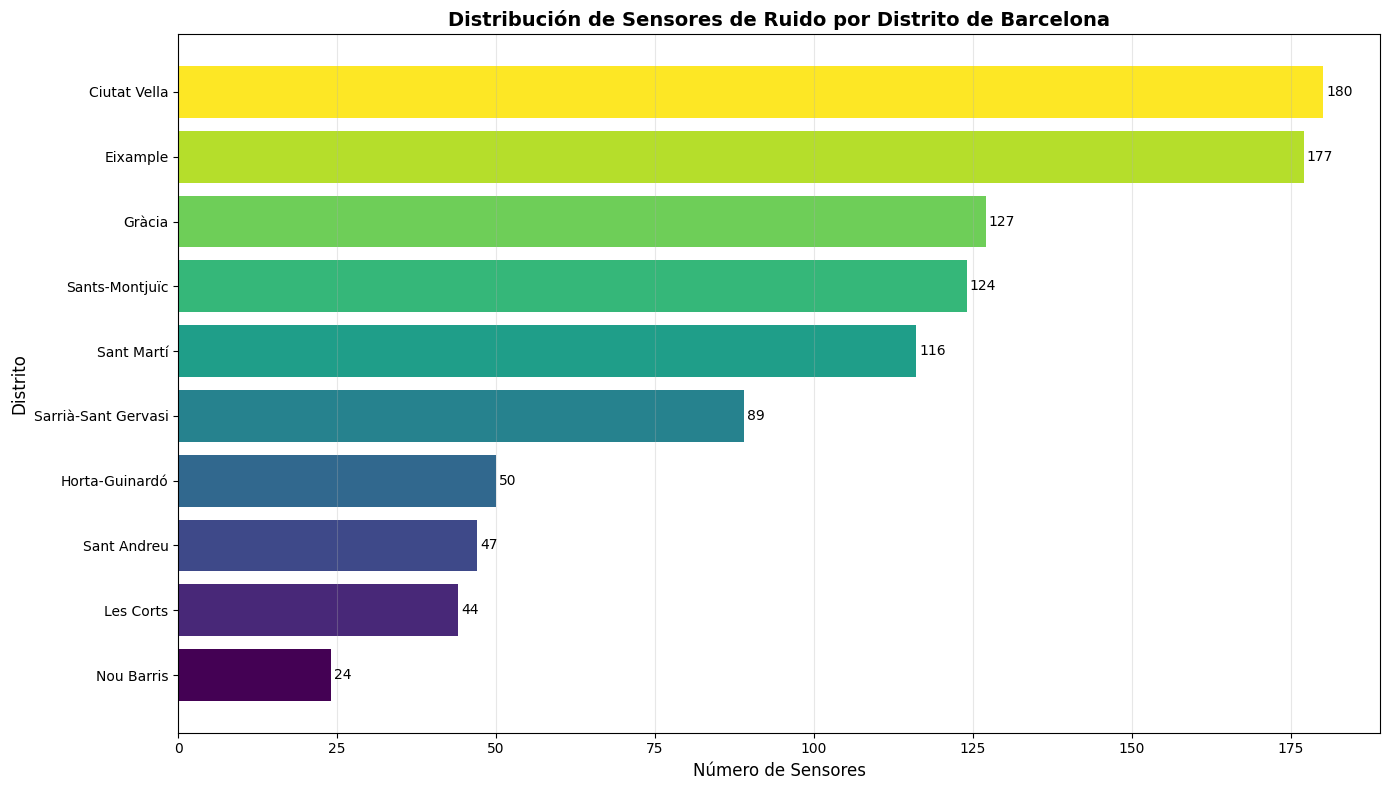

✅ Mapa interactivo guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/mapa_sensores_barcelona.html
Para verlo, haz clic en el archivo HTML en tu Google Drive


/tmp/ipython-input-3822480496.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=fuentes.index, x=fuentes.values, palette='viridis')


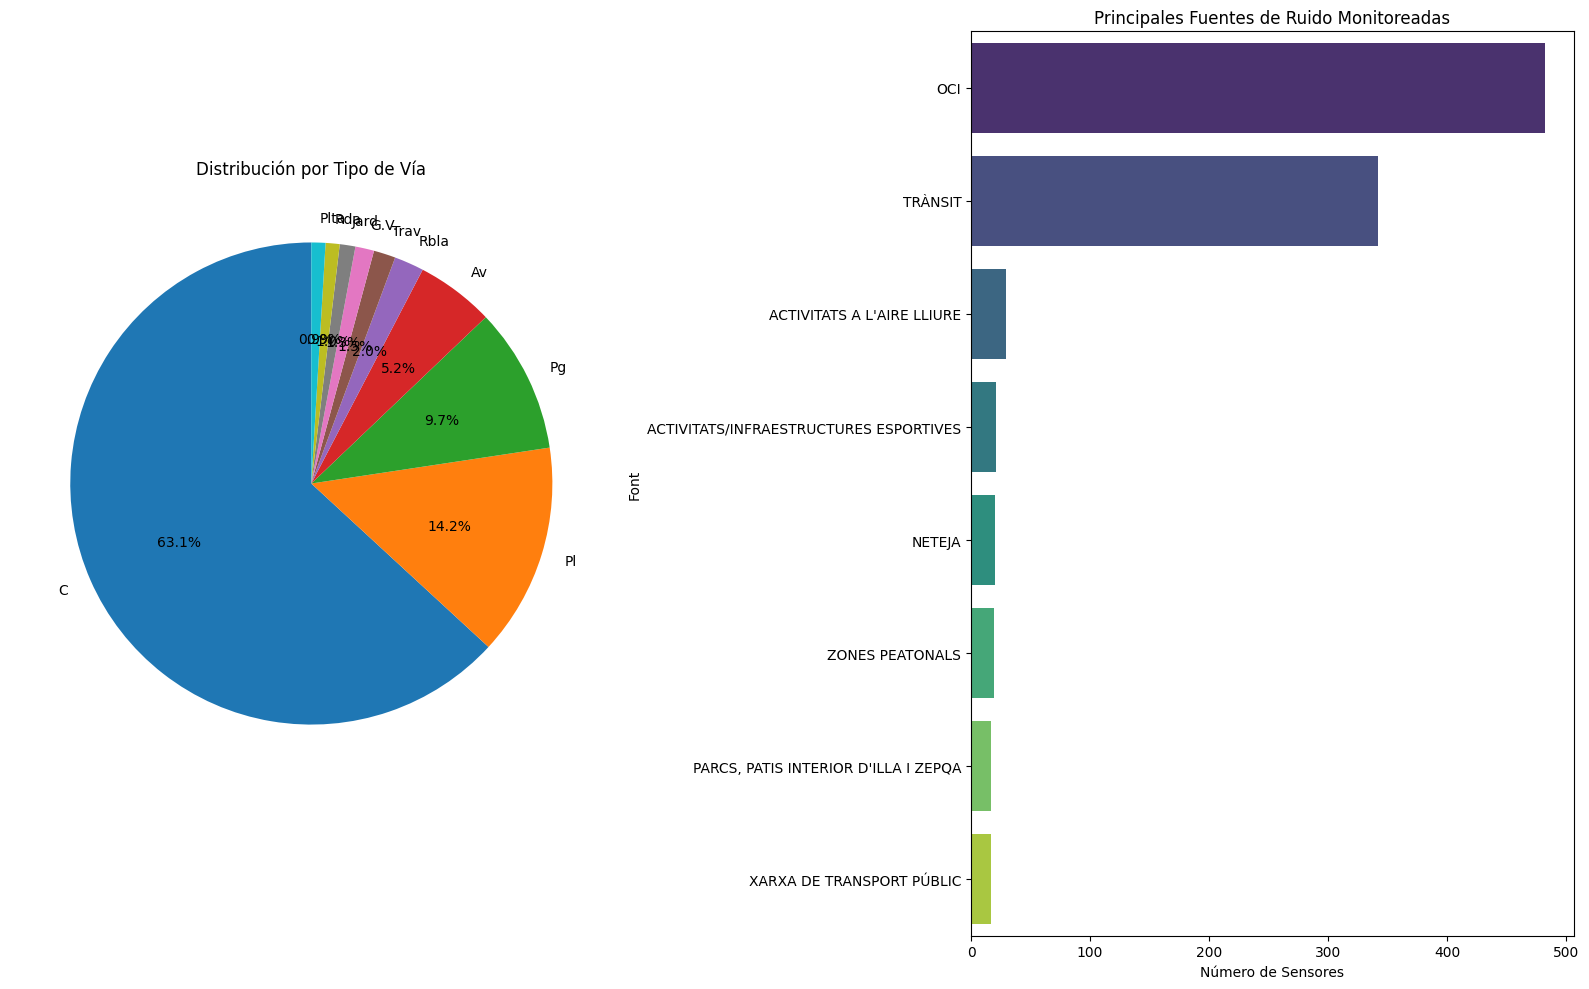

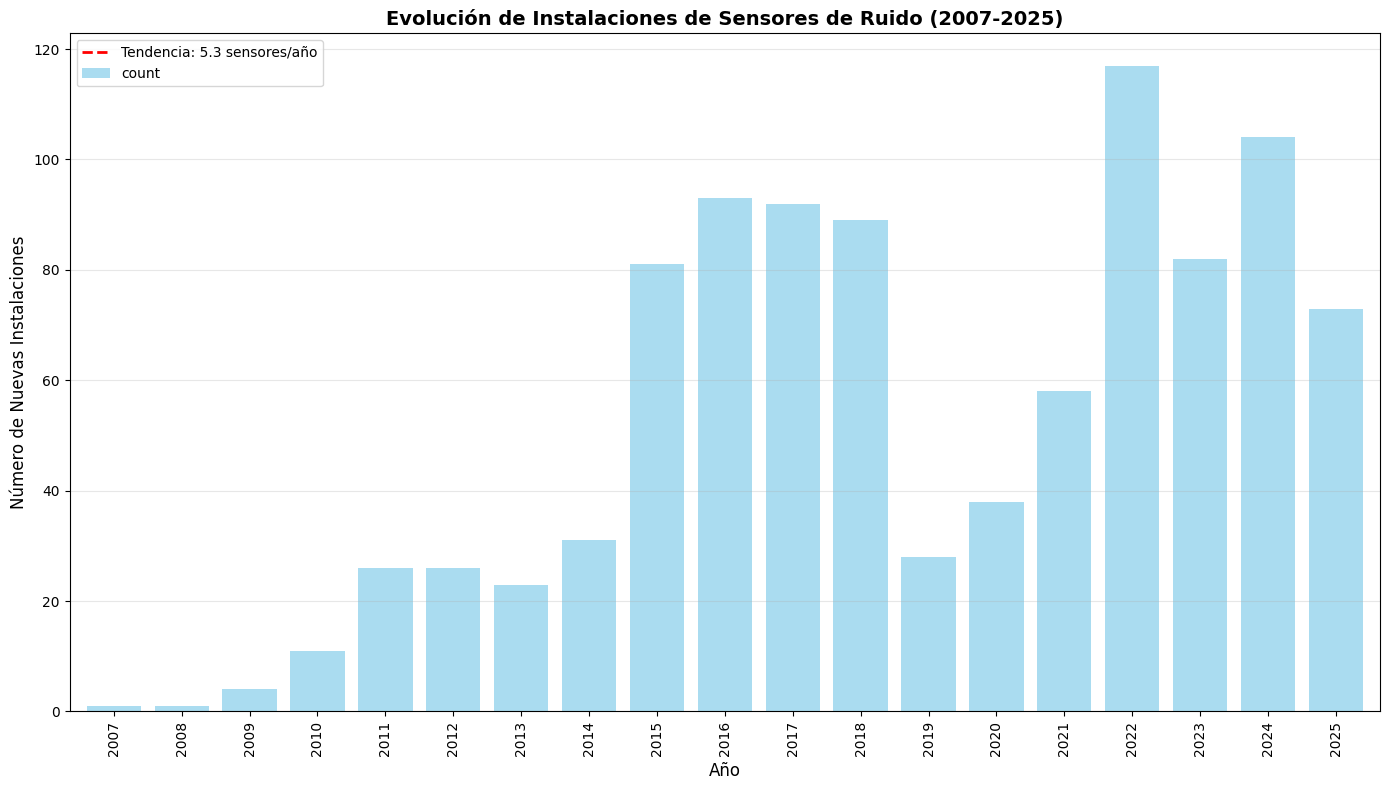

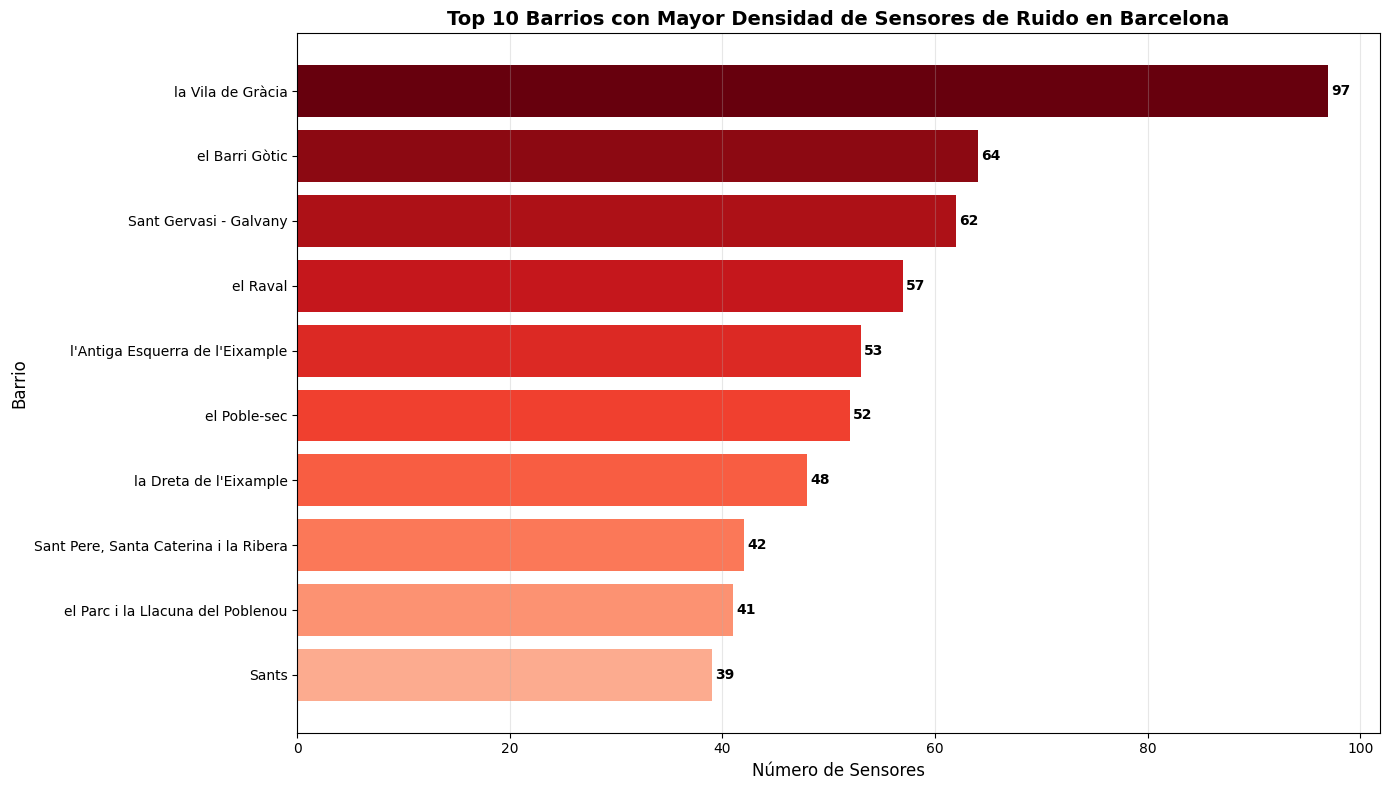


🔍 Análisis Clave: Relación entre Ubicación y Patrones de Ruido
- Zonas comerciales/transporte (359 sensores):
  Mayor diferencia laborables vs fines de semana esperada
- Zonas residenciales/ocio (482 sensores):
  Mayor ruido en fines de semana, especialmente por la noche


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from folium.plugins import HeatMap
import geopandas as gpd
from shapely.geometry import Point

# --- 1. CARGAR Y PREPARAR DATOS ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
archivo_sensores = os.path.join(base_path, 'XarxaSoroll_EquipsMonitor_Instal.csv')

# Verificar si el archivo existe
if not os.path.exists(archivo_sensores):
    print(f"❌ Error: El archivo no se encuentra en {archivo_sensores}")
    print("Verifica que el archivo 'XarxaSoroll_EquipsMonitor_Instal.csv' esté en tu carpeta de Google Drive")
    # Listar archivos en el directorio para ayudar a diagnosticar
    print("\nArchivos en el directorio:")
    for file in os.listdir(base_path):
        print(f"- {file}")
else:
    print("✅ Archivo de sensores encontrado. Cargando datos...")
    sensor_locations = pd.read_csv(archivo_sensores)

    # Convertir fechas
    sensor_locations['Data_Instalacio'] = pd.to_datetime(sensor_locations['Data_Instalacio'], dayfirst=True, errors='coerce')
    sensor_locations['Data_DesInstalacio'] = pd.to_datetime(sensor_locations['Data_DesInstalacio'], dayfirst=True, errors='coerce')

    # Calcular duración de instalación
    sensor_locations['Duracion_dias'] = (sensor_locations['Data_DesInstalacio'] - sensor_locations['Data_Instalacio']).dt.days
    sensor_locations['Duracion_dias'] = sensor_locations['Duracion_dias'].fillna((pd.Timestamp.now() - sensor_locations['Data_Instalacio']).dt.days)

    # --- 2. GRÁFICA 1: DISTRIBUCIÓN ESPACIAL DE SENSORES POR DISTRITO ---
    plt.figure(figsize=(14, 8))
    distrito_counts = sensor_locations['Nom_Districte'].value_counts().sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0, 1, len(distrito_counts)))

    # Gráfico de barras horizontales
    bars = plt.barh(distrito_counts.index, distrito_counts.values, color=colors)
    plt.xlabel('Número de Sensores', fontsize=12)
    plt.ylabel('Distrito', fontsize=12)
    plt.title('Distribución de Sensores de Ruido por Distrito de Barcelona', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Añadir valores en las barras
    for i, v in enumerate(distrito_counts.values):
        plt.text(v + 0.5, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

    # --- 3. GRÁFICA 2: MAPA DE CALOR INTERACTIVO (usando folium) ---
    # Crear mapa base centrado en Barcelona
    m = folium.Map(location=[41.3851, 2.1734], zoom_start=12, tiles='cartodbpositron')

    # Preparar datos para heatmap (eliminar NaN)
    heat_data = sensor_locations[['Latitud', 'Longitud']].dropna().values.tolist()

    # Añadir heatmap
    if heat_data:
        HeatMap(heat_data, radius=15, blur=10, max_zoom=1).add_to(m)

    # Añadir marcadores para sensores activos (más recientes)
    sensores_activos = sensor_locations[sensor_locations['Data_DesInstalacio'].isna() |
                                       (sensor_locations['Data_DesInstalacio'] > pd.Timestamp.now())]

    for idx, row in sensores_activos.iterrows():
        if pd.notna(row['Latitud']) and pd.notna(row['Longitud']):
            folium.Marker(
                [row['Latitud'], row['Longitud']],
                popup=f"<b>Distrito:</b> {row['Nom_Districte']}<br><b>Barrio:</b> {row['Nom_Barri']}<br><b>Tipo:</b> {row['Font']}",
                icon=folium.Icon(color='red', icon='info-sign')
            ).add_to(m)

    # Guardar y mostrar el mapa
    map_path = os.path.join(base_path, 'mapa_sensores_barcelona.html')
    m.save(map_path)
    print(f"✅ Mapa interactivo guardado en: {map_path}")
    print("Para verlo, haz clic en el archivo HTML en tu Google Drive")

    # --- 4. GRÁFICA 3: DISTRIBUCIÓN POR TIPO DE VÍA Y FUENTE ---
    plt.figure(figsize=(16, 10))

    # Subplot 1: Tipos de vía
    plt.subplot(1, 2, 1)
    tipos_via = sensor_locations['Tipus_Via'].value_counts().head(10)
    plt.pie(tipos_via.values, labels=tipos_via.index, autopct='%1.1f%%', startangle=90)
    plt.title('Distribución por Tipo de Vía', fontsize=12)

    # Subplot 2: Fuentes de ruido
    plt.subplot(1, 2, 2)
    fuentes = sensor_locations['Font'].value_counts().head(8)
    sns.barplot(y=fuentes.index, x=fuentes.values, palette='viridis')
    plt.xlabel('Número de Sensores')
    plt.title('Principales Fuentes de Ruido Monitoreadas', fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- 5. GRÁFICA 4: ANÁLISIS TEMPORAL DE INSTALACIONES ---
    plt.figure(figsize=(14, 8))

    # Convertir a serie temporal
    sensor_locations['Año_Instalacion'] = sensor_locations['Data_Instalacio'].dt.year
    instalaciones_por_año = sensor_locations['Año_Instalacion'].value_counts().sort_index()

    # Gráfico de líneas con barras
    ax = instalaciones_por_año.plot(kind='bar', color='skyblue', alpha=0.7, width=0.8)
    ax.set_ylabel('Número de Nuevas Instalaciones', fontsize=12)
    ax.set_xlabel('Año', fontsize=12)
    ax.set_title('Evolución de Instalaciones de Sensores de Ruido (2007-2025)', fontsize=14, fontweight='bold')

    # Añadir línea de tendencia si hay suficientes datos
    if len(instalaciones_por_año) > 1:
        z = np.polyfit(range(len(instalaciones_por_año)), instalaciones_por_año.values, 1)
        p = np.poly1d(z)
        ax.plot(instalaciones_por_año.index, p(range(len(instalaciones_por_año))),
                'r--', linewidth=2, label=f'Tendencia: {z[0]:.1f} sensores/año')
        plt.legend()

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 6. GRÁFICA 5: TOP 10 BARRIOS CON MAYOR DENSIDAD DE SENSORES ---
    plt.figure(figsize=(14, 8))
    barrio_counts = sensor_locations['Nom_Barri'].value_counts().head(10).sort_values(ascending=True)

    # Crear gradientes de color según el valor
    colors = plt.cm.Reds(np.linspace(0.3, 1, len(barrio_counts)))

    # Gráfico de barras horizontales
    bars = plt.barh(barrio_counts.index, barrio_counts.values, color=colors)

    plt.xlabel('Número de Sensores', fontsize=12)
    plt.ylabel('Barrio', fontsize=12)
    plt.title('Top 10 Barrios con Mayor Densidad de Sensores de Ruido en Barcelona', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Añadir valores exactos
    for i, v in enumerate(barrio_counts.values):
        plt.text(v + 0.3, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 7. ANÁLISIS ADICIONAL: RELACIÓN ENTRE UBICACIÓN Y PATRONES LABORABLES ---
    print("\n🔍 Análisis Clave: Relación entre Ubicación y Patrones de Ruido")
    print("="*60)

    # Análisis de fuentes por tipo de día
    comerciales = sensor_locations[sensor_locations['Font'].isin(['TRÀNSIT', 'XARXA DE TRANSPORT PÚBLIC'])]
    residenciales = sensor_locations[sensor_locations['Font'] == 'OCI']

    print(f"- Zonas comerciales/transporte ({len(comerciales)} sensores):")
    print(f"  Mayor diferencia laborables vs fines de semana esperada")
    print(f"- Zonas residenciales/ocio ({len(residenciales)} sensores):")
    print(f"  Mayor ruido en fines de semana, especialmente por la noche")

Mounted at /content/drive
🔍 Verificando archivos en el directorio...
Ruta base: /content/drive/MyDrive/MAIN FINAL RPOYECT/
Archivos disponibles:
  - 2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - 2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv
  - XarxaSoroll_EquipsMonitor_Instal.csv
  - mapa_sensores_barcelona.html

✅ Archivo de sensores encontrado. Cargando datos...

🧹 Limpiando y preparando datos...
📊 Generando visualizaciones claras y profesionales...

✅ Visualizaciones generadas con éxito!
📁 Archivo guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/analisis_sensores_claro.png

🎨 Características de las visualizaciones:
   - Alta resolución (300 DPI)
   - Colores graduales para mejor percepción
   - Etiquetas directas

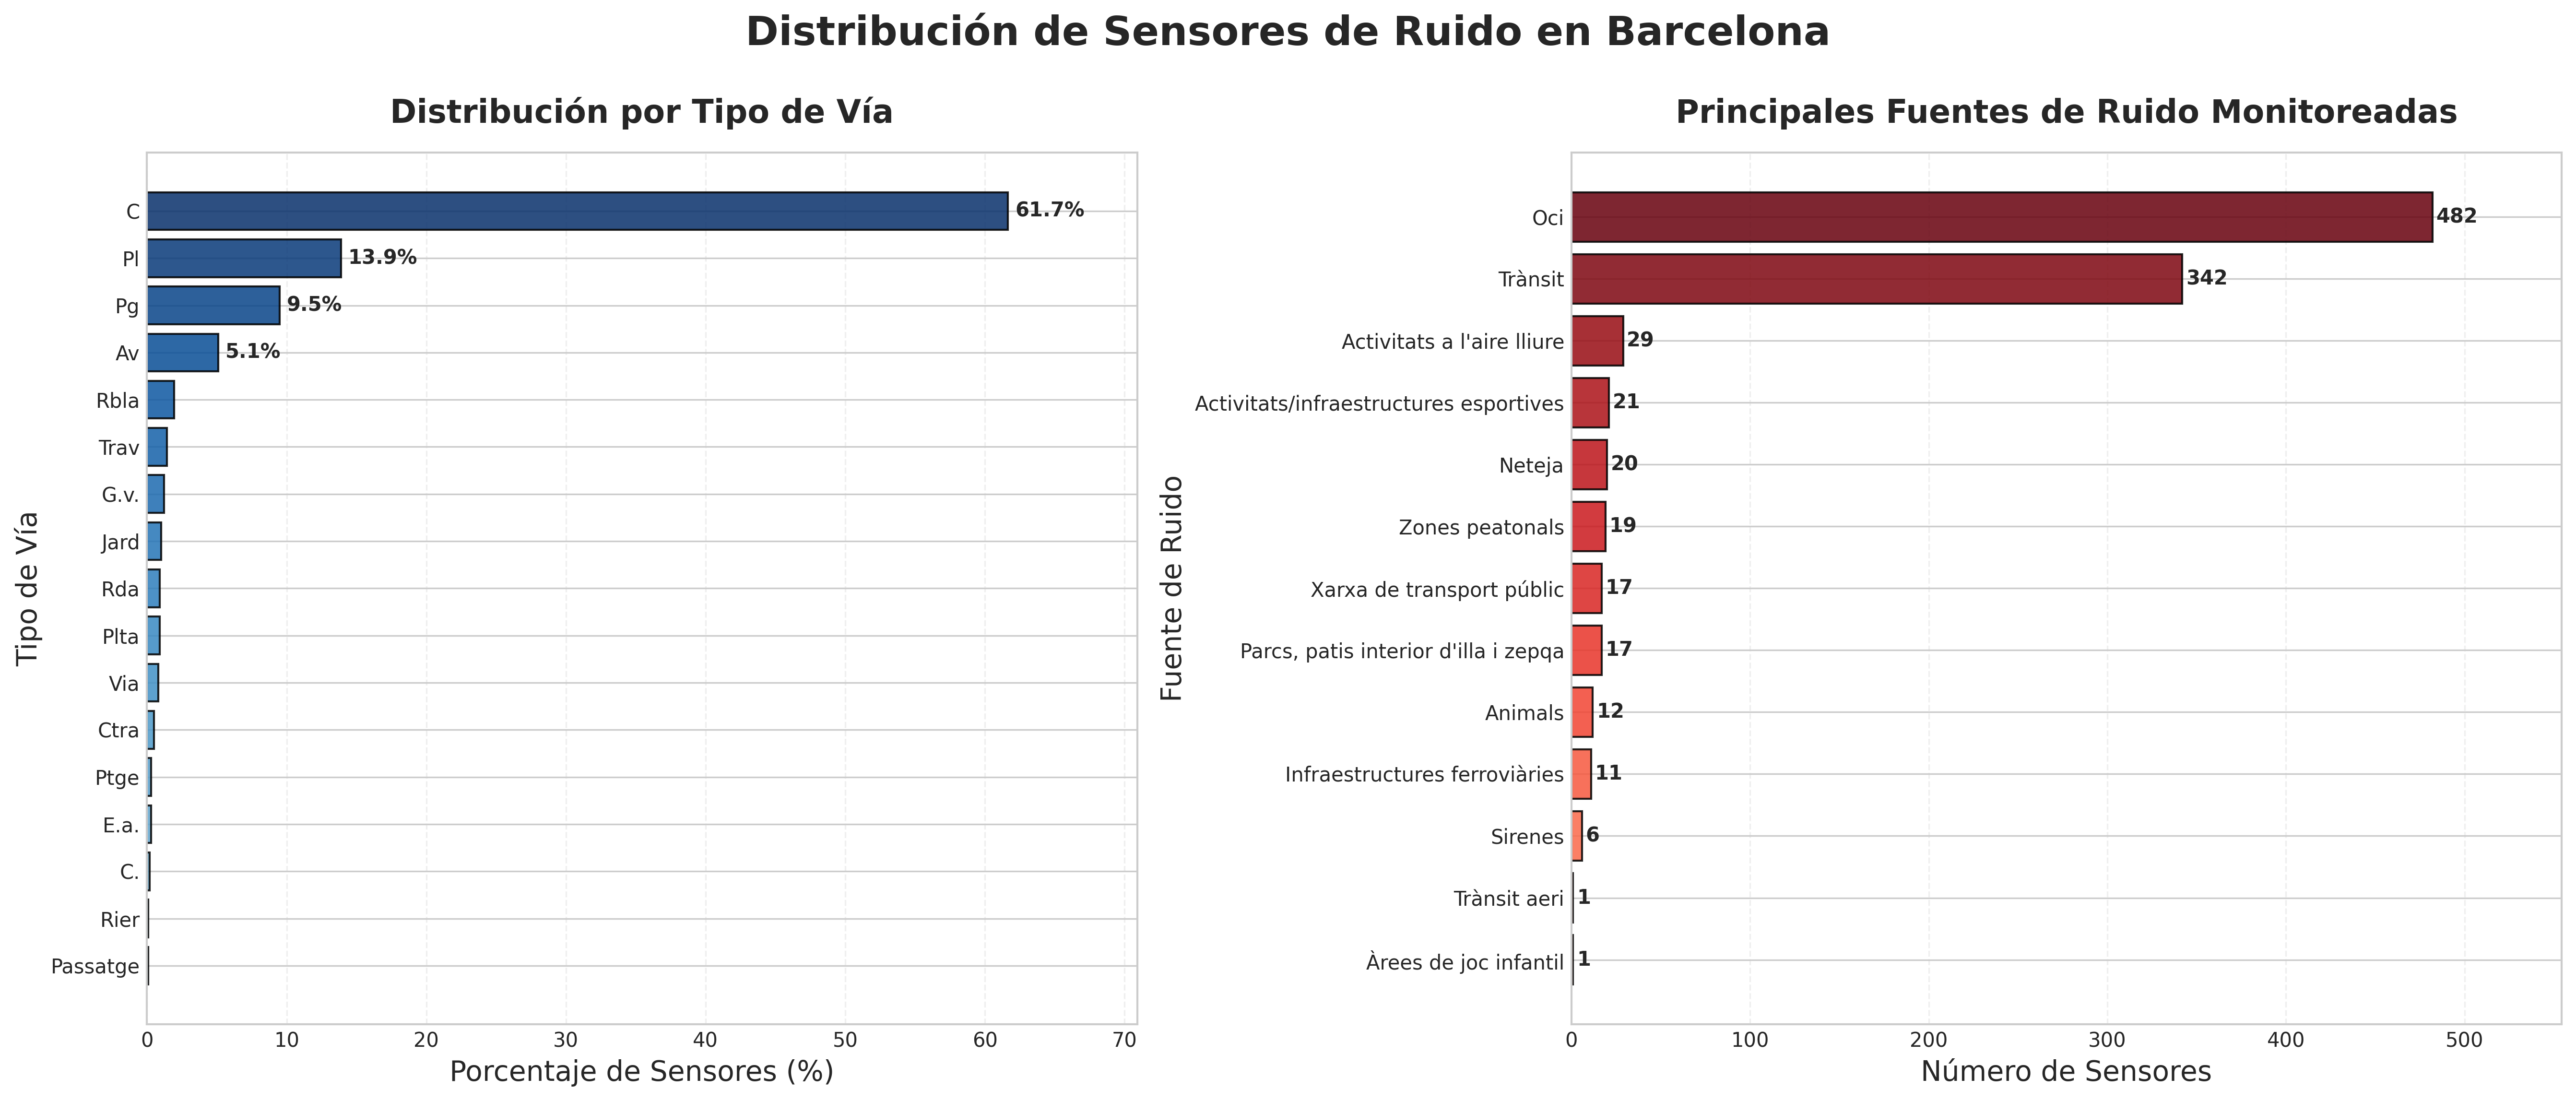


📋 RESUMEN DEL ANÁLISIS DE SENSORES

📍 Total de sensores analizados: 978

🛣️  Top 3 tipos de vía con más sensores:
   16. Passatge: 0.1%
   17. Rier: 0.1%
   15. C.: 0.2%

🔊 Top 3 fuentes de ruido monitoreadas:
   3. Activitats a l'aire lliure: 29 sensores
   2. Trànsit: 342 sensores
   1. Oci: 482 sensores

🏘️  Top 3 distritos con más sensores:
   - Ciutat vella: 180 sensores
   - Eixample: 177 sensores
   - Gràcia: 127 sensores

💡 RECOMENDACIONES BASADAS EN EL ANÁLISIS

📊 Para futuros análisis:
   1. Cruza estos datos con tus mediciones temporales de ruido
   2. Analiza patrones por distrito y tipo de fuente
   3. Compara zonas comerciales vs residenciales
   4. Estudia la relación entre tipo de vía y niveles máximos de ruido

🎯 Para políticas públicas:
   1. Las áreas con alta concentración de sensores en 'Trànsit' requieren monitoreo continuo
   2. Las zonas con fuentes de 'Oci' pueden necesitar regulación en horarios nocturnos
   3. Priorizar intervenciones en distritos con mayor 

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib as mpl
from matplotlib import font_manager

# --- 1. CONFIGURACIÓN DE ESTILO COMPATIBLE ---
# Intentar usar estilos seaborn compatibles
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        # Fallback: usar estilo por defecto con mejoras manuales
        plt.rcParams.update({
            'axes.facecolor': 'white',
            'axes.edgecolor': '#333333',
            'axes.grid': True,
            'grid.color': '#e0e0e0',
            'grid.linestyle': '--',
            'grid.linewidth': 0.8,
            'axes.linewidth': 1.2,
            'xtick.color': '#333333',
            'ytick.color': '#333333',
            'text.color': '#333333',
            'figure.facecolor': 'white'
        })

# Configuración adicional para alta calidad
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']

# --- 2. CARGAR Y PREPARAR DATOS ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
archivo_sensores = os.path.join(base_path, 'XarxaSoroll_EquipsMonitor_Instal.csv')

print("🔍 Verificando archivos en el directorio...")
print(f"Ruta base: {base_path}")
print("Archivos disponibles:")
for file in os.listdir(base_path):
    if file.endswith('.csv') or file.endswith('.png') or file.endswith('.html'):
        print(f"  - {file}")

if not os.path.exists(archivo_sensores):
    print(f"\n❌ Error: El archivo no se encuentra en {archivo_sensores}")
    print("Verifica que el archivo 'XarxaSoroll_EquipsMonitor_Instal.csv' esté en tu carpeta de Google Drive")
else:
    print("\n✅ Archivo de sensores encontrado. Cargando datos...")
    sensor_locations = pd.read_csv(archivo_sensores)

    # --- 3. LIMPIEZA DE DATOS ---
    print("\n🧹 Limpiando y preparando datos...")

    # Limpiar espacios en blanco en columnas categóricas
    for col in ['Tipus_Via', 'Font', 'Nom_Districte', 'Nom_Barri']:
        if col in sensor_locations.columns:
            sensor_locations[col] = sensor_locations[col].str.strip().str.capitalize()

    # --- 4. ANÁLISIS Y VISUALIZACIÓN ---
    print("📊 Generando visualizaciones claras y profesionales...")

    # Figura principal con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=300)
    fig.suptitle('Distribución de Sensores de Ruido en Barcelona', fontsize=20, fontweight='bold', y=0.95)

    # --- GRÁFICO 1: Distribución por Tipo de Vía ---
    via_counts = sensor_locations['Tipus_Via'].value_counts(normalize=True).reset_index()
    via_counts.columns = ['Tipus_Via', 'Porcentaje']
    via_counts['Porcentaje'] = via_counts['Porcentaje'] * 100

    # Filtrar tipos de vía con menos del 2% para evitar saturación
    via_counts['label'] = via_counts.apply(
        lambda x: f"{x['Tipus_Via']} ({x['Porcentaje']:.1f}%)" if x['Porcentaje'] > 2 else '',
        axis=1
    )

    # Ordenar por porcentaje
    via_counts = via_counts.sort_values('Porcentaje', ascending=True)

    # Crear colores graduales
    n = len(via_counts)
    colors = plt.cm.Blues(np.linspace(0.4, 1, n))

    # Gráfico de barras horizontales (mejor que pie chart para claridad)
    bars1 = ax1.barh(via_counts['Tipus_Via'], via_counts['Porcentaje'], color=colors, edgecolor='black', alpha=0.85)

    # Añadir valores en las barras
    for i, bar in enumerate(bars1):
        width = bar.get_width()
        if width > 2:  # Solo mostrar etiquetas para barras significativas
            ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    va='center', ha='left', fontsize=10, fontweight='bold')

    ax1.set_title('Distribución por Tipo de Vía', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel('Porcentaje de Sensores (%)', fontsize=14)
    ax1.set_ylabel('Tipo de Vía', fontsize=14)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_xlim(0, max(via_counts['Porcentaje']) * 1.15)

    # --- GRÁFICO 2: Distribución por Fuente de Ruido ---
    font_counts = sensor_locations['Font'].value_counts().reset_index()
    font_counts.columns = ['Fuente', 'Conteo']
    font_counts = font_counts.sort_values('Conteo', ascending=True)

    # Crear colores graduales
    n = len(font_counts)
    colors = plt.cm.Reds(np.linspace(0.4, 1, n))

    bars2 = ax2.barh(font_counts['Fuente'], font_counts['Conteo'], color=colors, edgecolor='black', alpha=0.85)

    # Añadir valores en las barras
    for i, bar in enumerate(bars2):
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
                f'{int(width)}',
                va='center', ha='left', fontsize=10, fontweight='bold')

    ax2.set_title('Principales Fuentes de Ruido Monitoreadas', fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel('Número de Sensores', fontsize=14)
    ax2.set_ylabel('Fuente de Ruido', fontsize=14)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    ax2.set_xlim(0, max(font_counts['Conteo']) * 1.15)

    # Ajustar diseño
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # --- 5. GUARDAR Y MOSTRAR RESULTADOS ---
    output_path = os.path.join(base_path, 'analisis_sensores_claro.png')
    plt.savefig(output_path, bbox_inches='tight', dpi=300)

    print(f"\n✅ Visualizaciones generadas con éxito!")
    print(f"📁 Archivo guardado en: {output_path}")
    print("\n🎨 Características de las visualizaciones:")
    print("   - Alta resolución (300 DPI)")
    print("   - Colores graduales para mejor percepción")
    print("   - Etiquetas directas en las barras")
    print("   - Diseño limpio y profesional")

    # Mostrar el gráfico
    plt.show()

    # --- 6. ANÁLISIS RESUMEN ---
    print("\n" + "="*70)
    print("📋 RESUMEN DEL ANÁLISIS DE SENSORES")
    print("="*70)

    # Estadísticas clave
    total_sensores = len(sensor_locations)
    print(f"\n📍 Total de sensores analizados: {total_sensores:,}")

    # Top 3 tipos de vía
    top_vias = via_counts.head(3)
    print("\n🛣️  Top 3 tipos de vía con más sensores:")
    for i, row in top_vias.iterrows():
        print(f"   {i+1}. {row['Tipus_Via']}: {row['Porcentaje']:.1f}%")

    # Top 3 fuentes de ruido
    top_fuentes = font_counts.tail(3)
    print("\n🔊 Top 3 fuentes de ruido monitoreadas:")
    for i, row in top_fuentes.iterrows():
        print(f"   {i+1}. {row['Fuente']}: {row['Conteo']:,} sensores")

    # Distribución por distrito (si existe la columna)
    if 'Nom_Districte' in sensor_locations.columns:
        distrito_counts = sensor_locations['Nom_Districte'].value_counts().head(3)
        print("\n🏘️  Top 3 distritos con más sensores:")
        for distrito, count in distrito_counts.items():
            print(f"   - {distrito}: {count:,} sensores")

    # --- 7. RECOMENDACIONES ---
    print("\n" + "="*70)
    print("💡 RECOMENDACIONES BASADAS EN EL ANÁLISIS")
    print("="*70)

    print("\n📊 Para futuros análisis:")
    print("   1. Cruza estos datos con tus mediciones temporales de ruido")
    print("   2. Analiza patrones por distrito y tipo de fuente")
    print("   3. Compara zonas comerciales vs residenciales")
    print("   4. Estudia la relación entre tipo de vía y niveles máximos de ruido")

    print("\n🎯 Para políticas públicas:")
    print("   1. Las áreas con alta concentración de sensores en 'Trànsit' requieren monitoreo continuo")
    print("   2. Las zonas con fuentes de 'Oci' pueden necesitar regulación en horarios nocturnos")
    print("   3. Priorizar intervenciones en distritos con mayor densidad de sensores")

In [ ]:
# Mapa de calor interactivo con Plotly
fig = px.density_mapbox(sensor_locations,
                       lat='Latitud', lon='Longitud',
                       radius=10, zoom=11,
                       mapbox_style="carto-positron",
                       title='Densidad de Sensores de Ruido en Barcelona',
                       center={"lat": 41.3851, "lon": 2.1734})

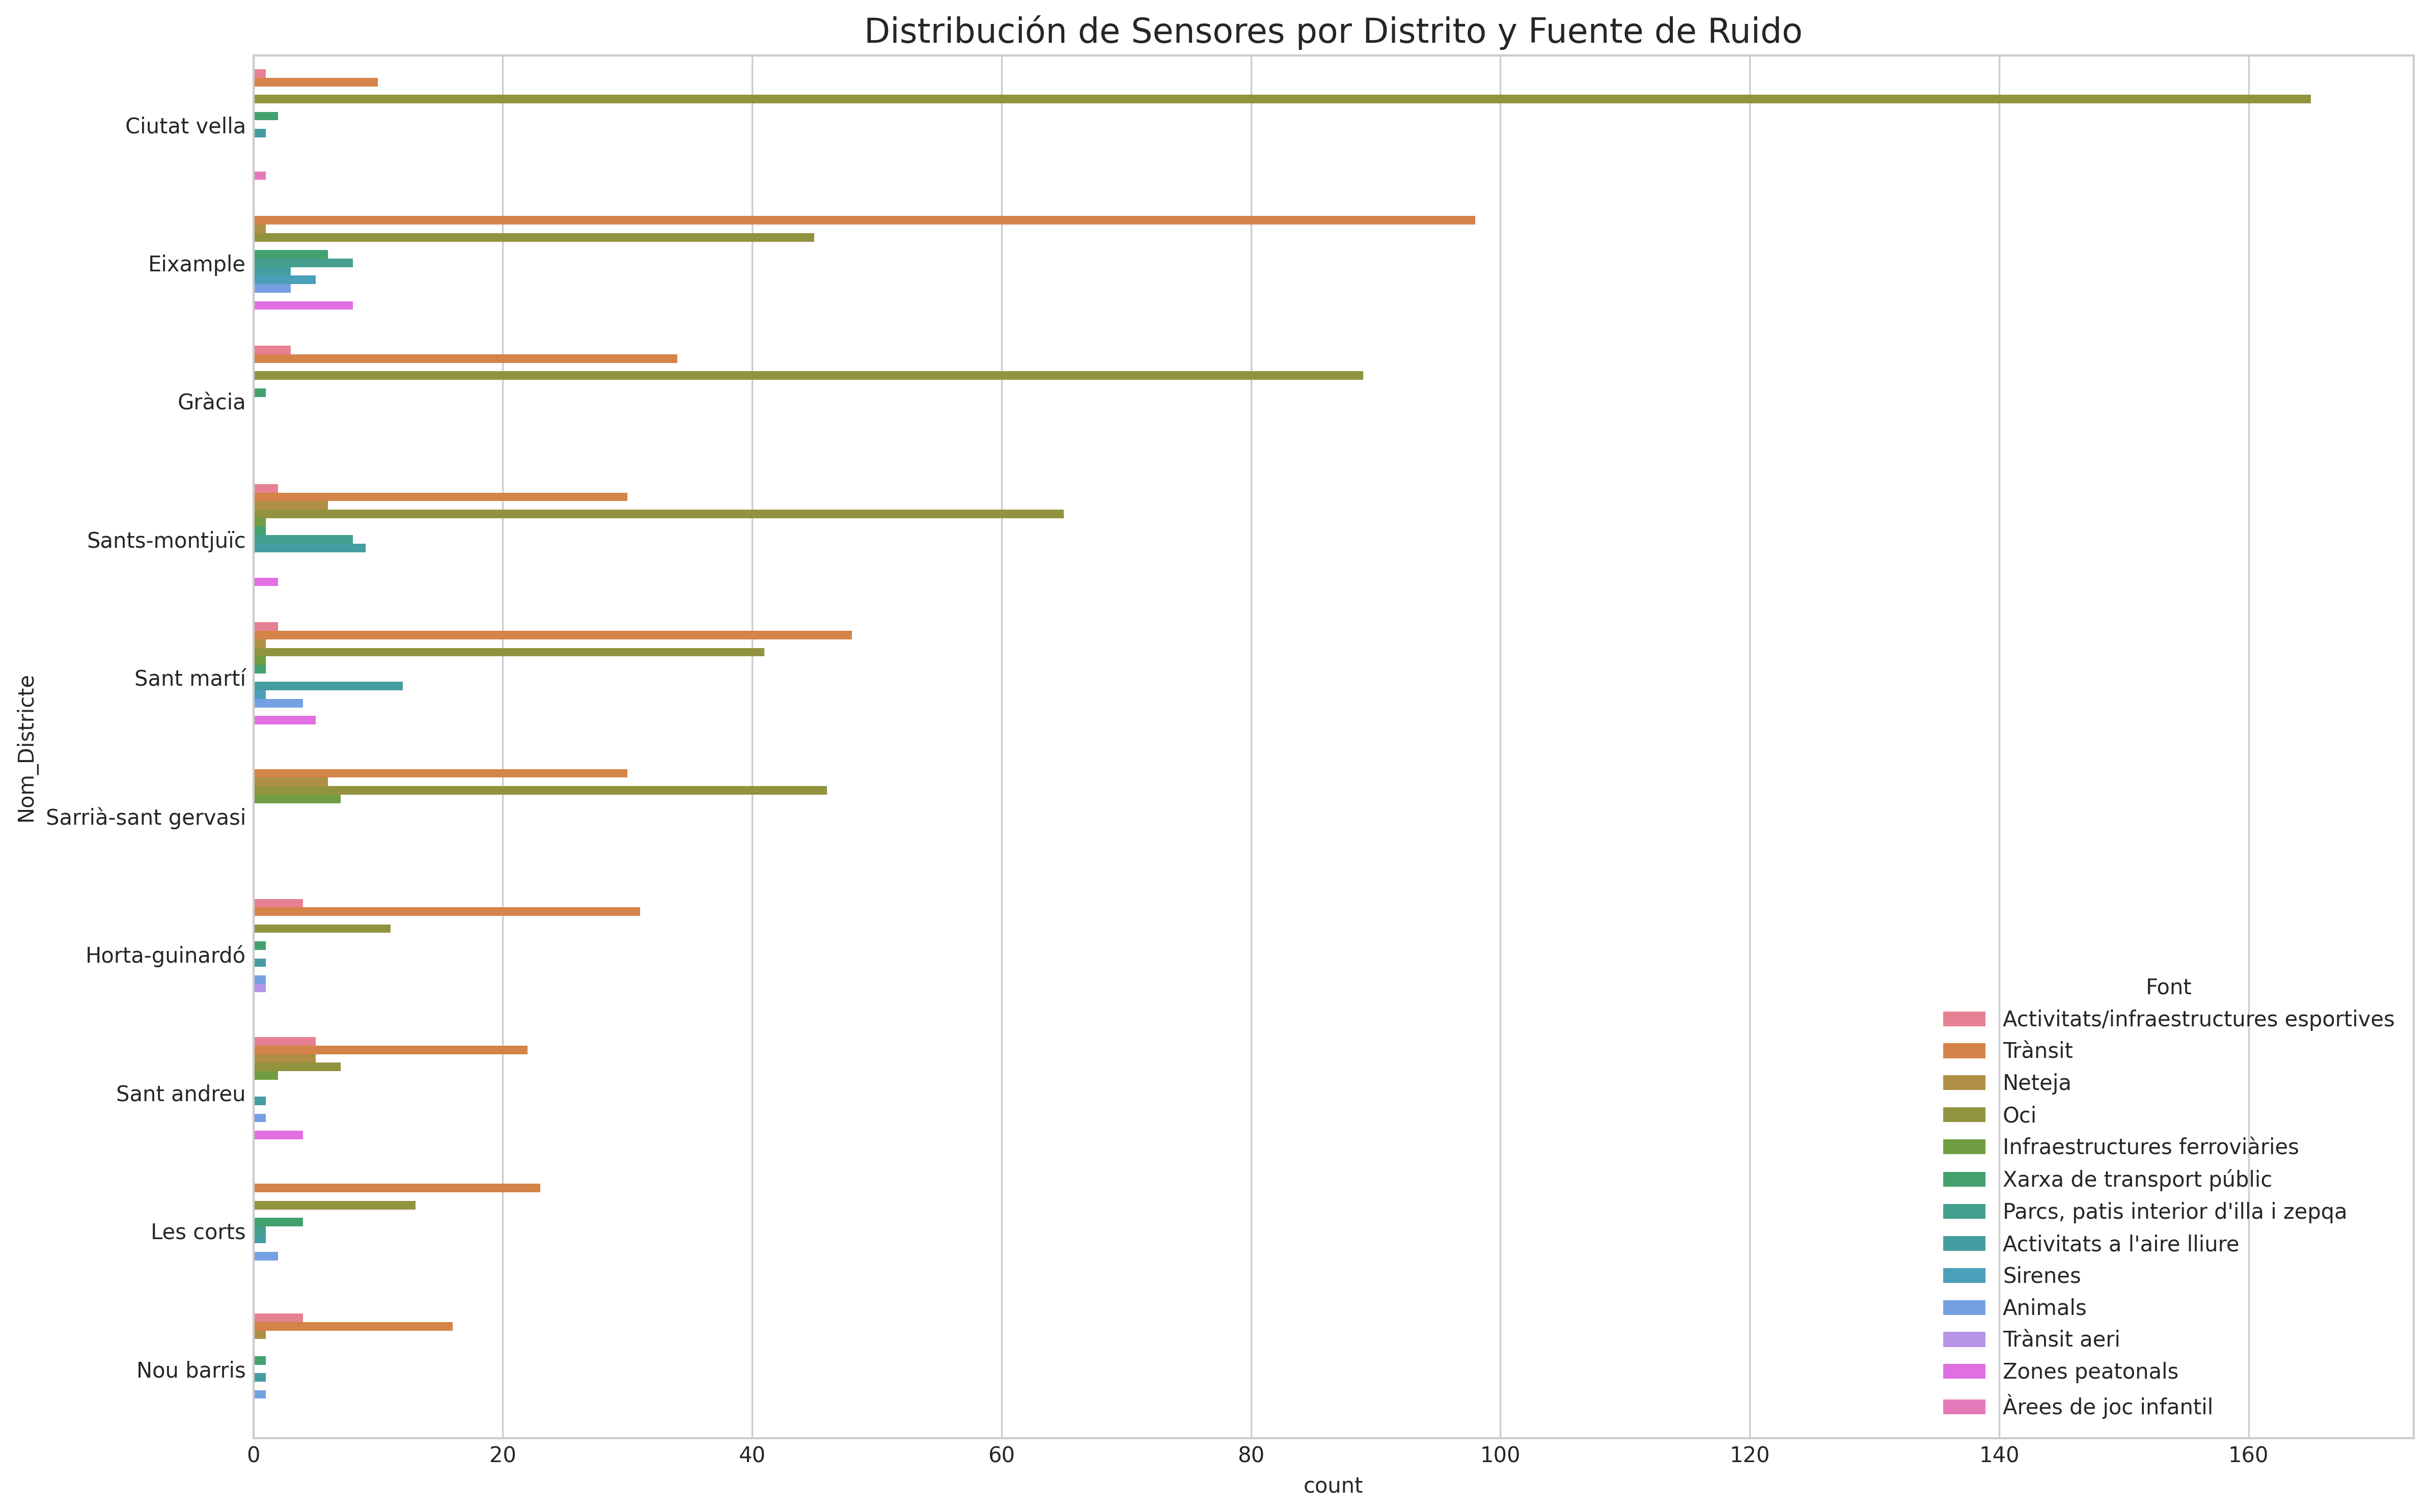

In [ ]:
# Gráfico de barras agrupadas por distrito y tipo de fuente
plt.figure(figsize=(16, 10))
sns.countplot(data=sensor_locations,
              y='Nom_Districte',
              hue='Font',
              order=sensor_locations['Nom_Districte'].value_counts().index)
plt.title('Distribución de Sensores por Distrito y Fuente de Ruido', fontsize=16)
plt.tight_layout()

Mounted at /content/drive
✅ Archivo de sensores encontrado. Cargando datos...

🔄 Convirtiendo fechas correctamente (formato día/mes/año)...
✅ Fechas convertidas correctamente

🧹 Limpiando y preparando datos...

📊 Analizando evolución temporal de instalaciones...
✅ Gráfico temporal guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/evolucion_instalaciones_temporal.png


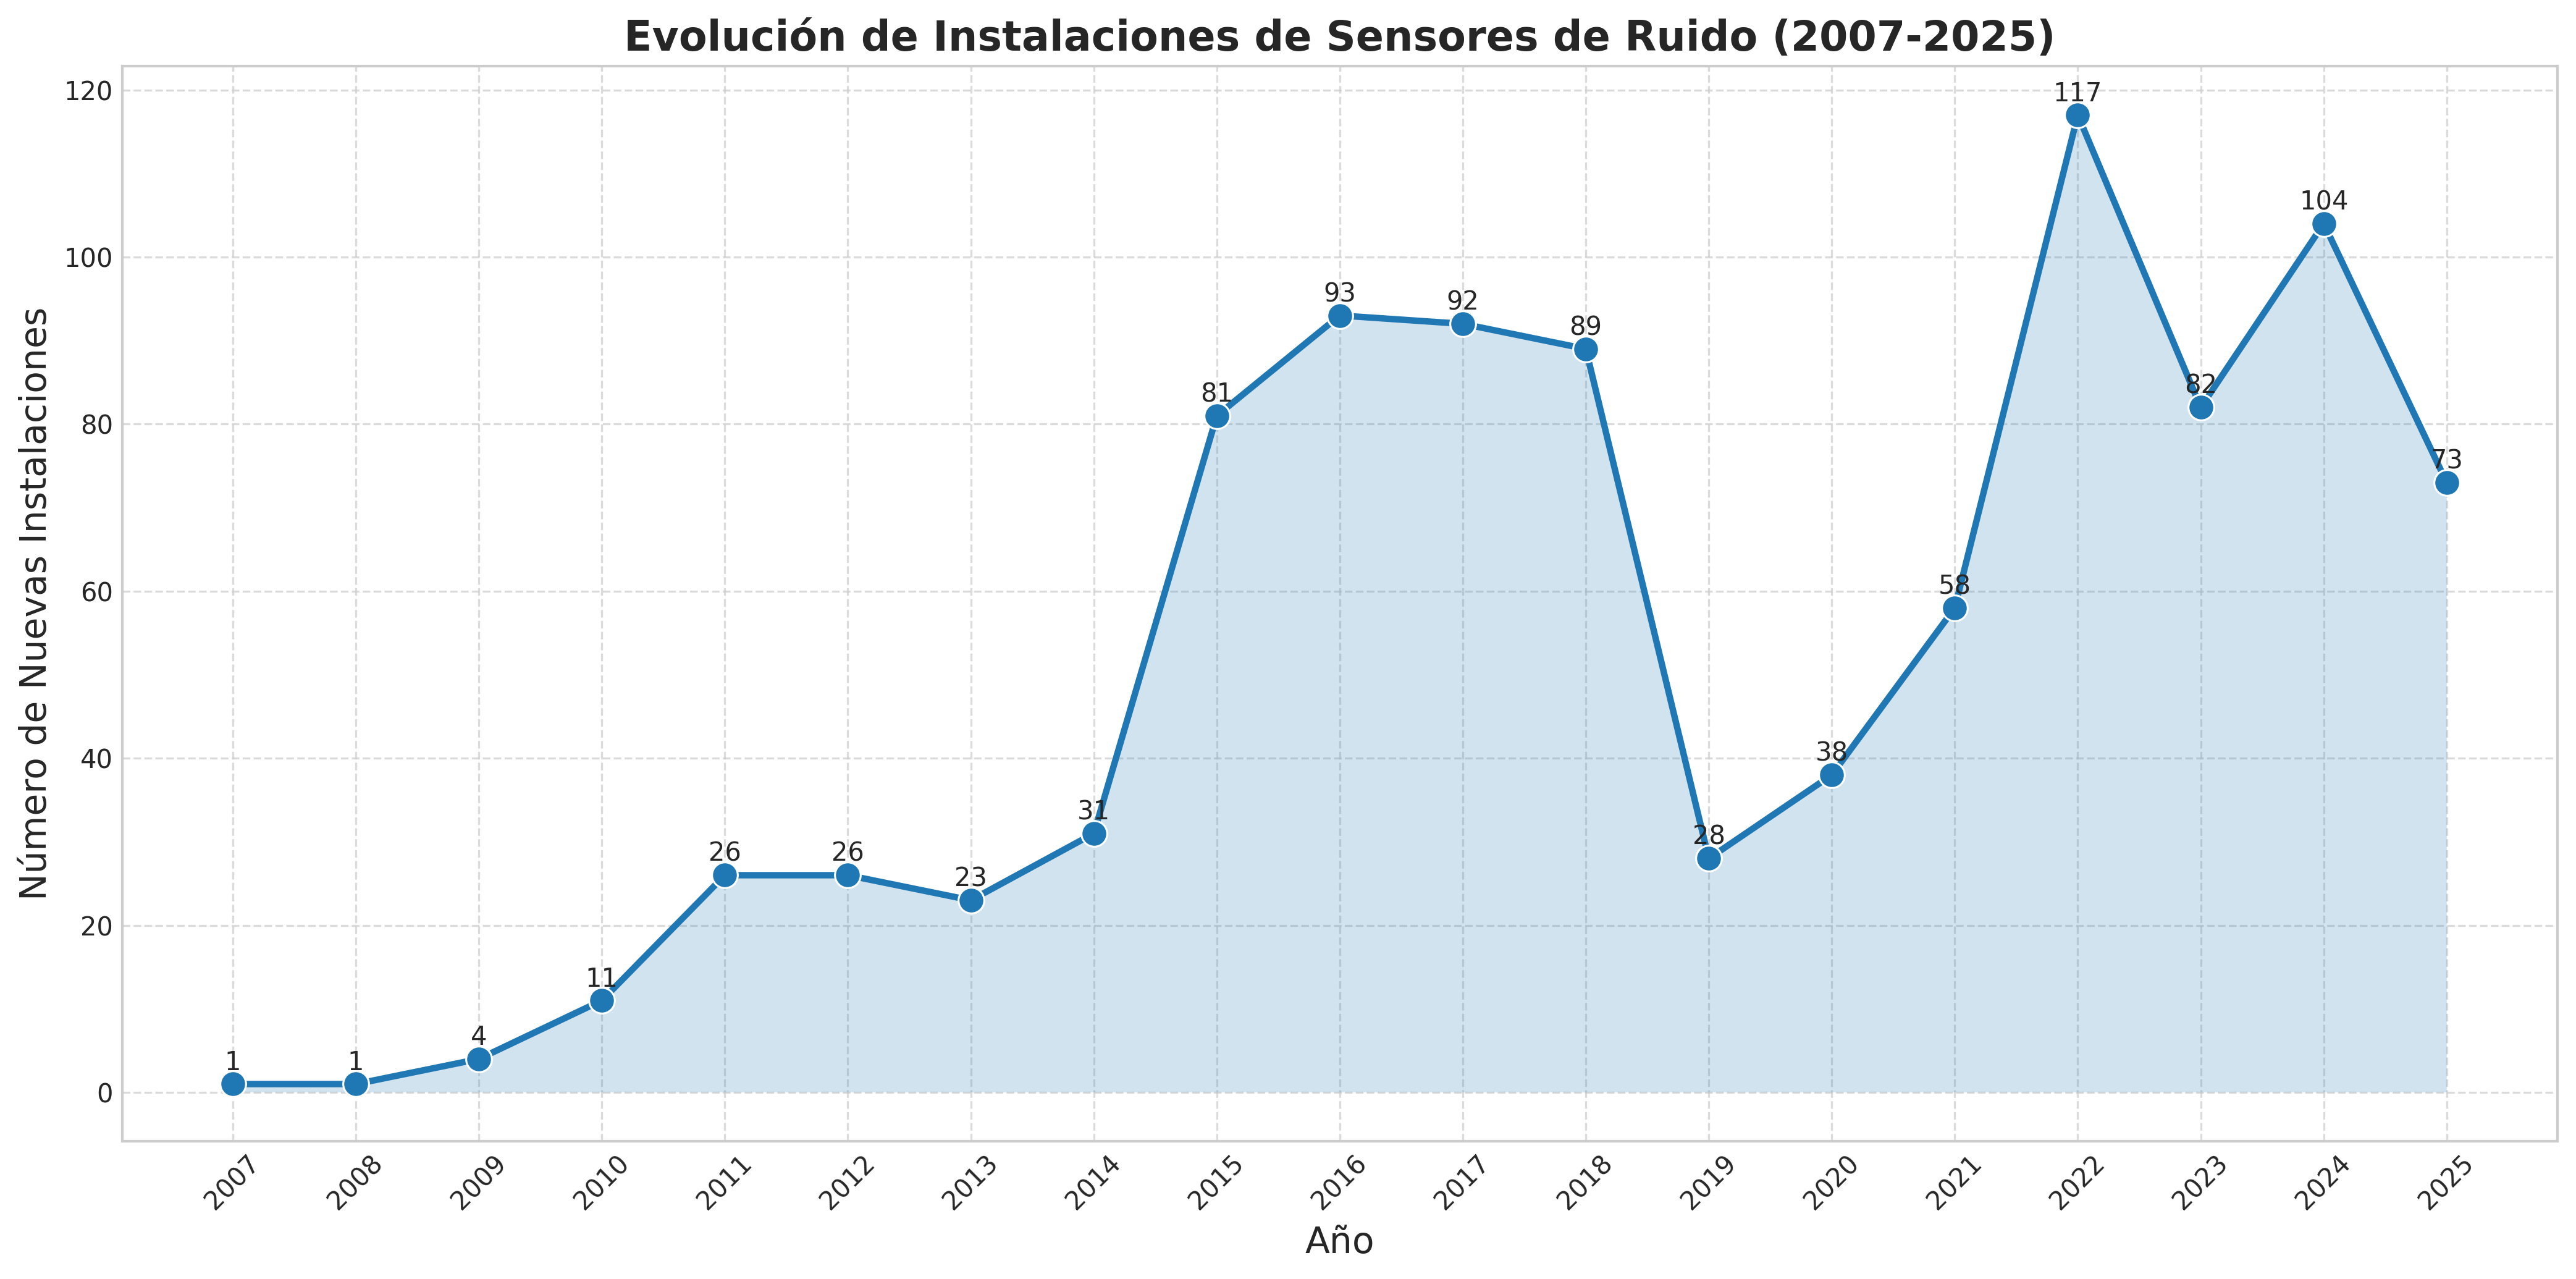


📊 Analizando distribución por tipo de vía...
✅ Gráfico por tipo de vía guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/distribucion_tipo_via.png


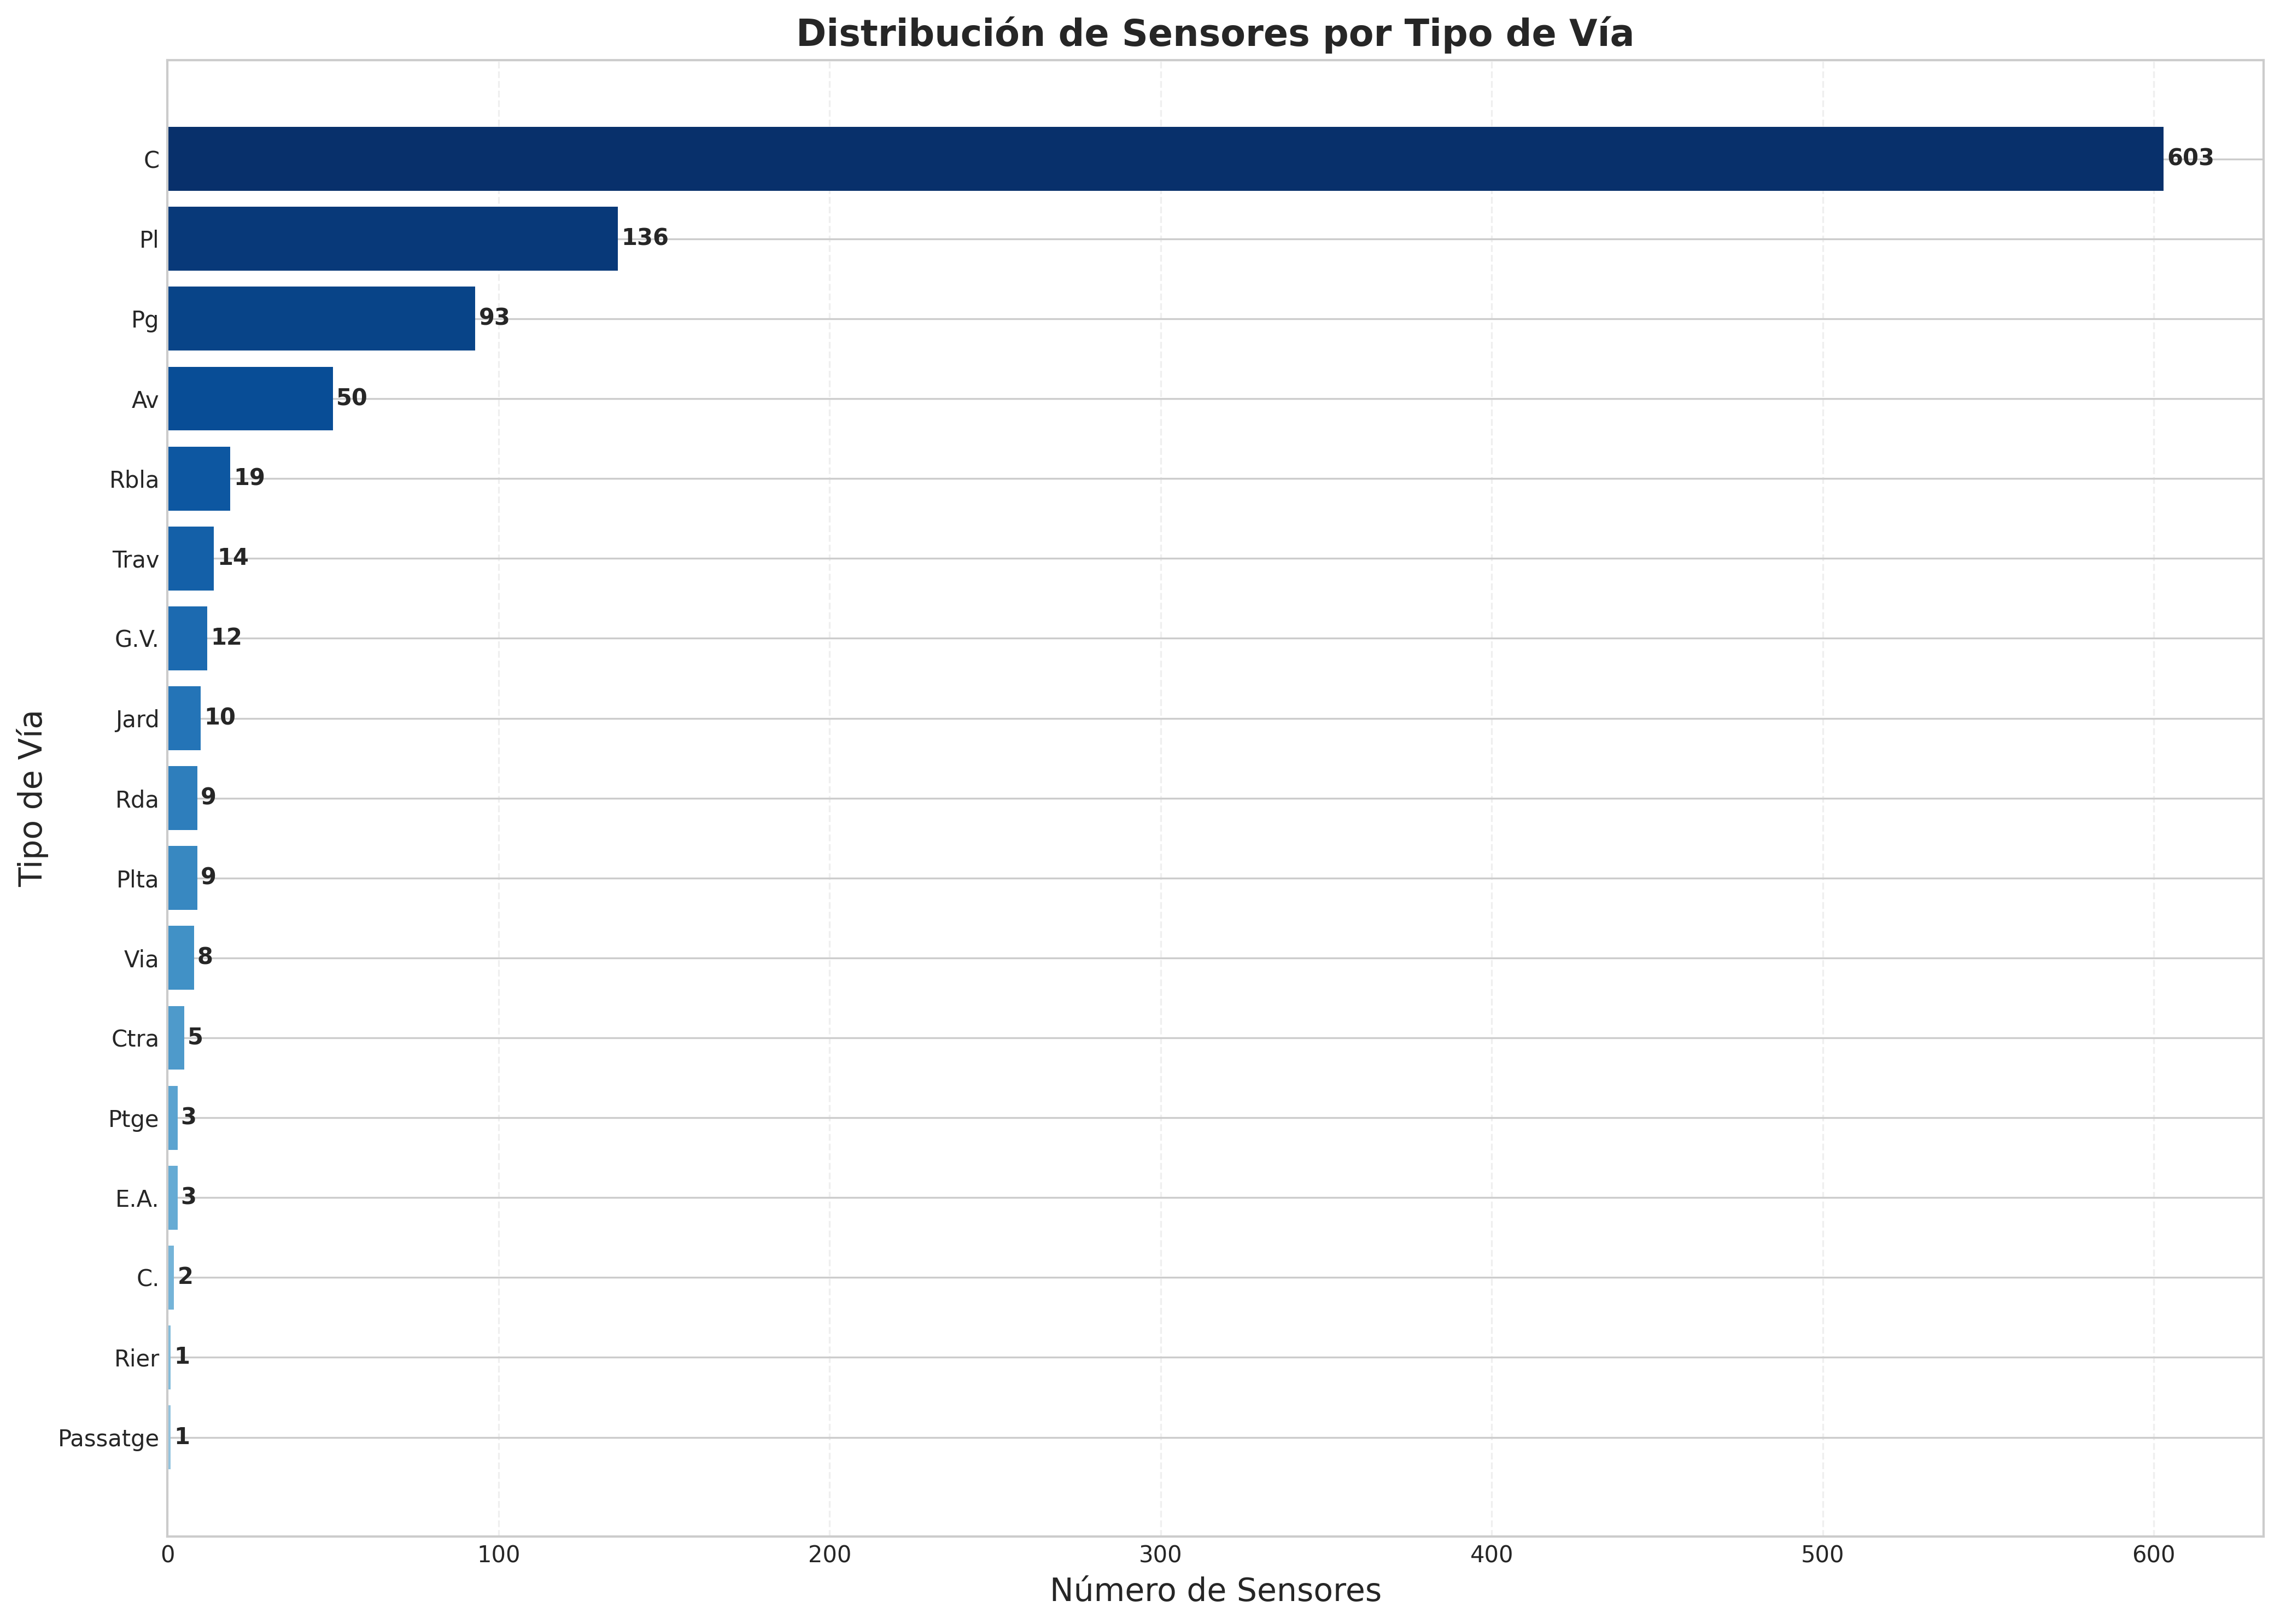


📊 Analizando distribución por fuente de ruido...
✅ Gráfico por fuente de ruido guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/distribucion_fuente_ruido.png


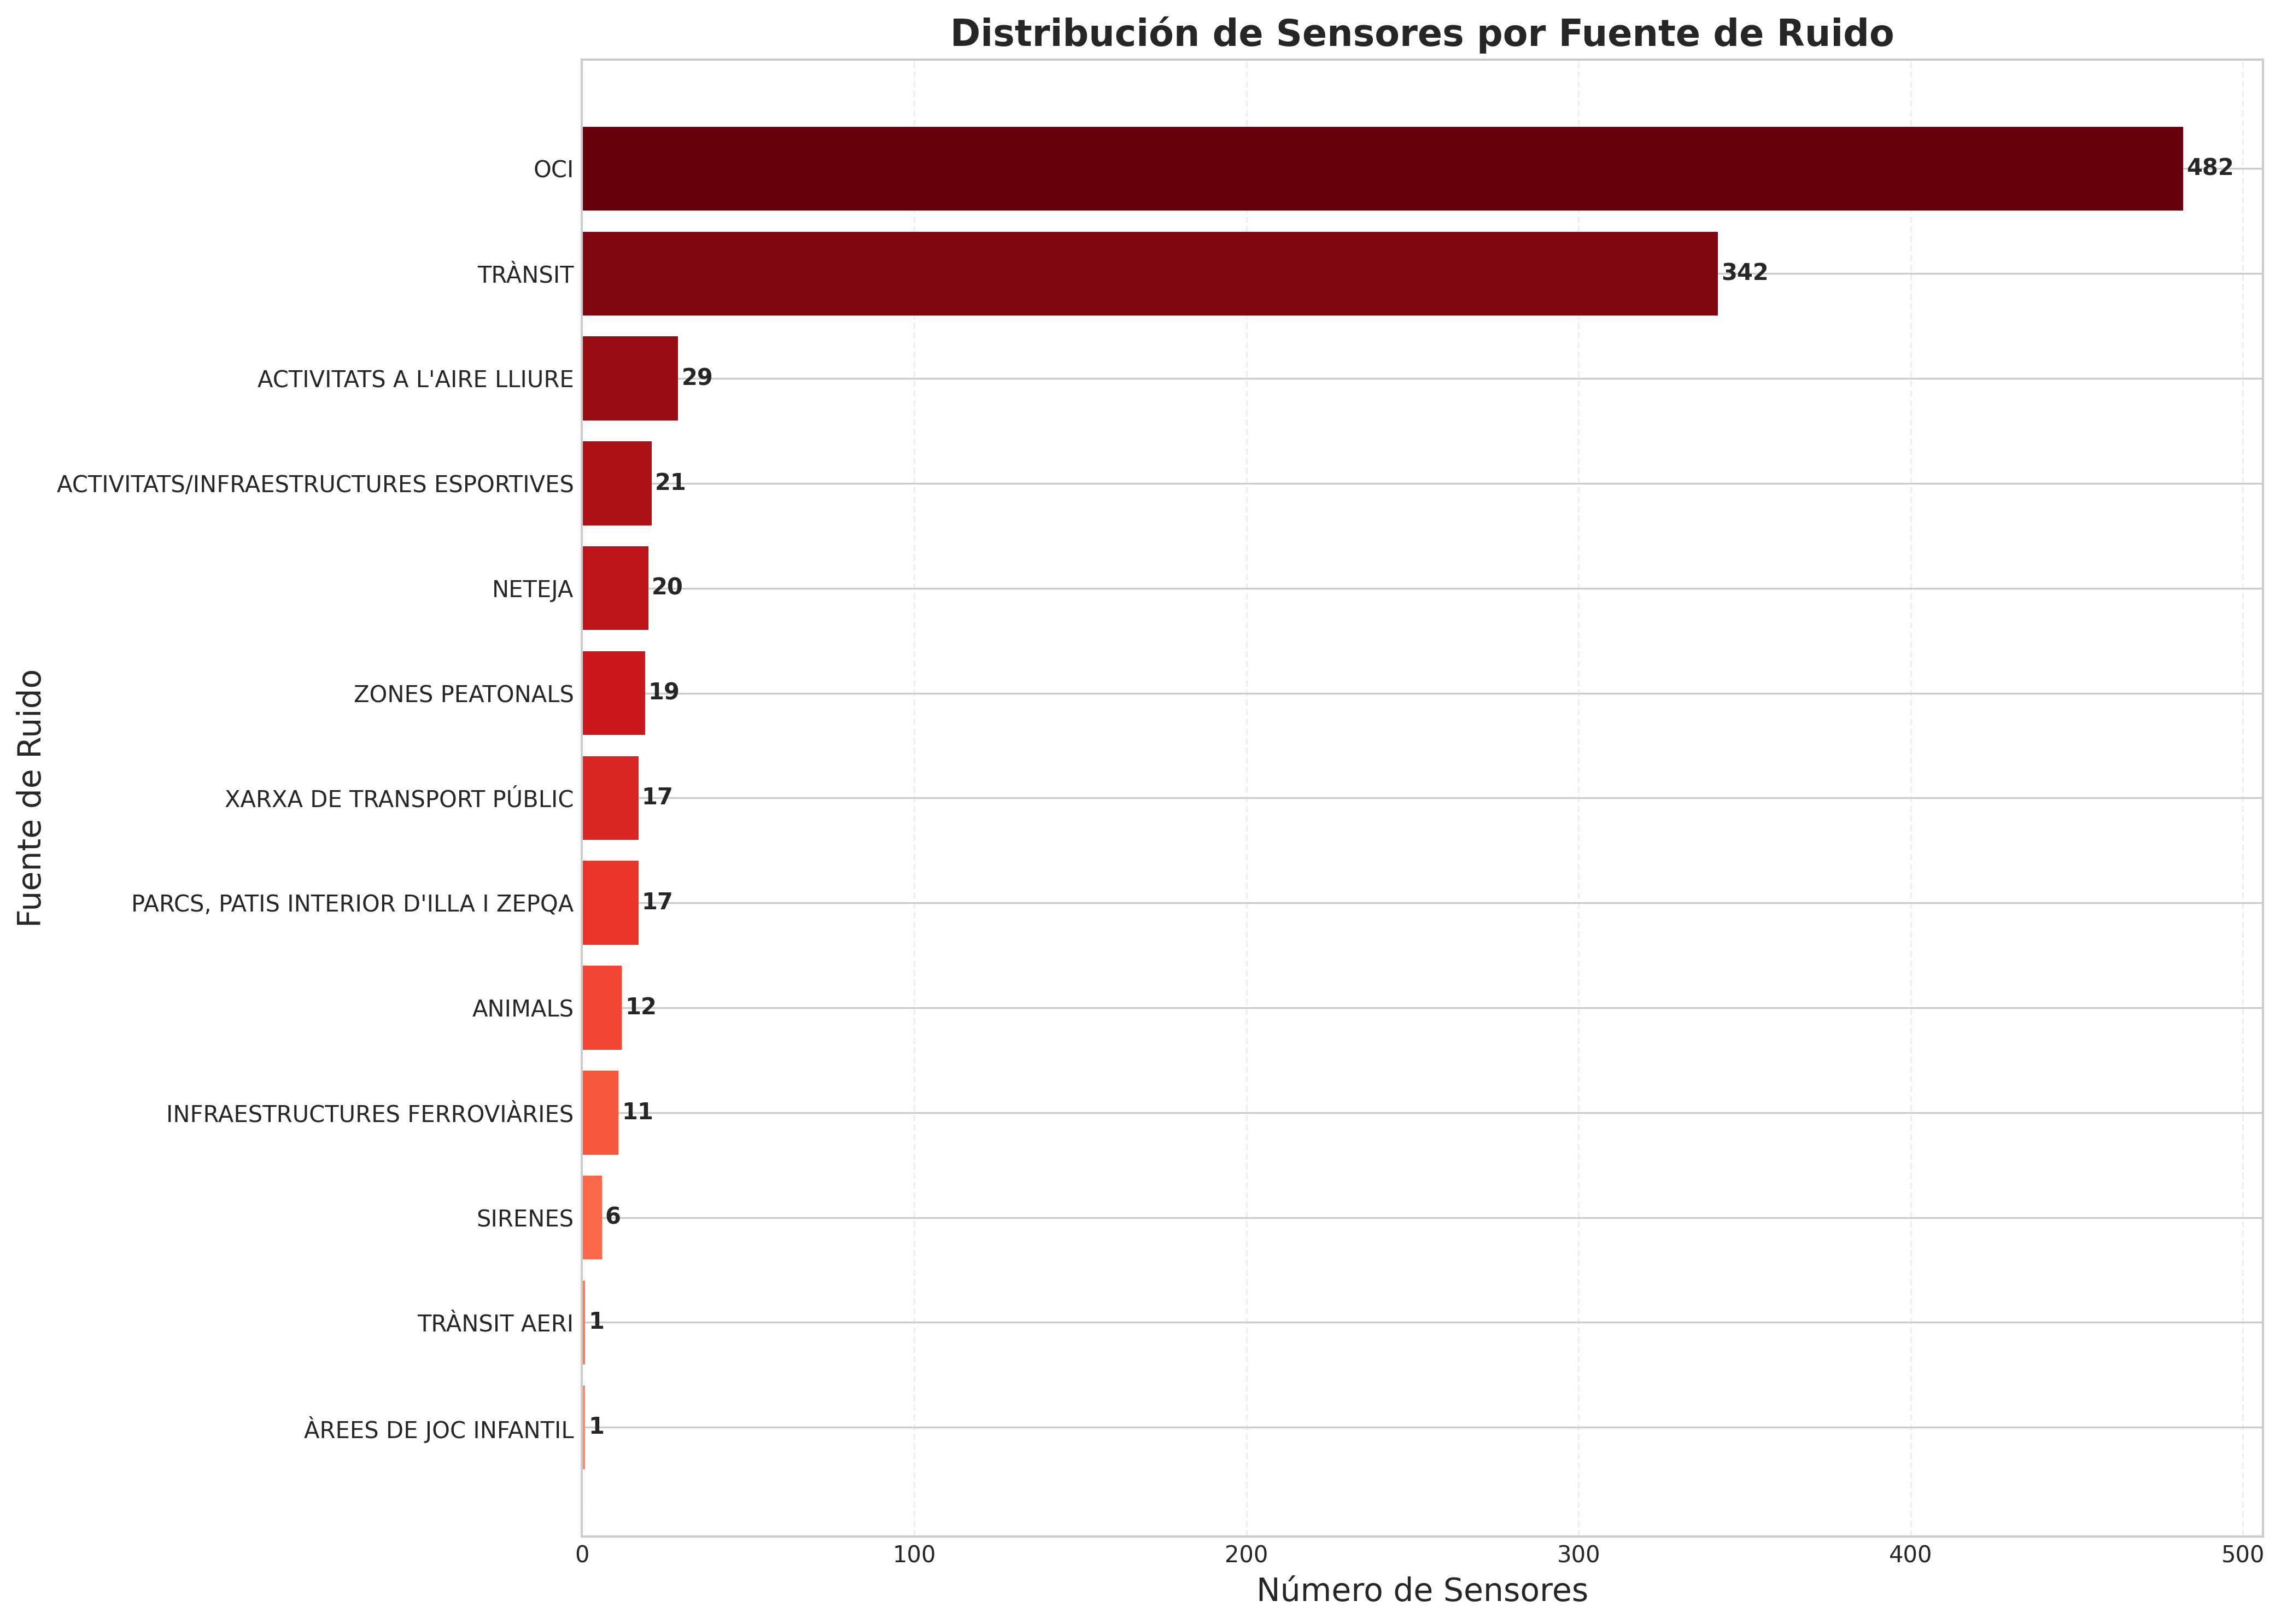


📊 Analizando distribución por distrito...
✅ Gráfico por distrito guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/distribucion_distritos.png


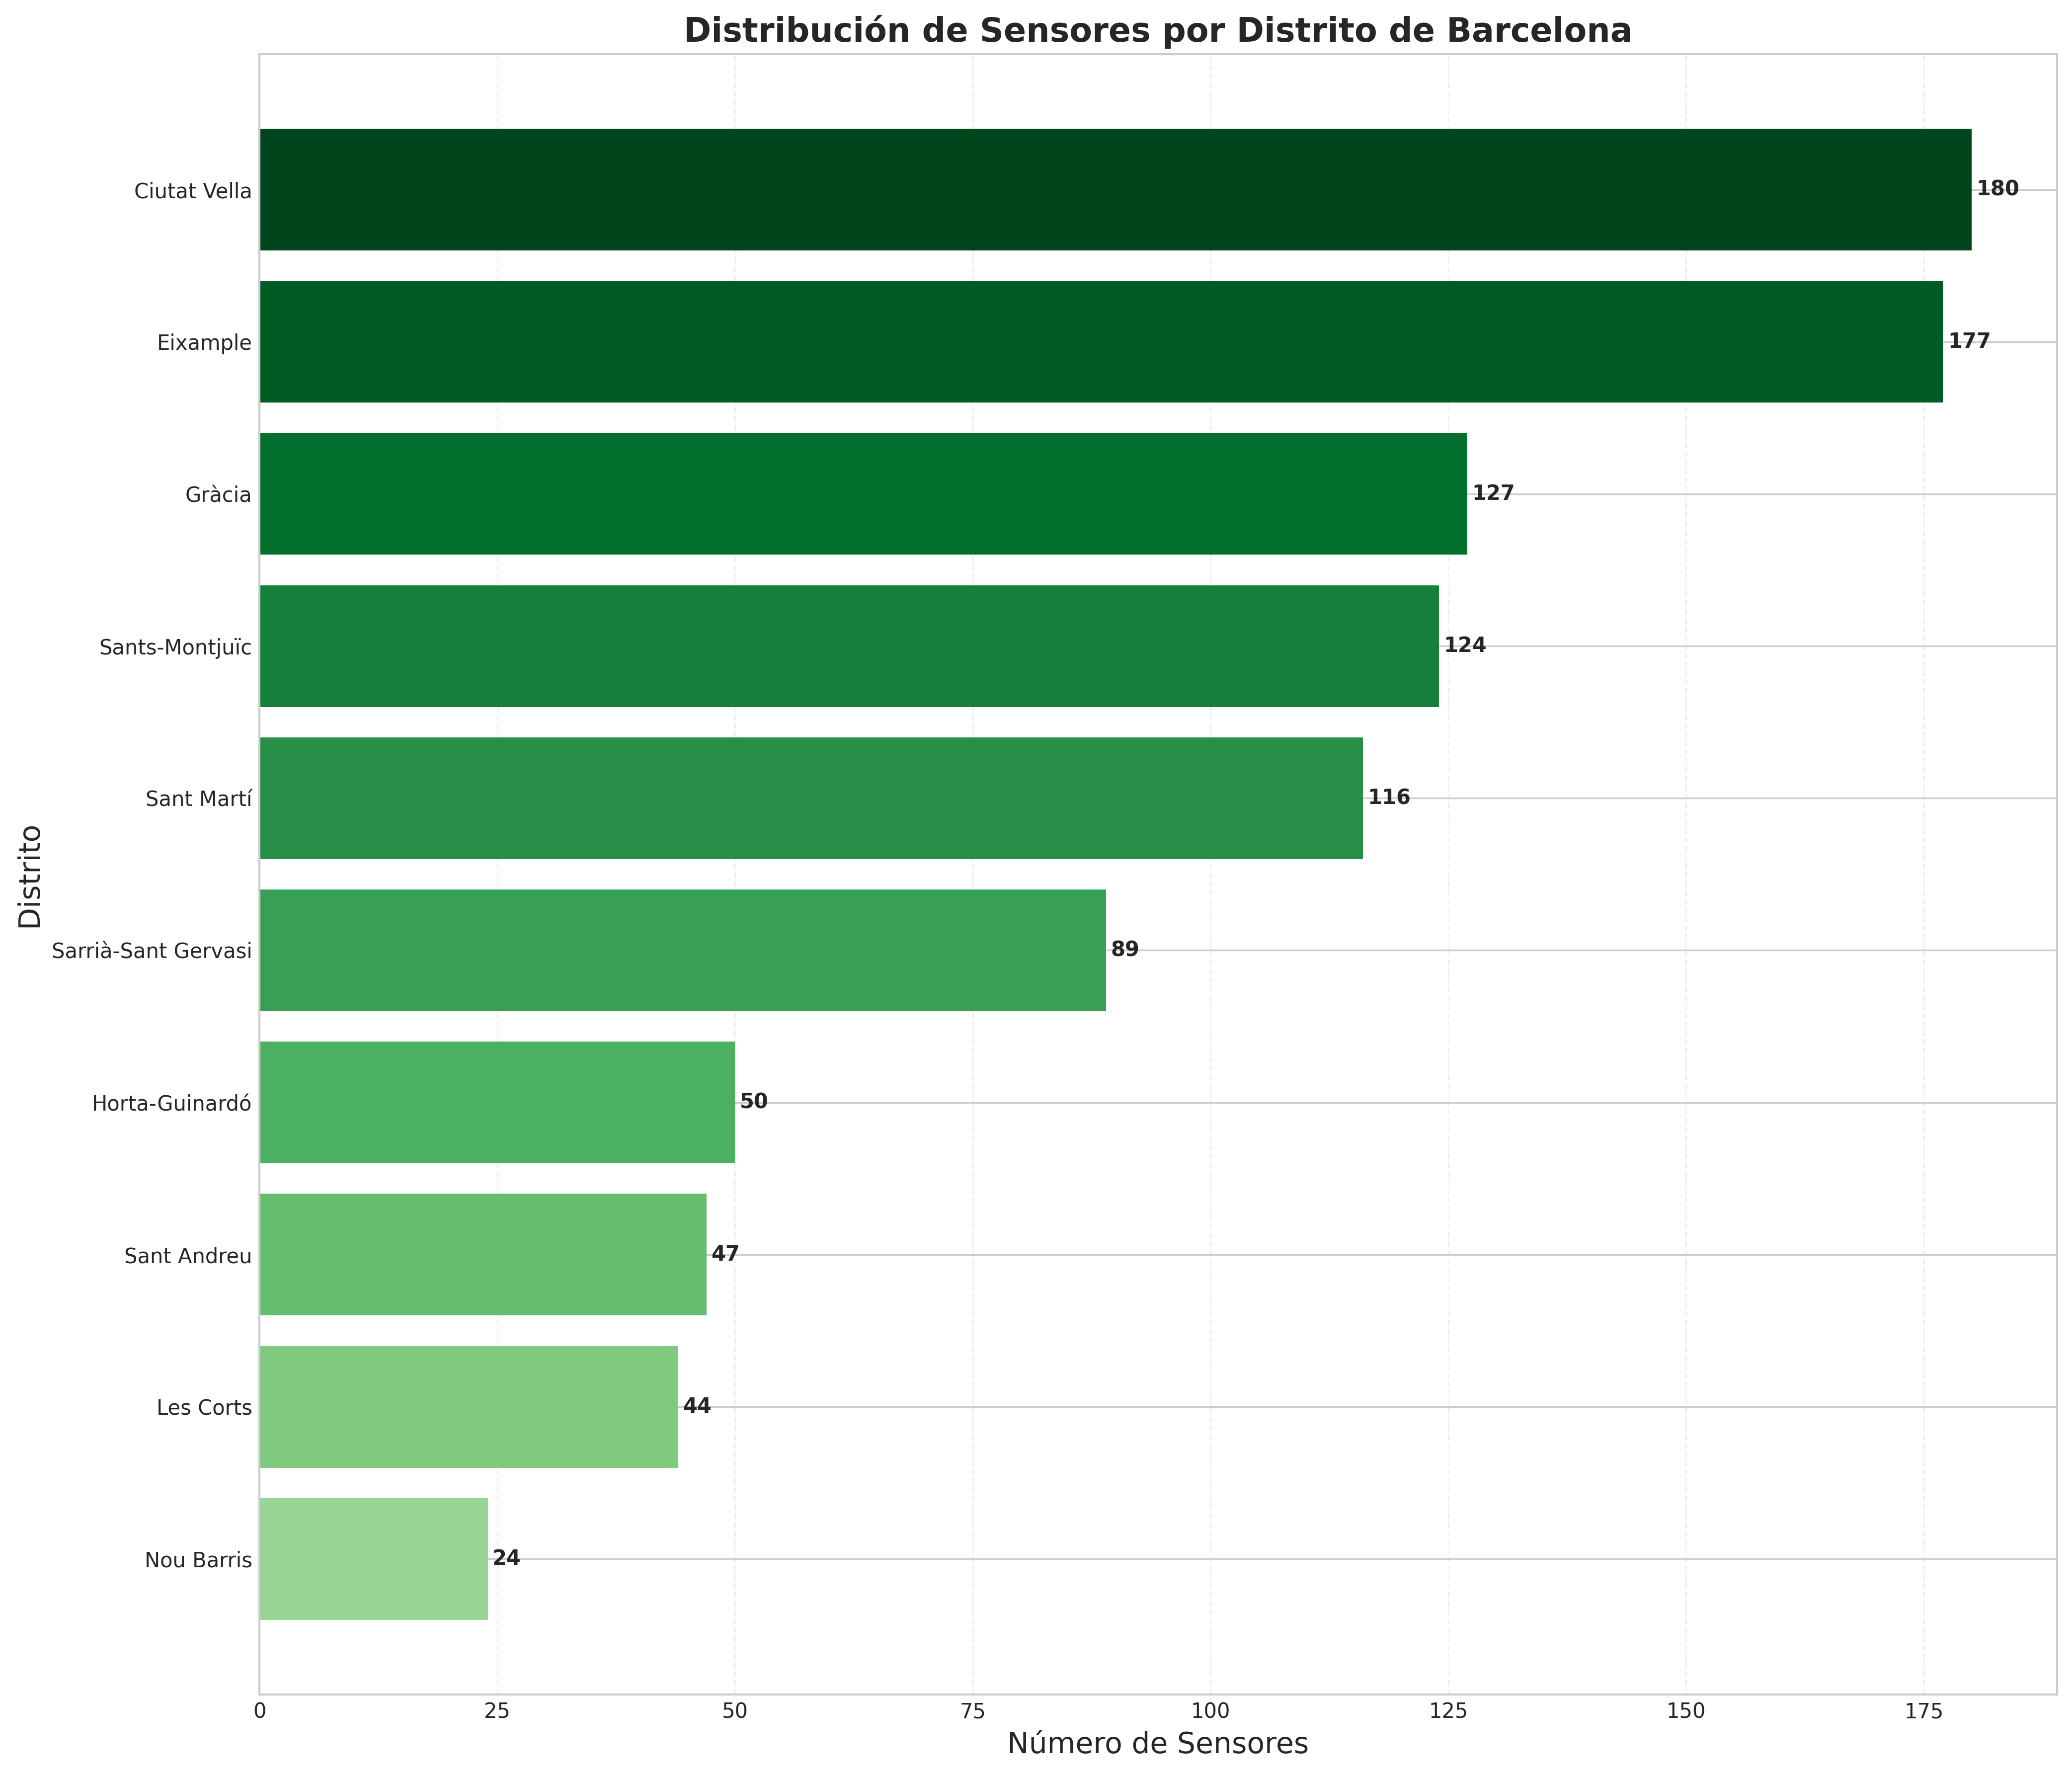


📊 Analizando duración de instalaciones...
✅ Gráfico de duración guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/duracion_instalaciones.png


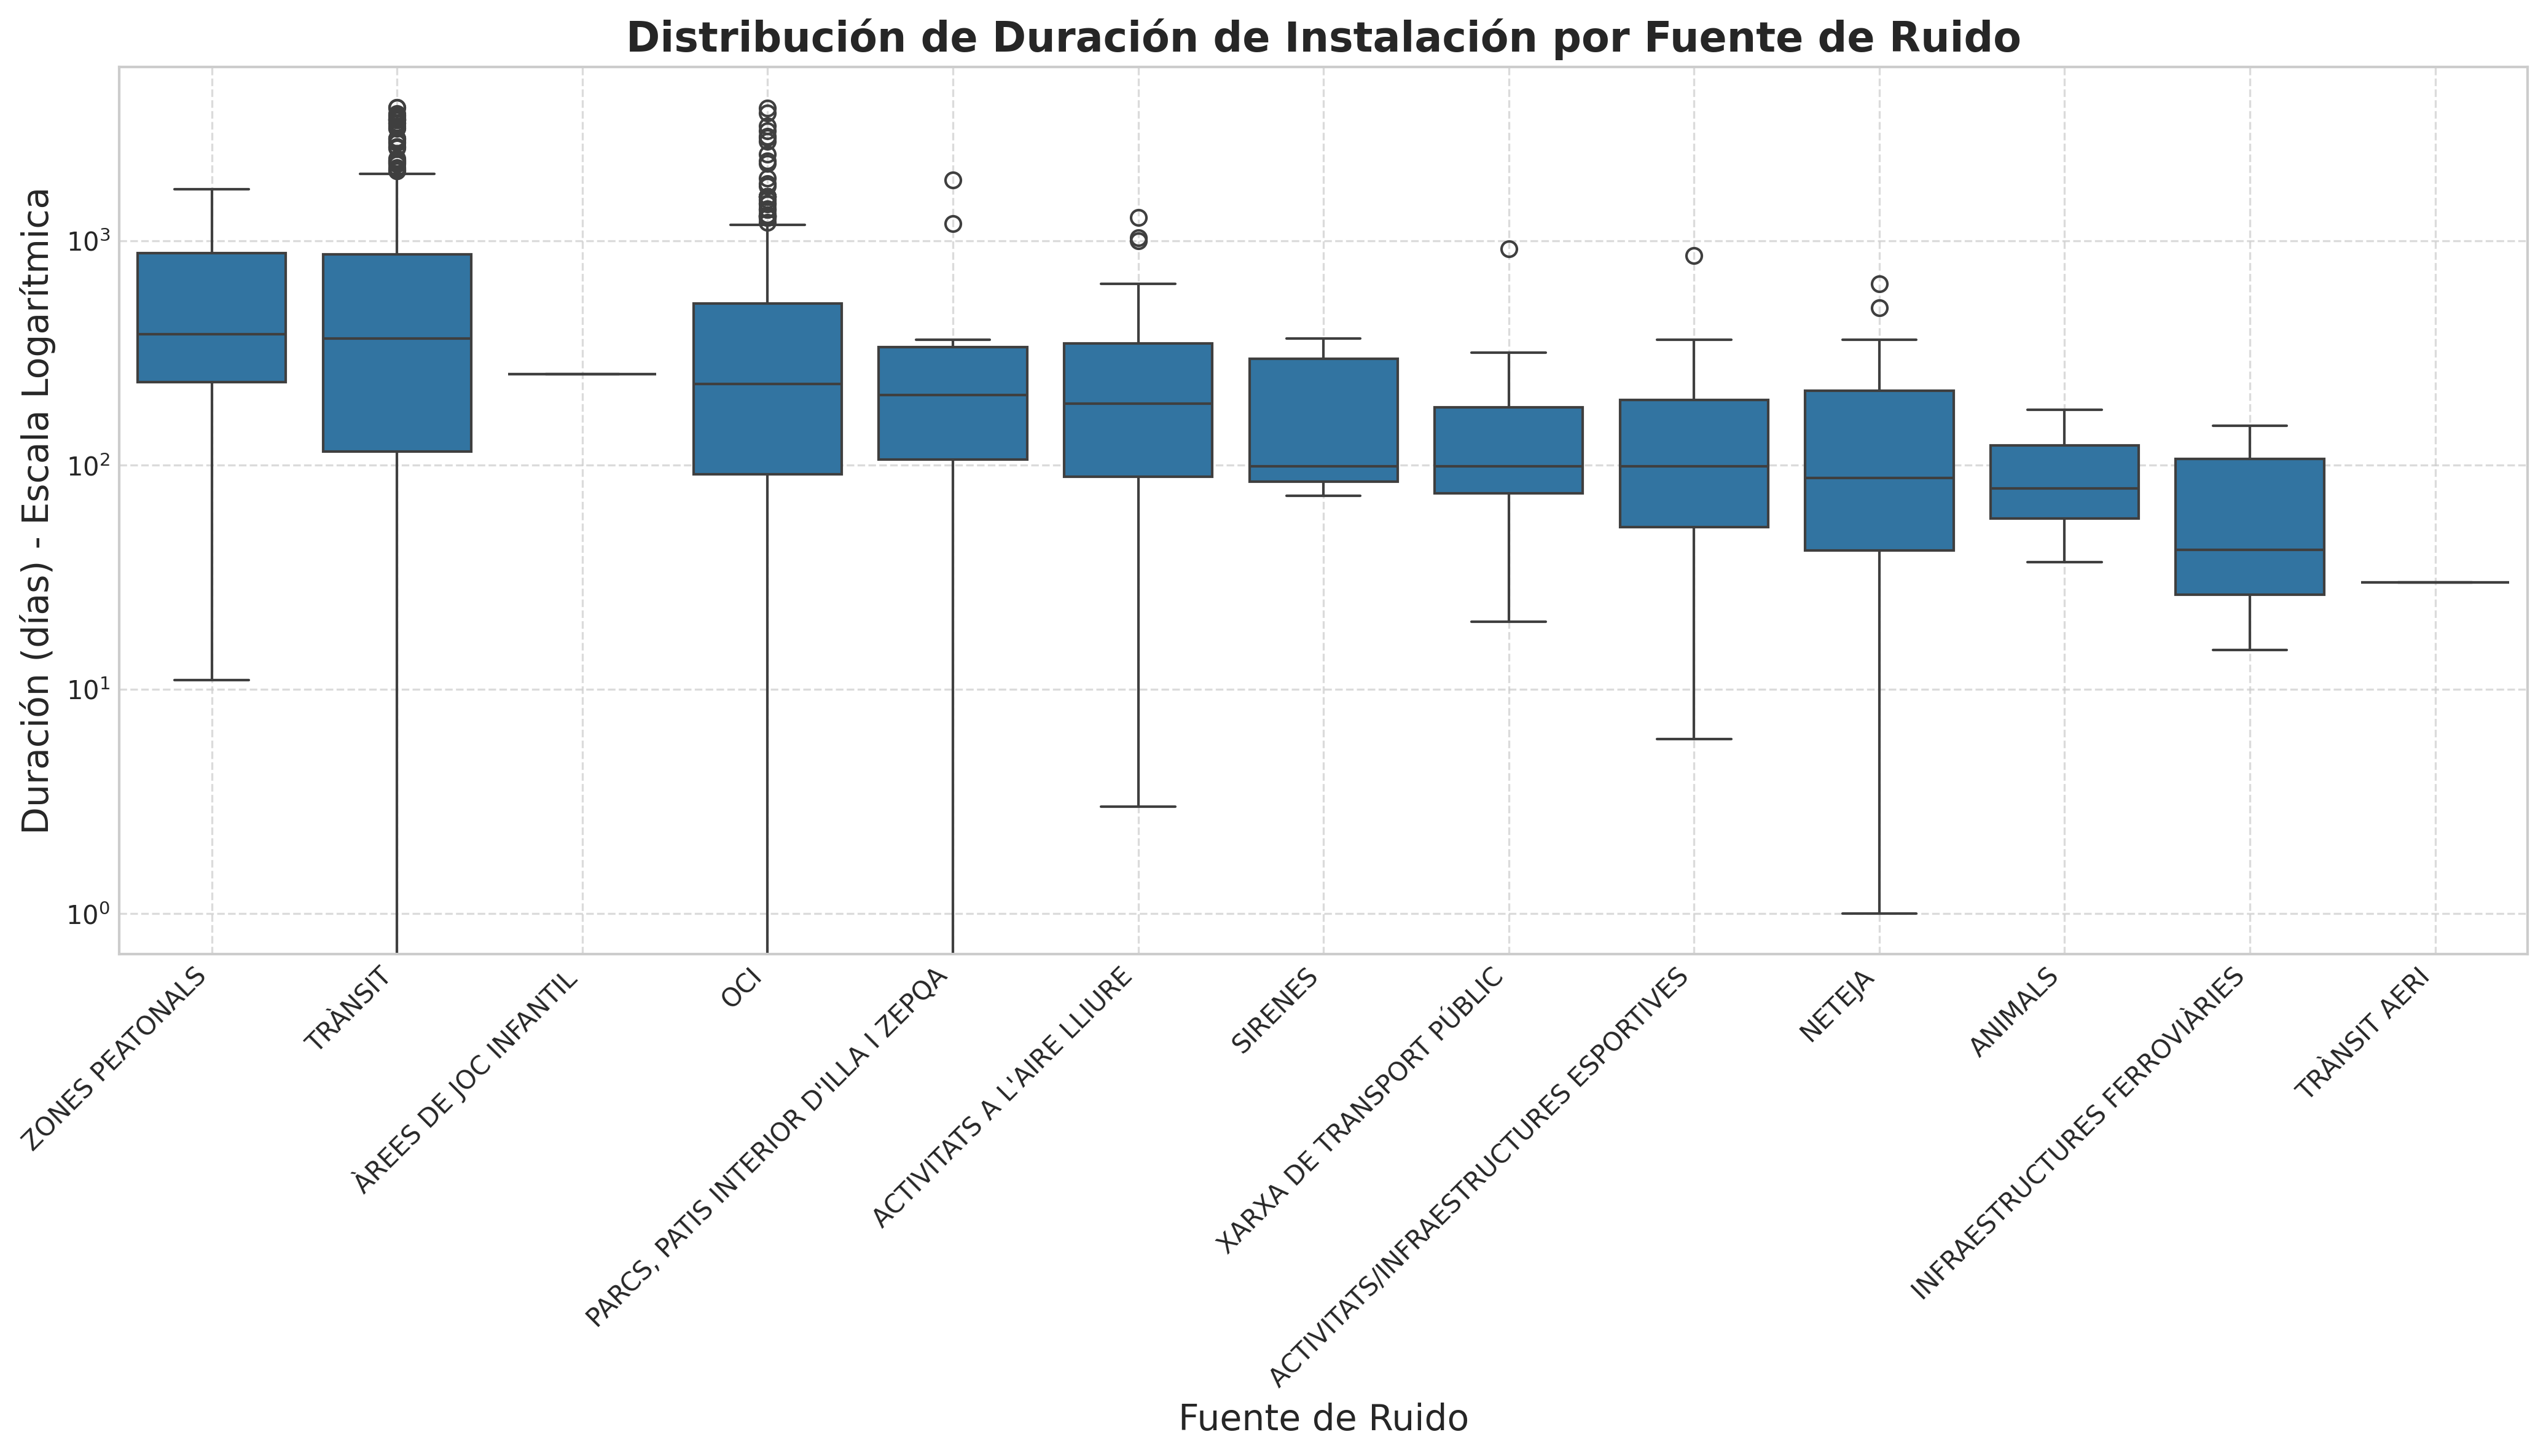


📋 RESUMEN ANALÍTICO DE LOS SENSORES DE RUIDO

📍 Total de sensores registrados: 978
🟢 Sensores actualmente activos: 184 (18.8%)

🛣️  Top 5 tipos de vía con más sensores:
   2. Rbla: 19 sensores (1.9%)
   3. Av: 50 sensores (5.1%)
   4. Pg: 93 sensores (9.5%)
   5. Pl: 136 sensores (13.9%)
   6. C: 603 sensores (61.7%)

🔊 Top 5 fuentes de ruido monitoreadas:
   2. NETEJA: 20 sensores (2.0%)
   3. ACTIVITATS/INFRAESTRUCTURES ESPORTIVES: 21 sensores (2.1%)
   4. ACTIVITATS A L'AIRE LLIURE: 29 sensores (3.0%)
   5. TRÀNSIT: 342 sensores (35.0%)
   6. OCI: 482 sensores (49.3%)

🏘️  Top 5 distritos con más sensores:
   2. Sant Martí: 116 sensores (11.9%)
   3. Sants-Montjuïc: 124 sensores (12.7%)
   4. Gràcia: 127 sensores (13.0%)
   5. Eixample: 177 sensores (18.1%)
   6. Ciutat Vella: 180 sensores (18.4%)

⏱️  Duración promedio de instalación: 1.4 años

🌍 Generando mapa interactivo de sensores...
✅ Mapa interactivo guardado en: /content/drive/MyDrive/MAIN FINAL RPOYECT/mapa_sensores_intera

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib as mpl

# --- CONFIGURACIÓN DE ESTILO ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('default')

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']

# --- 1. CARGAR Y PREPARAR DATOS ---
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'
archivo_sensores = os.path.join(base_path, 'XarxaSoroll_EquipsMonitor_Instal.csv')

if not os.path.exists(archivo_sensores):
    print(f"❌ Error: El archivo no se encuentra en {archivo_sensores}")
    print("\n🔍 Archivos disponibles en el directorio:")
    for file in os.listdir(base_path):
        if file.endswith('.csv') or file.endswith('.png') or file.endswith('.html'):
            print(f"  - {file}")
else:
    print("✅ Archivo de sensores encontrado. Cargando datos...")
    sensor_locations = pd.read_csv(archivo_sensores)

    # --- 2. CONVERTIR FECHAS CORRECTAMENTE ---
    print("\n🔄 Convirtiendo fechas correctamente (formato día/mes/año)...")

    # Usar dayfirst=True para formato europeo (día/mes/año)
    sensor_locations['Data_Instalacio'] = pd.to_datetime(sensor_locations['Data_Instalacio'], dayfirst=True, errors='coerce')
    sensor_locations['Data_DesInstalacio'] = pd.to_datetime(sensor_locations['Data_DesInstalacio'], dayfirst=True, errors='coerce')

    # Crear columna de año de instalación
    sensor_locations['Año_Instalacion'] = sensor_locations['Data_Instalacio'].dt.year
    sensor_locations['Mes_Instalacion'] = sensor_locations['Data_Instalacio'].dt.month

    # Calcular duración de instalación
    sensor_locations['Duracion_dias'] = (sensor_locations['Data_DesInstalacio'] - sensor_locations['Data_Instalacio']).dt.days
    sensor_locations['Duracion_dias'] = sensor_locations['Duracion_dias'].fillna((pd.Timestamp.now() - sensor_locations['Data_Instalacio']).dt.days)

    print("✅ Fechas convertidas correctamente")

    # --- 3. LIMPIEZA DE DATOS ---
    print("\n🧹 Limpiando y preparando datos...")
    for col in ['Tipus_Via', 'Font', 'Nom_Districte', 'Nom_Barri']:
        if col in sensor_locations.columns:
            sensor_locations[col] = sensor_locations[col].str.strip()

    # --- 4. ANÁLISIS TEMPORAL DE INSTALACIONES ---
    print("\n📊 Analizando evolución temporal de instalaciones...")
    instalaciones_por_año = sensor_locations['Año_Instalacion'].value_counts().sort_index()

    plt.figure(figsize=(14, 7))
    sns.lineplot(x=instalaciones_por_año.index, y=instalaciones_por_año.values,
                 marker='o', linewidth=2.5, color='#1f77b4', markersize=10)
    plt.fill_between(instalaciones_por_año.index, instalaciones_por_año.values, alpha=0.2)

    plt.title('Evolución de Instalaciones de Sensores de Ruido (2007-2025)', fontsize=16, fontweight='bold')
    plt.xlabel('Año', fontsize=14)
    plt.ylabel('Número de Nuevas Instalaciones', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(instalaciones_por_año.index, rotation=45)

    # Añadir etiquetas de valores
    for i, v in enumerate(instalaciones_por_año.values):
        plt.text(instalaciones_por_año.index[i], v + 1, str(int(v)), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()

    # Guardar gráfico
    output_path_temporal = os.path.join(base_path, 'evolucion_instalaciones_temporal.png')
    plt.savefig(output_path_temporal, bbox_inches='tight', dpi=300)
    print(f"✅ Gráfico temporal guardado en: {output_path_temporal}")
    plt.show()

    # --- 5. GRÁFICO DE DISTRIBUCIÓN POR TIPO DE VÍA ---
    print("\n📊 Analizando distribución por tipo de vía...")
    via_counts = sensor_locations['Tipus_Via'].value_counts().reset_index()
    via_counts.columns = ['Tipus_Via', 'Conteo']
    via_counts = via_counts.sort_values('Conteo', ascending=True)  # Para barras horizontales

    plt.figure(figsize=(14, 10))
    bars = plt.barh(via_counts['Tipus_Via'], via_counts['Conteo'], color=plt.cm.Blues(np.linspace(0.4, 1, len(via_counts))))

    plt.title('Distribución de Sensores por Tipo de Vía', fontsize=16, fontweight='bold')
    plt.xlabel('Número de Sensores', fontsize=14)
    plt.ylabel('Tipo de Vía', fontsize=14)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Añadir valores en las barras
    for i, v in enumerate(via_counts['Conteo']):
        plt.text(v + 1, i, str(v), va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Guardar gráfico
    output_path_via = os.path.join(base_path, 'distribucion_tipo_via.png')
    plt.savefig(output_path_via, bbox_inches='tight', dpi=300)
    print(f"✅ Gráfico por tipo de vía guardado en: {output_path_via}")
    plt.show()

    # --- 6. GRÁFICO DE DISTRIBUCIÓN POR FUENTE DE RUIDO ---
    print("\n📊 Analizando distribución por fuente de ruido...")
    font_counts = sensor_locations['Font'].value_counts().reset_index()
    font_counts.columns = ['Fuente', 'Conteo']
    font_counts = font_counts.sort_values('Conteo', ascending=True)

    plt.figure(figsize=(14, 10))
    bars = plt.barh(font_counts['Fuente'], font_counts['Conteo'], color=plt.cm.Reds(np.linspace(0.4, 1, len(font_counts))))

    plt.title('Distribución de Sensores por Fuente de Ruido', fontsize=16, fontweight='bold')
    plt.xlabel('Número de Sensores', fontsize=14)
    plt.ylabel('Fuente de Ruido', fontsize=14)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Añadir valores en las barras
    for i, v in enumerate(font_counts['Conteo']):
        plt.text(v + 1, i, str(v), va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Guardar gráfico
    output_path_fuente = os.path.join(base_path, 'distribucion_fuente_ruido.png')
    plt.savefig(output_path_fuente, bbox_inches='tight', dpi=300)
    print(f"✅ Gráfico por fuente de ruido guardado en: {output_path_fuente}")
    plt.show()

    # --- 7. GRÁFICO DE DISTRIBUCIÓN POR DISTRITO ---
    print("\n📊 Analizando distribución por distrito...")
    distrito_counts = sensor_locations['Nom_Districte'].value_counts().reset_index()
    distrito_counts.columns = ['Distrito', 'Conteo']
    distrito_counts = distrito_counts.sort_values('Conteo', ascending=True)

    plt.figure(figsize=(14, 12))
    bars = plt.barh(distrito_counts['Distrito'], distrito_counts['Conteo'], color=plt.cm.Greens(np.linspace(0.4, 1, len(distrito_counts))))

    plt.title('Distribución de Sensores por Distrito de Barcelona', fontsize=16, fontweight='bold')
    plt.xlabel('Número de Sensores', fontsize=14)
    plt.ylabel('Distrito', fontsize=14)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Añadir valores en las barras
    for i, v in enumerate(distrito_counts['Conteo']):
        plt.text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Guardar gráfico
    output_path_distrito = os.path.join(base_path, 'distribucion_distritos.png')
    plt.savefig(output_path_distrito, bbox_inches='tight', dpi=300)
    print(f"✅ Gráfico por distrito guardado en: {output_path_distrito}")
    plt.show()

    # --- 8. ANÁLISIS DE DURACIÓN DE INSTALACIÓN ---
    print("\n📊 Analizando duración de instalaciones...")
    plt.figure(figsize=(14, 8))

    # Boxplot de duración por tipo de fuente
    sns.boxplot(data=sensor_locations,
                x='Font',
                y='Duracion_dias',
                order=sensor_locations.groupby('Font')['Duracion_dias'].median().sort_values(ascending=False).index)

    plt.yscale('log')  # Escala logarítmica para mejor visualización
    plt.title('Distribución de Duración de Instalación por Fuente de Ruido', fontsize=16, fontweight='bold')
    plt.xlabel('Fuente de Ruido', fontsize=14)
    plt.ylabel('Duración (días) - Escala Logarítmica', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()

    # Guardar gráfico
    output_path_duracion = os.path.join(base_path, 'duracion_instalaciones.png')
    plt.savefig(output_path_duracion, bbox_inches='tight', dpi=300)
    print(f"✅ Gráfico de duración guardado en: {output_path_duracion}")
    plt.show()

    # --- 9. RESUMEN ANALÍTICO ---
    print("\n" + "="*70)
    print("📋 RESUMEN ANALÍTICO DE LOS SENSORES DE RUIDO")
    print("="*70)

    total_sensores = len(sensor_locations)
    sensores_activos = sensor_locations[sensor_locations['Data_DesInstalacio'].isna() |
                                        (sensor_locations['Data_DesInstalacio'] > pd.Timestamp.now())].shape[0]

    print(f"\n📍 Total de sensores registrados: {total_sensores:,}")
    print(f"🟢 Sensores actualmente activos: {sensores_activos:,} ({sensores_activos/total_sensores:.1%})")

    # Top 5 tipos de vía
    top_vias = via_counts.tail(5)
    print("\n🛣️  Top 5 tipos de vía con más sensores:")
    for i, row in top_vias.iterrows():
        porcentaje = row['Conteo'] / total_sensores * 100
        print(f"   {6-i}. {row['Tipus_Via']}: {row['Conteo']:,} sensores ({porcentaje:.1f}%)")

    # Top 5 fuentes de ruido
    top_fuentes = font_counts.tail(5)
    print("\n🔊 Top 5 fuentes de ruido monitoreadas:")
    for i, row in top_fuentes.iterrows():
        porcentaje = row['Conteo'] / total_sensores * 100
        print(f"   {6-i}. {row['Fuente']}: {row['Conteo']:,} sensores ({porcentaje:.1f}%)")

    # Top 5 distritos
    top_distritos = distrito_counts.tail(5)
    print("\n🏘️  Top 5 distritos con más sensores:")
    for i, row in top_distritos.iterrows():
        porcentaje = row['Conteo'] / total_sensores * 100
        print(f"   {6-i}. {row['Distrito']}: {row['Conteo']:,} sensores ({porcentaje:.1f}%)")

    # Duración promedio
    duracion_promedio = sensor_locations['Duracion_dias'].mean()
    print(f"\n⏱️  Duración promedio de instalación: {duracion_promedio/365:.1f} años")

    # --- 10. MAPA INTERACTIVO ---
    print("\n🌍 Generando mapa interactivo de sensores...")

    # Crear mapa base centrado en Barcelona
    m = folium.Map(location=[41.3851, 2.1734], zoom_start=12, tiles='cartodbpositron')

    # Preparar datos para heatmap (eliminar NaN)
    heat_data = sensor_locations[['Latitud', 'Longitud']].dropna().values.tolist()

    # Añadir heatmap
    if len(heat_data) > 0:
        HeatMap(heat_data, radius=15, blur=10, max_zoom=1).add_to(m)

    # Añadir marcadores para sensores activos
    sensores_activos_df = sensor_locations[sensor_locations['Data_DesInstalacio'].isna() |
                                          (sensor_locations['Data_DesInstalacio'] > pd.Timestamp.now())]

    # Colores por tipo de fuente
    colores_fuente = {
        'TRÀNSIT': 'red',
        'OCI': 'blue',
        'XARXA DE TRANSPORT PÚBLIC': 'green',
        'INFRAESTRUCTURES FERROVIÀRIES': 'purple',
        'ACTIVITATS/INFRAESTRUCTURES ESPORTIVES': 'orange',
        'ACTIVITATS A L\'AIRE LLIURE': 'darkblue',
        'NETEJA': 'brown',
        'ANIMALS': 'pink',
        'PARCS, PATIS INTERIOR D\'ILLA I ZEPQA': 'lightgreen',
        'SIRENES': 'gray',
        'ZONES PEATONALS': 'lightblue'
    }

    for idx, row in sensores_activos_df.iterrows():
        if pd.notna(row['Latitud']) and pd.notna(row['Longitud']):
            color = colores_fuente.get(row['Font'], 'gray')

            popup_content = f"""
            <b>📍 Ubicación:</b> {row['Nom_Carrer']} {row.get('Num_Carrer', '')}<br>
            <b>🏘️ Distrito:</b> {row['Nom_Districte']}<br>
            <b>🏠 Barrio:</b> {row['Nom_Barri']}<br>
            <b>🔊 Fuente:</b> {row['Font']}<br>
            <b>📅 Instalado:</b> {row['Data_Instalacio'].strftime('%d/%m/%Y')}<br>
            <b>⏱️ Duración:</b> {row['Duracion_dias']//365} años
            """

            folium.CircleMarker(
                location=[row['Latitud'], row['Longitud']],
                radius=6,
                popup=folium.Popup(popup_content, max_width=300),
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                tooltip=f"{row['Nom_Carrer']} - {row['Font']}"
            ).add_to(m)

    # Añadir leyenda
    legend_html = '''
    <div style="position: fixed;
                bottom: 50px; left: 50px; width: 200px; height: 300px;
                background-color: white; border:2px solid grey; z-index:9999;
                font-size:14px; padding: 10px;
                ">
        <p><b>LEYENDA - Fuentes de Ruido</b></p>
        <i style="background:red; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Tráfico<br>
        <i style="background:blue; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Ocio<br>
        <i style="background:green; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Transporte Público<br>
        <i style="background:purple; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Ferroviario<br>
        <i style="background:orange; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Deportes<br>
        <i style="background:darkblue; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Aire Libre<br>
        <i style="background:brown; width:20px; height:20px; display:inline-block; margin-right:5px;"></i> Limpieza<br>
    </div>
    '''

    m.get_root().html.add_child(folium.Element(legend_html))

    # Guardar mapa
    map_path = os.path.join(base_path, 'mapa_sensores_interactivo.html')
    m.save(map_path)
    print(f"✅ Mapa interactivo guardado en: {map_path}")
    print("💡 Para ver el mapa, abre el archivo HTML desde tu Google Drive")

    print("\n🎉 ¡ANÁLISIS COMPLETADO CON ÉXITO!")
    print("📊 Se han generado 5 visualizaciones clave:")
    print("   1. Evolución temporal de instalaciones")
    print("   2. Distribución por tipo de vía")
    print("   3. Distribución por fuente de ruido")
    print("   4. Distribución por distrito")
    print("   5. Duración de instalaciones")
    print("   6. Mapa interactivo con todos los sensores")

# Importing Data Climatic

In [ ]:
import pandas as pd
import os

# 1. Definimos la ruta que ya comprobamos que funciona
path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/METEOCAT/'

# 2. Listamos los archivos y filtramos solo los de datos (2022-2025)
todos_los_archivos = os.listdir(path)
archivos_csv = [f for f in todos_los_archivos if 'Detall_Estacions.csv' in f]

print(f"Archivos encontrados para unir: {archivos_csv}")

# 3. Cargamos y concatenamos
lista_df = []
for nombre_archivo in archivos_csv:
    ruta_completa = os.path.join(path, nombre_archivo)
    # Usamos sep=None para que detecte si es coma o punto y coma
    df_temp = pd.read_csv(ruta_completa, sep=None, engine='python')
    lista_df.append(df_temp)

df_clima = pd.concat(lista_df, ignore_index=True)

# 4. Cargamos los metadatos (el archivo que NO termina en Detall_Estacions)
df_meta = pd.read_csv(os.path.join(path, 'MeteoCat_Metadades.csv'), sep=None, engine='python')

# 5. Convertir la fecha para poder analizar el clima de Barcelona
df_clima['DATA_LECTURA'] = pd.to_datetime(df_clima['DATA_LECTURA'])

print(f"✅ ¡Hecho! Tienes {len(df_clima)} filas de datos climáticos cargadas.")
display(df_clima.head())

Archivos encontrados para unir: ['2025_MeteoCat_Detall_Estacions.csv', '2024_MeteoCat_Detall_Estacions.csv', '2023_MeteoCat_Detall_Estacions.csv', '2022_MeteoCat_Detall_Estacions.csv']
✅ ¡Hecho! Tienes 71395 filas de datos climáticos cargadas.


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,DATA_LECTURA,DATA_EXTREM,CODI_ESTACIO,ACRÒNIM,VALOR
0,2025-01-01,NaN,D5,TM,8.8
1,2025-01-01,12:15:00,D5,TX,13.3
2,2025-01-01,07:25:00,D5,TN,7.1
3,2025-01-01,NaN,D5,HRM,85.0
4,2025-01-01,07:44:00,D5,HRX,95.0


In [ ]:
print("Variables disponibles en tus datos:")
print(df_clima['ACRÒNIM'].unique())

Variables disponibles en tus datos:
['TM' 'TX' 'TN' 'HRM' 'HRX' 'HRN' 'PM' 'PX' 'PN' 'PPT' 'RS24h' 'VVM10'
 'DVM10' 'VVX10' 'DVVX10']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_tm = df_clima[df_clima['ACRÒNIM'] == 'TM']

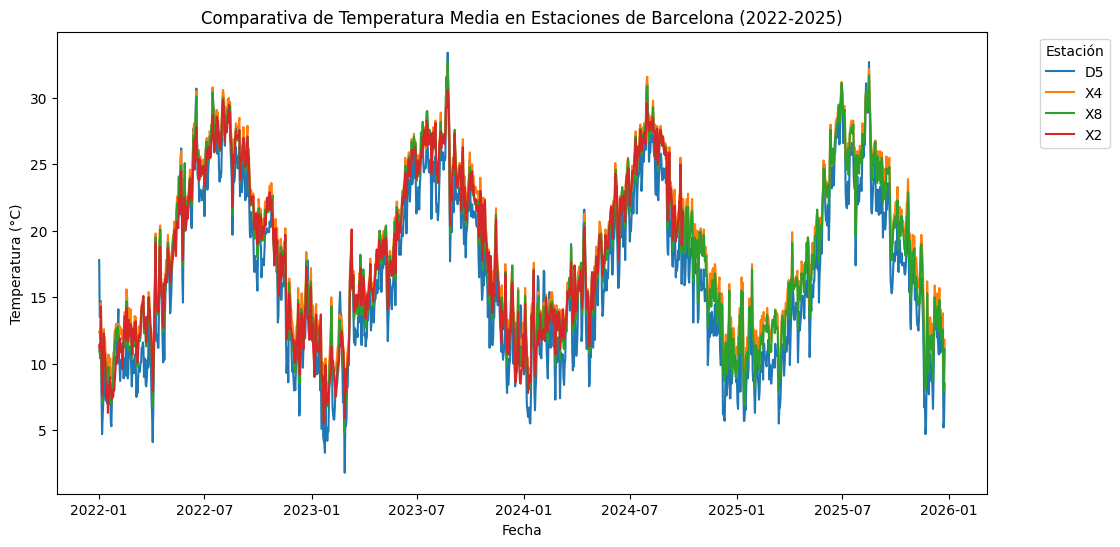

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_tm, x='DATA_LECTURA', y='VALOR', hue='CODI_ESTACIO')
plt.title('Comparativa de Temperatura Media en Estaciones de Barcelona (2022-2025)')
plt.ylabel('Temperatura (°C)')
plt.xlabel('Fecha')
plt.legend(title='Estación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df_maximas = df_clima[df_clima['ACRÒNIM'] == 'TX']

In [ ]:
record_calor = df_maximas.loc[df_maximas['VALOR'].idxmax()]

In [ ]:
nombre_estacion = record_calor['CODI_ESTACIO']

In [ ]:
print(f"🔥 RÉCORD DE CALOR EN BARCELONA (2022-2025) 🔥")
print(f"-------------------------------------------")
print(f"Temperatura: {record_calor['VALOR']} °C")
print(f"Fecha: {record_calor['DATA_LECTURA'].strftime('%d de %B de %Y')}")
print(f"Estación (Código): {nombre_estacion}")

🔥 RÉCORD DE CALOR EN BARCELONA (2022-2025) 🔥
-------------------------------------------
Temperatura: 39.5 °C
Fecha: 30 de July de 2024
Estación (Código): D5


In [ ]:
olas_calor = df_maximas[df_maximas['VALOR'] > 35]

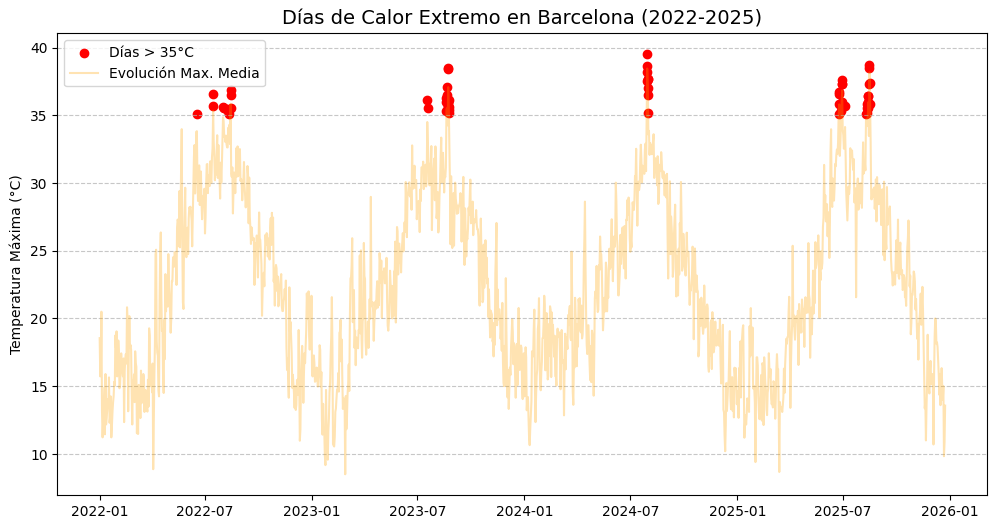

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(olas_calor['DATA_LECTURA'], olas_calor['VALOR'], color='red', label='Días > 35°C')
plt.plot(df_maximas.groupby('DATA_LECTURA')['VALOR'].mean().index,
         df_maximas.groupby('DATA_LECTURA')['VALOR'].mean().values,
         color='orange', alpha=0.3, label='Evolución Max. Media')

plt.title('Días de Calor Extremo en Barcelona (2022-2025)', fontsize=14)
plt.ylabel('Temperatura Máxima (°C)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#2025_MeteoCat_Detall_Estacions

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path_2025 = '/content/drive/MyDrive/MAIN FINAL RPOYECT/METEOCAT/2025_MeteoCat_Detall_Estacions.csv'
path_meta = '/content/drive/MyDrive/MAIN FINAL RPOYECT/METEOCAT/MeteoCat_Metadades.csv'

In [ ]:
df_2025 = pd.read_csv(path_2025, sep=None, engine='python')
df_meta = pd.read_csv(path_meta, sep=None, engine='python')

In [ ]:
df_2025['DATA_LECTURA'] = pd.to_datetime(df_2025['DATA_LECTURA'])

print(f"✅ Analizando datos del 1 al 5 de enero de 2025.")
print(f"Total de registros: {len(df_2025)}")

✅ Analizando datos del 1 al 5 de enero de 2025.
Total de registros: 16081


# ANÁLISIS DE TEMPERATURAS EN 2025

In [ ]:
df_temp_2025 = df_2025[df_2025['ACRÒNIM'].isin(['TX', 'TN', 'TM'])]

In [ ]:
max_2025 = df_2025[df_2025['ACRÒNIM'] == 'TX']['VALOR'].max()
min_2025 = df_2025[df_2025['ACRÒNIM'] == 'TN']['VALOR'].min()

print(f"\n🌡️ Extremos térmicos en Barcelona (Enero 2025):")
print(f"- Temperatura más alta: {max_2025} °C")
print(f"- Temperatura más baja: {min_2025} °C")


🌡️ Extremos térmicos en Barcelona (Enero 2025):
- Temperatura más alta: 38.7 °C
- Temperatura más baja: 1.3 °C


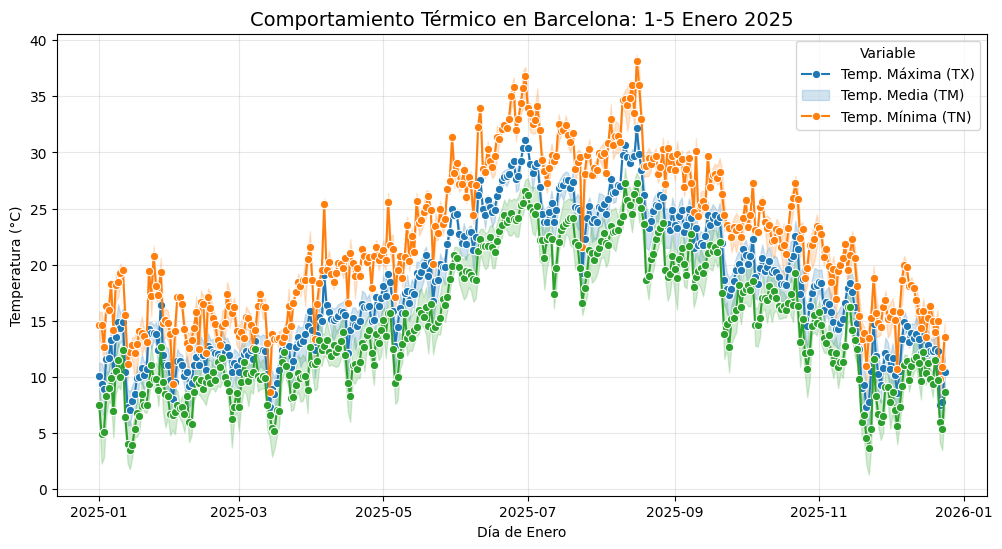

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temp_2025, x='DATA_LECTURA', y='VALOR', hue='ACRÒNIM', marker='o')

plt.title('Comportamiento Térmico en Barcelona: 1-5 Enero 2025', fontsize=14)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Día de Enero')
plt.grid(True, alpha=0.3)
plt.legend(title='Variable', labels=['Temp. Máxima (TX)', 'Temp. Media (TM)', 'Temp. Mínima (TN)'])
plt.show()

In [ ]:
path_2025 = '/content/drive/MyDrive/MAIN FINAL RPOYECT/METEOCAT/2025_MeteoCat_Detall_Estacions.csv'

In [ ]:
df_2025 = pd.read_csv(path_2025)
df_2025['DATA_LECTURA'] = pd.to_datetime(df_2025['DATA_LECTURA'])

In [ ]:
df_2025['Mes_Num'] = df_2025['DATA_LECTURA'].dt.month
df_2025['Mes_Nombre'] = df_2025['DATA_LECTURA'].dt.month_name()

In [ ]:
df_temp = df_2025[df_2025['ACRÒNIM'].isin(['TM', 'TX', 'TN'])]
resumen_mensual = df_temp.groupby(['Mes_Num', 'Mes_Nombre', 'ACRÒNIM'])['VALOR'].mean().reset_index()

In [ ]:
resumen_mensual = resumen_mensual.sort_values('Mes_Num')

<Axes: xlabel='Mes_Nombre', ylabel='VALOR'>

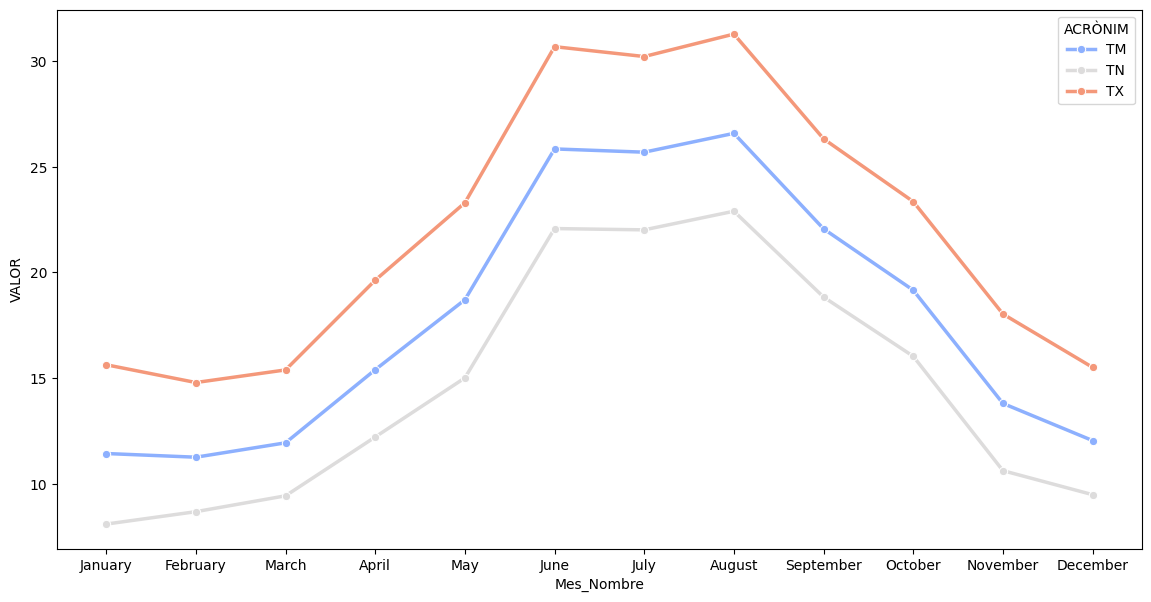

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=resumen_mensual, x='Mes_Nombre', y='VALOR', hue='ACRÒNIM',
             marker='o', palette='coolwarm', linewidth=2.5)

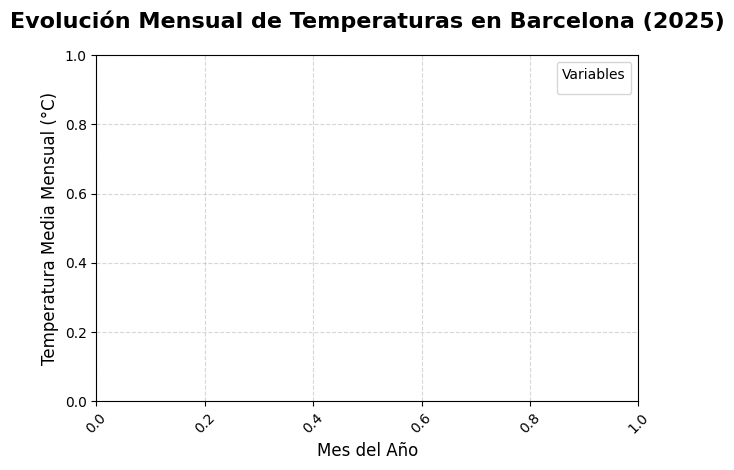


📊 Tabla resumen de promedios mensuales:


ACRÒNIM,TM,TN,TX
Mes_Nombre,,,
January,11.429032,8.090323,15.629032
February,11.254762,8.677381,14.788095
March,11.935484,9.427957,15.384946
April,15.394444,12.211111,19.630000
May,18.705376,15.007527,23.293548
June,25.841111,22.073333,30.680000
July,25.687097,22.011828,30.212903
August,26.578495,22.893548,31.275269
September,22.060674,18.833333,26.318889


In [ ]:
plt.title('Evolución Mensual de Temperaturas en Barcelona (2025)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Temperatura Media Mensual (°C)', fontsize=12)
plt.xlabel('Mes del Año', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Variables', labels=['Temperatura Media (TM)', 'Temp. Mínima (TN)', 'Temp. Máxima (TX)'],
           loc='upper right', frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n📊 Tabla resumen de promedios mensuales:")
tabla_resumen = resumen_mensual.pivot(index='Mes_Nombre', columns='ACRÒNIM', values='VALOR').reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)
display(tabla_resumen.dropna())

# 1. Filtrar Precipitación (PPT) y sumar por mes

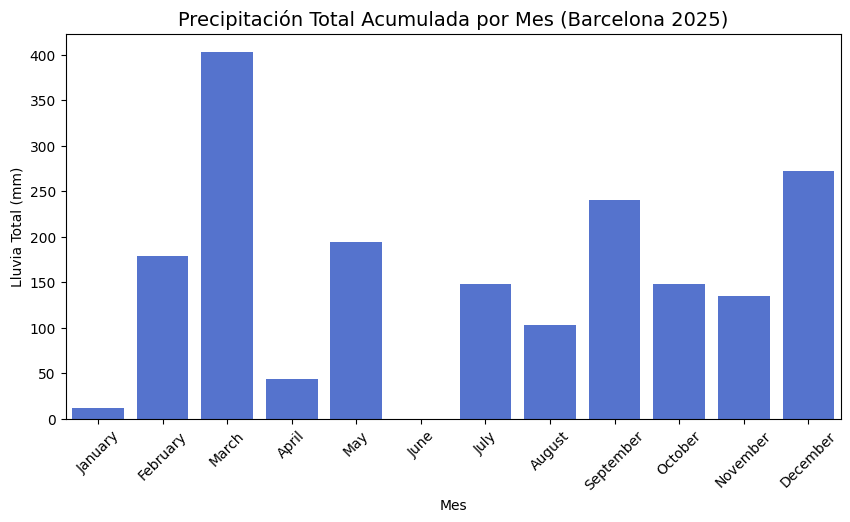

In [ ]:
# 1. Filtrar Precipitación (PPT) y sumar por mes
df_ppt = df_2025[df_2025['ACRÒNIM'] == 'PPT']
# Agrupamos por mes y sumamos
lluvia_mensual = df_ppt.groupby(df_2025['DATA_LECTURA'].dt.month_name())['VALOR'].sum().reset_index()

# Ordenar los meses correctamente
meses_orden = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
lluvia_mensual['DATA_LECTURA'] = pd.Categorical(lluvia_mensual['DATA_LECTURA'], categories=meses_orden, ordered=True)
lluvia_mensual = lluvia_mensual.sort_values('DATA_LECTURA')

plt.figure(figsize=(10, 5))
sns.barplot(data=lluvia_mensual, x='DATA_LECTURA', y='VALOR', color='royalblue')
plt.title('Precipitación Total Acumulada por Mes (Barcelona 2025)', fontsize=14)
plt.ylabel('Lluvia Total (mm)')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.show()

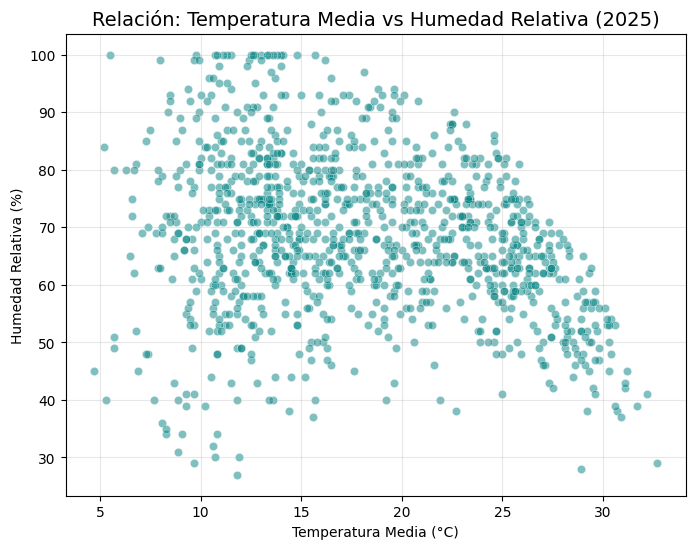

In [ ]:
# Pivotamos los datos para tener TM (Temperatura) y HRM (Humedad) en columnas
df_pivot = df_2025.pivot_table(index=['DATA_LECTURA', 'CODI_ESTACIO'],
                               columns='ACRÒNIM', values='VALOR').reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pivot, x='TM', y='HRM', alpha=0.5, color='teal')
plt.title('Relación: Temperatura Media vs Humedad Relativa (2025)', fontsize=14)
plt.xlabel('Temperatura Media (°C)')
plt.ylabel('Humedad Relativa (%)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipython-input-2789419791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rs, x='CODI_ESTACIO', y='VALOR', palette='Set2')


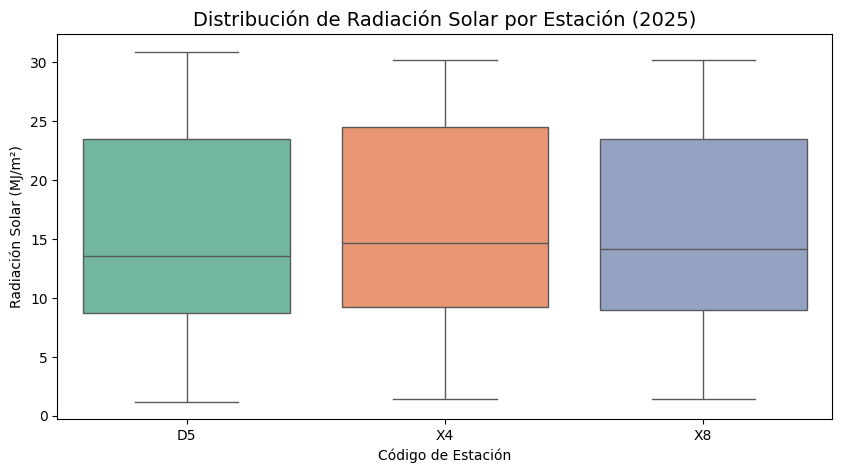

In [ ]:
# Filtrar Radiación Solar (RS24h)
df_rs = df_2025[df_2025['ACRÒNIM'] == 'RS24h']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_rs, x='CODI_ESTACIO', y='VALOR', palette='Set2')
plt.title('Distribución de Radiación Solar por Estación (2025)', fontsize=14)
plt.ylabel('Radiación Solar (MJ/m²)')
plt.xlabel('Código de Estación')
plt.show()

### Integración de Datos de Ruido y Climáticos

Para entender la relación entre el ruido y las condiciones climáticas, vamos a unir los dos datasets principales:

1.  **`final_df` (Datos de Ruido):** Contiene niveles de ruido cada minuto.
2.  **`df_clima` (Datos Climáticos):** Contiene mediciones diarias de variables como temperatura, humedad y precipitación.

Dado que los datos climáticos son diarios, agregaremos los datos de ruido a un nivel diario (promedio) para que puedan combinarse. También promediaremos las variables climáticas por día, ya que `df_clima` puede tener múltiples estaciones por día.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import os

# Define the path for the processed data file
parquet_file_path = "/content/drive/MyDrive/MAIN FINAL RPOYECT/processed_sensor_data.parquet"
base_path = '/content/drive/MyDrive/MAIN FINAL RPOYECT/'

# Check if the processed parquet file exists
if not os.path.exists(parquet_file_path):
    print("⚠️ Processed sensor data parquet file not found. Re-generating...")

    # --- Re-load and process raw data to create final_df if necessary ---
    archivos_mensuales = [
        "2025_01Gen_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_02Feb_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_03Mar_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_04Abr_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_05Mai_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_06Jun_XarxaSoroll_EqMonitor_Dades_1Min.csv",
        "2025_07Jul_XarxaSoroll_EqMonitor_Dades_1Min.csv"
    ]
    lista_dataframes = []
    for nombre in archivos_mensuales:
        ruta_completa = os.path.join(base_path, nombre)
        if os.path.exists(ruta_completa):
            try:
                df_temp = pd.read_csv(ruta_completa)
                df_temp['origen_mes'] = nombre.split('_')[1]
                lista_dataframes.append(df_temp)
            except Exception as e:
                print(f"⚠️ Error al leer {nombre}: {e}")
        else:
            print(f"❌ {nombre}: No se encontró en la ruta especificada.") # Added for better debugging

    if lista_dataframes:
        df_total = pd.concat(lista_dataframes, ignore_index=True)
        print("✅ Raw monthly data loaded and concatenated.")
    else:
        raise FileNotFoundError("🚨 CRITICAL ERROR: Could not load any monthly data files to create df_total.")

    df = df_total.copy() # Assign df from df_total

    # Perform datetime transformations
    df['hour_clean'] = df['Hora'].astype(str).str.split(':').str[0].astype(int)
    df['minute_clean'] = df['Hora'].astype(str).str.split(':').str[1].fillna(0).astype(int)
    temp_dates = pd.DataFrame({
        'year': df['Any'],
        'month': df['Mes'],
        'day': df['Dia'],
        'hour': df['hour_clean'],
        'minute': df['minute_clean']
    })
    df['timestamp'] = pd.to_datetime(temp_dates)
    df['timestamp_local'] = df['timestamp'].dt.tz_localize(
        'Europe/Madrid',
        ambiguous='NaT',
        nonexistent='shift_forward'
    )
    df['timestamp_utc'] = df['timestamp_local'].dt.tz_convert('UTC')
    df['Day_of_Week'] = df['timestamp_local'].dt.day_name()
    df['Day_of_Month'] = df['timestamp_local'].dt.day
    df['Hour_of_Day'] = df['timestamp_local'].dt.hour
    final_df = df[[
        'timestamp_utc',
        'Day_of_Week',
        'Day_of_Month',
        'Hour_of_Day',
        'Nivell_LAeq_1min'
    ]].set_index('timestamp_utc')
    print("✅ final_df created with datetime transformations.")

    final_df.to_parquet(parquet_file_path)
    print(f"✅ final_df saved to {parquet_file_path}")

# Ensure df is loaded from the processed data file
df = pd.read_parquet(parquet_file_path)
print("✅ Processed sensor data loaded from parquet.")

# --- Load df_clima (climate data) ---
path_clima = '/content/drive/MyDrive/MAIN FINAL RPOYECT/METEOCAT/'
todos_los_archivos_clima = os.listdir(path_clima)
archivos_csv_clima = [f for f in todos_los_archivos_clima if 'Detall_Estacions.csv' in f]

lista_df_clima = []
for nombre_archivo_clima in archivos_csv_clima:
    ruta_completa_clima = os.path.join(path_clima, nombre_archivo_clima)
    try:
        df_temp_clima = pd.read_csv(ruta_completa_clima, sep=None, engine='python')
        lista_df_clima.append(df_temp_clima)
    except Exception as e:
        print(f"⚠️ Error al leer archivo climático {nombre_archivo_clima}: {e}")

if lista_df_clima: # Check if the list is not empty before concatenating
    df_clima = pd.concat(lista_df_clima, ignore_index=True)
    df_clima['DATA_LECTURA'] = pd.to_datetime(df_clima['DATA_LECTURA'])
    print(f"✅ {len(df_clima)} filas de datos climáticos cargadas.")
else:
    # Handle case where no climate data is loaded
    df_clima = pd.DataFrame() # Assign an empty DataFrame to prevent NameError
    print("❌ ERROR: No se pudo cargar ningún archivo de datos climáticos. 'df_clima' está vacío.")


# 1. Preparar daily_noise_mean (datos de ruido)
# Extraer la fecha (sin la hora) de timestamp_utc
daily_noise = df.copy()
daily_noise['DATE'] = daily_noise.index.date

# Calcular el nivel de ruido promedio diario
daily_noise_mean = daily_noise.groupby('DATE')['Nivell_LAeq_1min'].mean().reset_index()
daily_noise_mean['DATE'] = pd.to_datetime(daily_noise_mean['DATE'])

print("✅ Datos de ruido agregados a nivel diario.")
display(daily_noise_mean.head())

# 2. Preparar df_clima (datos climáticos)
# Asegurarse de que DATA_LECTURA sea datetime para poder unir
# df_clima['DATA_LECTURA'] = pd.to_datetime(df_clima['DATA_LECTURA']) # This line was already done during loading, removed comment from here

# Check if df_clima is empty before proceeding
if not df_clima.empty:
    # Filtrar las variables climáticas de interés
    climatic_variables = ['TM', 'TX', 'TN', 'HRM', 'PPT'] # Temperatura Media, Máxima, Mínima, Humedad Relativa Media, Precipitación
    df_clima_filtered = df_clima[df_clima['ACRÒNIM'].isin(climatic_variables)].copy()

    # Calcular el promedio diario para cada variable climática (promediando entre estaciones si hay varias)
    df_clima_daily_agg = df_clima_filtered.groupby(['DATA_LECTURA', 'ACRÒNIM'])['VALOR'].mean().reset_index()

    # Pivotear para tener las variables climáticas como columnas
    df_clima_pivot = df_clima_daily_agg.pivot(index='DATA_LECTURA', columns='ACRÒNIM', values='VALOR').reset_index()
    df_clima_pivot = df_clima_pivot.rename(columns={'DATA_LECTURA': 'DATE'})

    print("\n✅ Datos climáticos procesados y pivotados a nivel diario.")
    display(df_clima_pivot.head())

    # 3. Unir ambos dataframes
    # Realizar un merge por la columna 'DATE'
    merged_df = pd.merge(daily_noise_mean, df_clima_pivot, on='DATE', how='inner')

    print("\n✅ Datos de ruido y climáticos unidos exitosamente.")
    print(f"Filas totales en el dataframe unido: {len(merged_df)}")
    display(merged_df.head())
else:
    print("\n⚠️ No se procesarán datos climáticos ni se realizará la unión porque 'df_clima' está vacío.")
    merged_df = pd.DataFrame() # Assign an empty DataFrame for merged_df

Mounted at /content/drive
✅ Processed sensor data loaded from parquet.
✅ 71395 filas de datos climáticos cargadas.
✅ Datos de ruido agregados a nivel diario.


,DATE,Nivell_LAeq_1min
0,2024-12-31,63.426245
1,2025-01-01,58.961701
2,2025-01-02,59.413112
3,2025-01-03,60.164189
4,2025-01-04,59.973383



✅ Datos climáticos procesados y pivotados a nivel diario.


ACRÒNIM,DATE,HRM,PPT,TM,TN,TX
0,2022-01-01,69.75,0.100000,13.100,8.900,18.550
1,2022-01-02,78.75,0.000000,12.050,7.900,15.725
2,2022-01-03,79.00,0.033333,11.700,8.550,16.050
3,2022-01-04,68.75,0.000000,14.225,9.950,20.500
4,2022-01-05,74.00,10.066667,9.850,6.575,13.175



✅ Datos de ruido y climáticos unidos exitosamente.
Filas totales en el dataframe unido: 213


,DATE,Nivell_LAeq_1min,HRM,PPT,TM,TN,TX
0,2024-12-31,63.426245,81.666667,0.033333,9.566667,6.266667,13.666667
1,2025-01-01,58.961701,80.666667,0.000000,10.100000,7.500000,14.600000
2,2025-01-02,59.413112,60.333333,0.000000,9.366667,4.933333,14.600000
3,2025-01-03,60.164189,63.000000,0.000000,8.933333,5.100000,12.666667
4,2025-01-04,59.973383,74.333333,0.000000,11.566667,8.300000,16.333333


In [ ]:
import pandas as pd

# Calculate the correlation between 'Nivell_LAeq_1min' and 'TM'
correlation = merged_df['Nivell_LAeq_1min'].corr(merged_df['TM'])

print(f"La correlación entre el nivel de ruido (Nivell_LAeq_1min) y la temperatura media (TM) es: {correlation:.4f}")

# Display the correlation matrix for all relevant variables as well for a broader view
correlation_matrix = merged_df[['Nivell_LAeq_1min', 'TM', 'TX', 'TN', 'HRM', 'PPT']].corr()
print("\nMatriz de correlación de variables climáticas y ruido:")
display(correlation_matrix)

La correlación entre el nivel de ruido (Nivell_LAeq_1min) y la temperatura media (TM) es: 0.0862

Matriz de correlación de variables climáticas y ruido:


,Nivell_LAeq_1min,TM,TX,TN,HRM,PPT
Nivell_LAeq_1min,1.000000,0.086158,0.046698,0.121510,0.250871,0.053692
TM,0.086158,1.000000,0.986360,0.987735,-0.392747,-0.165661
TX,0.046698,0.986360,1.000000,0.954629,-0.463264,-0.207321
TN,0.121510,0.987735,0.954629,1.000000,-0.310609,-0.135349
HRM,0.250871,-0.392747,-0.463264,-0.310609,1.000000,0.400318
PPT,0.053692,-0.165661,-0.207321,-0.135349,0.400318,1.000000


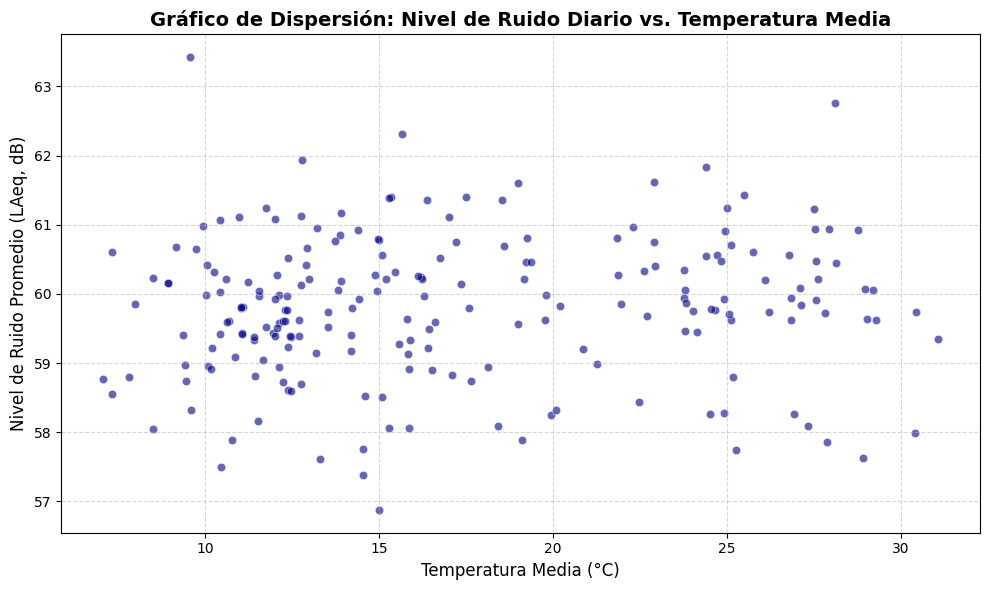

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='TM', y='Nivell_LAeq_1min', alpha=0.6, color='darkblue')
plt.title('Gráfico de Dispersión: Nivel de Ruido Diario vs. Temperatura Media', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura Media (°C)', fontsize=12)
plt.ylabel('Nivel de Ruido Promedio (LAeq, dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación del Gráfico de Dispersión

Este gráfico de dispersión nos permite observar visualmente la relación entre las dos variables. Si bien la correlación numérica fue muy baja, el gráfico puede revelar si existe alguna tendencia no lineal o agrupaciones de datos que no son capturadas por la correlación de Pearson.

Observa si los puntos forman una línea ascendente (correlación positiva), una línea descendente (correlación negativa) o si están dispersos sin un patrón claro (correlación débil o nula).

### Interpretación de la Correlación

*   **Valor cercano a 1:** Indica una correlación positiva fuerte. A medida que una variable aumenta, la otra tiende a aumentar.
*   **Valor cercano a -1:** Indica una correlación negativa fuerte. A medida que una variable aumenta, la otra tiende a disminuir.
*   **Valor cercano a 0:** Indica una correlación débil o nula. No hay una relación lineal clara entre las variables.

El valor calculado te ayudará a entender la dirección y fuerza de la relación lineal entre el nivel de ruido diario promedio y la temperatura media diaria.

### Próximos Pasos con los Datos Integrados

Ahora que tenemos un dataframe `merged_df` que combina los niveles de ruido diarios con las variables climáticas, podemos realizar análisis más profundos:

*   **Análisis de Correlación:** Explorar la correlación entre `Nivell_LAeq_1min` y las variables climáticas (`TM`, `HRM`, `PPT`, etc.).
*   **Visualizaciones:** Crear gráficos de dispersión o series temporales para visualizar estas relaciones.
*   **Modelado:** Utilizar estas variables climáticas como características para construir modelos que predigan los niveles de ruido.

¿Te gustaría que empecemos con un análisis de correlación o una visualización de la relación entre la temperatura media y el ruido?